<a href="https://colab.research.google.com/github/linneverh/Sust-Finance/blob/Assignment-2/Homework_2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment: Portfolio Allocation based on Financial Performance**

In [381]:
!pip install plotly
!pip install country_converter
# Import packages & libraries
#from pypfopt.efficient_frontier import EfficientFrontier
#from pypfopt import risk_models
#from pypfopt import expected_returns
from datetime import datetime, timedelta
from scipy.optimize import minimize
#from pypfopt.objective_functions import portfolio_return
from tqdm import tqdm
from collections import defaultdict  # Import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import calendar
import yfinance as yf
import scipy.optimize as sco
import scipy.interpolate as sci
import cvxpy as cp
import plotly.express as px
import country_converter as cc

In [382]:
#import dataset from git
url_DS_ESGScore_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_ESGScore_Y.csv'
DS_ESGScore_Y = pd.read_csv(url_DS_ESGScore_Y)

url_DS_EScore_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_EScore_Y.csv'
DS_EScore_Y = pd.read_csv(url_DS_EScore_Y)

url_DS_MV_USD_M = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_MV_USD_M.csv'
DS_MV_USD_M = pd.read_csv(url_DS_MV_USD_M)

url_DS_MV_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_MV_USD_Y.csv'
DS_MV_USD_Y = pd.read_csv(url_DS_MV_USD_Y)

url_DS_REV_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_REV_USD_Y.csv'
DS_REV_USD_Y = pd.read_csv(url_DS_REV_USD_Y)

url_DS_RI_USD_M = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_RI_USD_M.csv'
DS_RI_USD_M = pd.read_csv(url_DS_RI_USD_M)

url_DS_RI_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_RI_USD_Y.csv'
DS_RI_USD_Y = pd.read_csv(url_DS_RI_USD_M)

url_Risk_Free_Rate = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/Risk_Free_Rate.csv'
Risk_Free_Rate = pd.read_csv(url_Risk_Free_Rate)

url_Static = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/Static.csv'
Static = pd.read_csv(url_Static)


<ipython-input-382-ab90805fdee2>:9: DtypeWarning:

Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.



# **Cleaning**

### Return index and percentage data frame

#### MERGING RETURNS TABLE AND ESCORE TABLE FOR EM COUNTRIES

In [383]:
# Merging the data to filter per region
merged_DS_RI_USD_M = pd.merge(DS_RI_USD_M, Static, on='ISIN', how='inner')
merged_DS_RI_USD_M = merged_DS_RI_USD_M[['ISIN', 'Name', 'Country', 'Region'] + [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region']]]
del(merged_DS_RI_USD_M['NAME'])

#Keeping only the columns between 30/01/04 and 31/12/24
start_date = pd.to_datetime('2008-12-31')
end_date = pd.to_datetime('2024-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_RI_USD_M = merged_DS_RI_USD_M[selected_columns]
#merged_DS_RI_USD_M.head()


# Filter on EM countries
EM_merged_DS_RI_USD_M = merged_DS_RI_USD_M[merged_DS_RI_USD_M['Region'] == 'EM']
EM_merged_DS_RI_USD_M

<ipython-input-383-feee87fa7c77>:11: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
1,ARALUA010258,ALUAR,AR,EM,1742.20,1638.06,1242.49,1130.96,1270.87,1450.59,...,5760.96,5331.65,6253.43,5993.00,5680.53,5323.94,4928.66,4706.05,5207.18,4802.89
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,73.66,63.74,51.65,60.00,68.34,96.48,...,412.77,458.42,672.82,624.64,569.69,669.66,637.87,774.26,885.63,1067.88
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,198.77,172.44,129.34,121.38,113.08,117.02,...,1182.67,1092.52,1295.37,1215.48,1155.27,999.71,974.26,916.65,1076.94,982.55
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,32.48,32.78,32.71,35.23,32.91,38.78,...,0.63,0.59,0.59,0.56,0.51,0.59,0.62,0.80,0.67,0.63
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


#### Creation of R at wrong position

In [384]:
# Merging the EScore to EM, from 2003 to 2023

merged_DS_EScore_Y = pd.merge(DS_EScore_Y, Static, on='ISIN', how='inner')
merged_DS_EScore_Y = merged_DS_EScore_Y[['ISIN', 'Name', 'Region'] + [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Region', 'NAME']]]

#Keeping only the columns between 31/12/03 and 31/12/23
start_date = pd.to_datetime('2008-12-31')
end_date = pd.to_datetime('2023-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_EScore_Y = merged_DS_EScore_Y[selected_columns]


# Filter on EM countries
EM_merged_DS_EScore_Y = merged_DS_EScore_Y[merged_DS_EScore_Y['Region'] == 'EM']
EM_merged_DS_EScore_Y

<ipython-input-384-d041599f5589>:11: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



,ISIN,Name,Country,Region,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,ARALUA010258,ALUAR,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.82,13.26,12.26,11.05,13.19,12.21,17.65
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.51,56.64,76.16,84.68,82.48,88.36,86.99,79.68
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.51,33.47,33.72,33.41,33.52,38.37,36.83,48.05
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,0.0,0.00,0.00,0.00,0.00,0.00,0.00,17.85,36.12,45.19,48.35,52.97,63.43,53.70,47.78
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.2,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


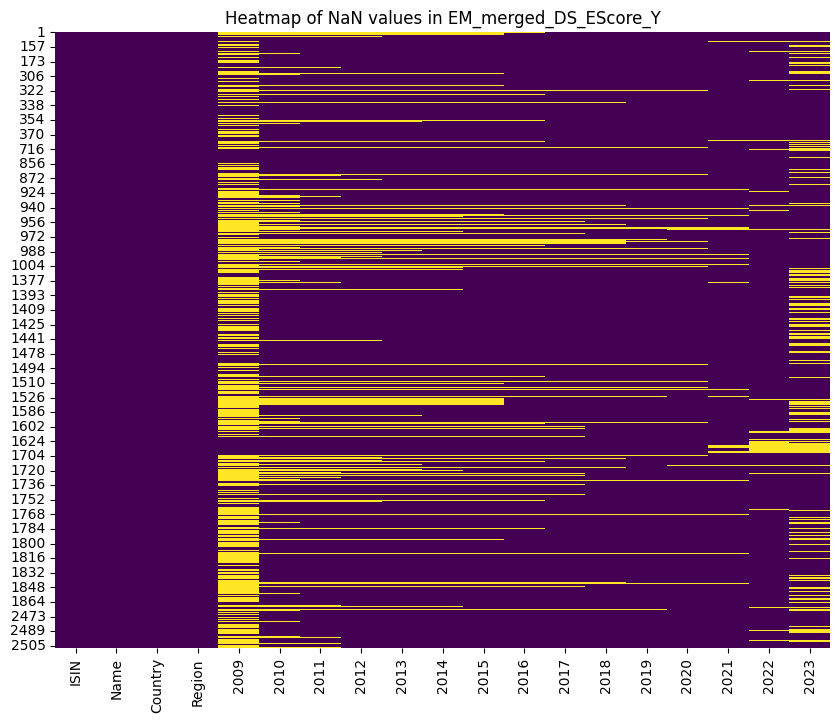

In [385]:
plt.figure(figsize=(10, 8))
sns.heatmap(EM_merged_DS_EScore_Y.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of NaN values in EM_merged_DS_EScore_Y')
plt.show()

In [386]:
# Filling in missing ESG
df_filled = EM_merged_DS_EScore_Y.copy()

# Identify the year columns (assuming they are strings representing years)
year_columns = sorted([col for col in df_filled.columns if col.isdigit()])

# Iterate through the year columns
for i in range(1, len(year_columns)):
    prev_year = year_columns[i-1]
    current_year = year_columns[i]

    # Create a mask to select rows where:
    # 1. The current year is NaN
    # 2. The previous year is NOT NaN
    # 3. The previous year's value is a float
    mask = (df_filled[current_year].isna()) & \
           (df_filled[prev_year].notna()) & \
           (df_filled[prev_year].apply(lambda x: isinstance(x, (int, float)))) #check if int or float (not only float)

    # Fill the NaN values in the current year with the previous year's float value
    df_filled.loc[mask, current_year] = df_filled.loc[mask, prev_year]

# Update DS_ESGScore_Y_filtered with the filled values
EM_merged_DS_EScore_Y = df_filled

In [387]:
#FILTERING ONLY FIRMS WITH AN E SCORE FROM 2013 ON

# Remplacer les chaînes de caractères "NaN" par np.nan
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y.replace('NaN', np.nan)
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y.replace(0, np.nan)

# Convert date columns to datetime if they are not already
date_columns = EM_merged_DS_EScore_Y.columns[4:]  # Assuming 'ISIN', 'Name', 'Country', 'Region' are the first 4 columns
EM_merged_DS_EScore_Y.columns = EM_merged_DS_EScore_Y.columns[:4].tolist() + pd.to_datetime(date_columns, errors='coerce').tolist()

# Select columns from 2013 onwards
start_date = pd.to_datetime('2013-12-31')
date_columns_2013_onwards = [col for col in EM_merged_DS_EScore_Y.columns
                             if isinstance(col, pd.Timestamp) and col >= start_date]

# Filter for rows with no NaN values in the selected columns
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y[
    EM_merged_DS_EScore_Y[date_columns_2013_onwards].notna().all(axis=1)
]
EM_merged_DS_EScore_Y

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


#### Restricting RI to countries with E-Score

In [388]:
isin_list = EM_merged_DS_EScore_Y['ISIN'].tolist()

# Filter EM_merged_DS_R_USD_M to keep only rows with ISINs present in the list
filtered_EM_merged_DS_RI_USD_M = EM_merged_DS_RI_USD_M[EM_merged_DS_RI_USD_M['ISIN'].isin(isin_list)].copy()
filtered_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


In [389]:
rows_with_nans = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y.isnull().any(axis=1)]
nan_counts_per_row = rows_with_nans.isnull().sum(axis=1)
df_nan_rows = pd.DataFrame({'Row': rows_with_nans.index, 'Nan_Count': nan_counts_per_row})

df_nan_rows

,Row,Nan_Count
145,145,4
151,151,1
154,154,1
155,155,1
157,157,1
...,...,...
2502,2502,1
2503,2503,3
2505,2505,1
2506,2506,1


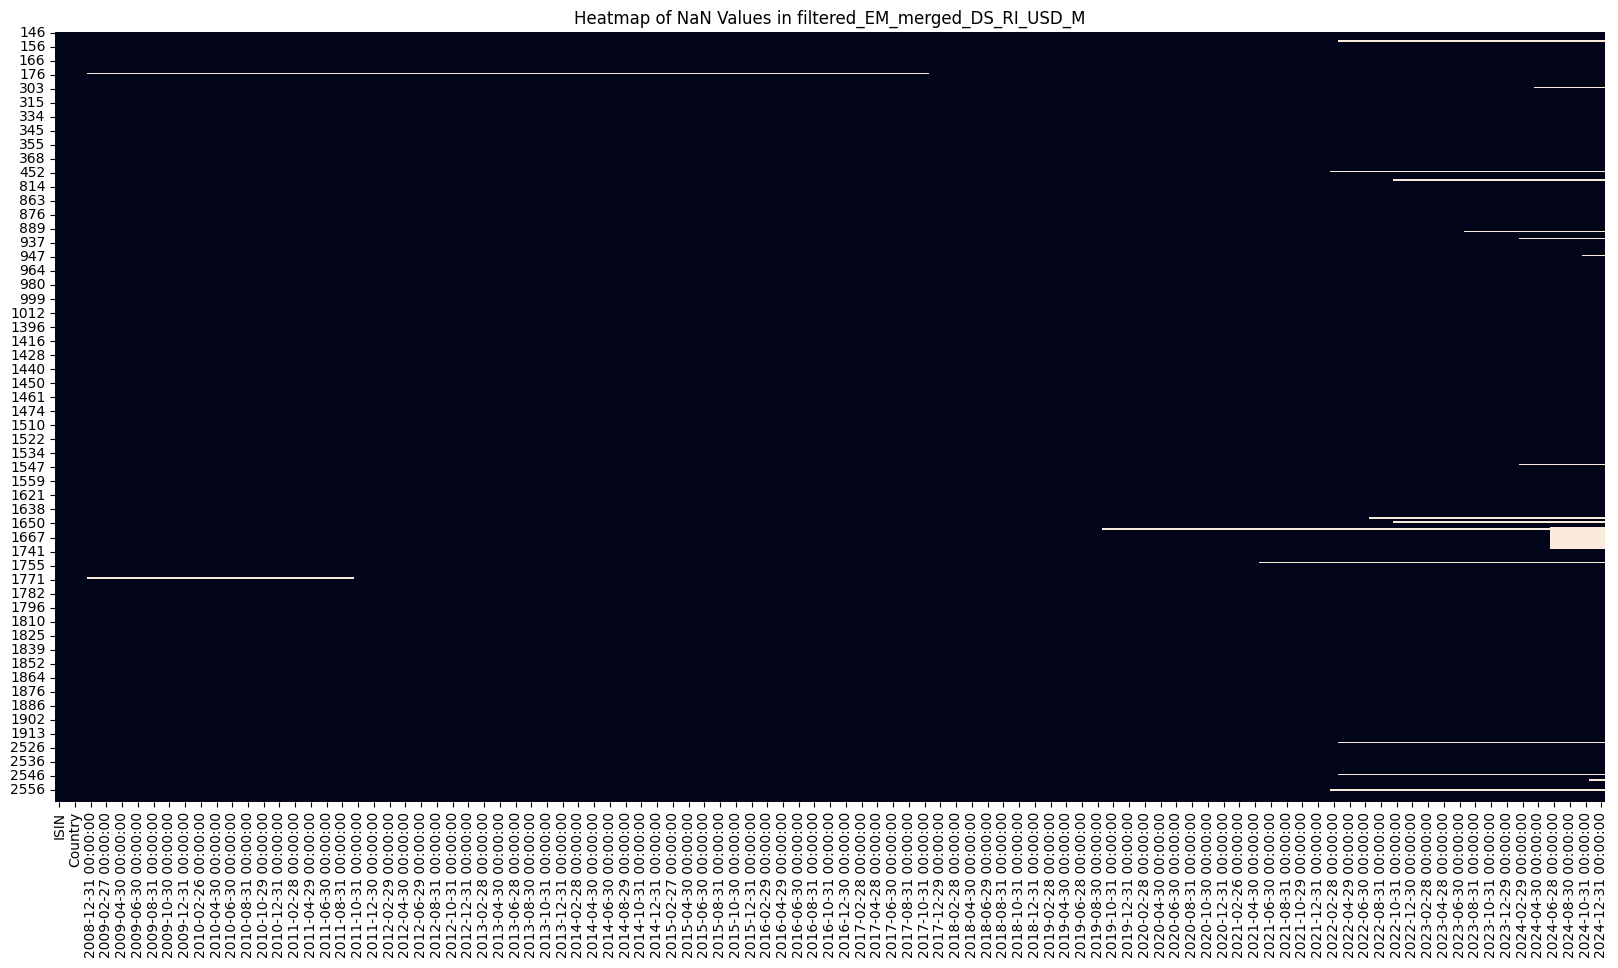

In [390]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_EM_merged_DS_RI_USD_M')
plt.show()

#### HATZOLD RULE: NAN VALUES BETWEEN 2014 AND 2024

In [391]:
# Make a copy to preserve the original
df_filled = filtered_EM_merged_DS_RI_USD_M.copy()

# Define time series columns (numerical columns across time)
time_cols = [col for col in df_filled.columns if col not in ['ISIN', 'Name', 'Country', 'Region']]

# Function to interpolate isolated NaNs across columns (i.e., along each row)
def interpolate_isolated_row(row):
    values = row.values.copy()
    for i in range(1, len(values) - 1):
        if pd.isna(values[i]) and not pd.isna(values[i - 1]) and not pd.isna(values[i + 1]):
            values[i] = (values[i - 1] + values[i + 1]) / 2
    return pd.Series(values, index=row.index)

# Apply row-wise interpolation only on the time columns
df_filled[time_cols] = df_filled[time_cols].apply(interpolate_isolated_row, axis=1)

# Optionally update the original DataFrame
filtered_EM_merged_DS_RI_USD_M = df_filled

In [392]:
filtered_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


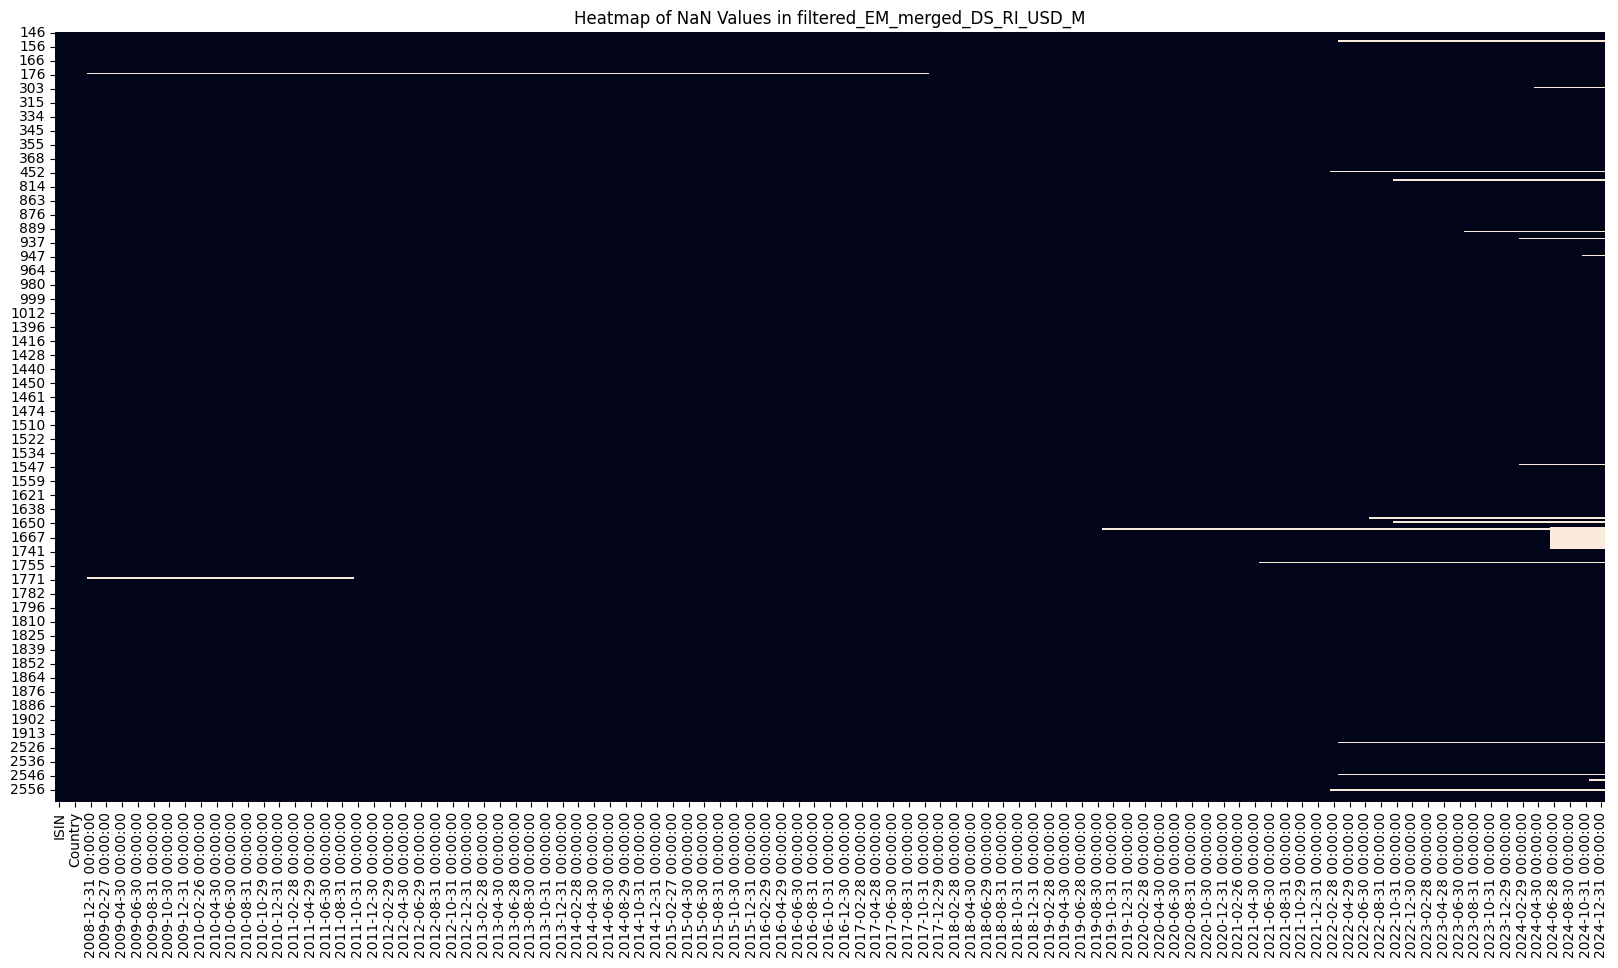

In [393]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_EM_merged_DS_RI_USD_M')
plt.show()

In the following part, we will first try to identify which firms to get rid of because of missing values ( time frame: 2004-2024: correct? )

In [394]:
# Filter for rows where 'Name' contains "SUSP" or "DELIST" and select 'Name' and 'ISIN'
filtered_name_isin = filtered_EM_merged_DS_RI_USD_M[
    filtered_EM_merged_DS_RI_USD_M['Name'].str.contains("SUSP|DELIST", case=False, na=False)
][['Name', 'ISIN']]

filtered_name_isin

,Name,ISIN
152,CMPH.ENGT.DE SAOP.B PN DEAD - DELIST.29/03/22,BRCESPACNPB4
302,AES ANDES DEAD - DELIST.18/04/24,CL0002694637
378,TELF.O2 CZECH REPUBLIC DEAD - DELIST.25/02/22,CZ0009093209
722,LAMPRELL DEAD - DELIST.25/10/22,GB00B1CL5249
934,RELIANCE CAPITAL SUSP - SUSP.29/02/24,INE013A01015
946,IDFC DEAD - DELIST.11/10/24,INE043D01016
1544,UMW HOLDINGS DEAD - DELIST.19/02/24,MYL4588OO009
1646,GRUPA LOTOS DEAD - DELIST.12/08/22,PLLOTOS00025
1649,POLISH OIL AND GAS DEAD - DELIST.18/11/22,PLPGNIG00014
1753,THAI AIRWAYS INTL. SUSP - SUSP.25/03/24,TH0245010002


In [395]:
isins_to_remove = filtered_name_isin['ISIN'].tolist()

filtered_dead_EM_merged_DS_RI_USD_M = filtered_EM_merged_DS_RI_USD_M[~filtered_EM_merged_DS_RI_USD_M['ISIN'].isin(isins_to_remove)]

filtered_dead_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


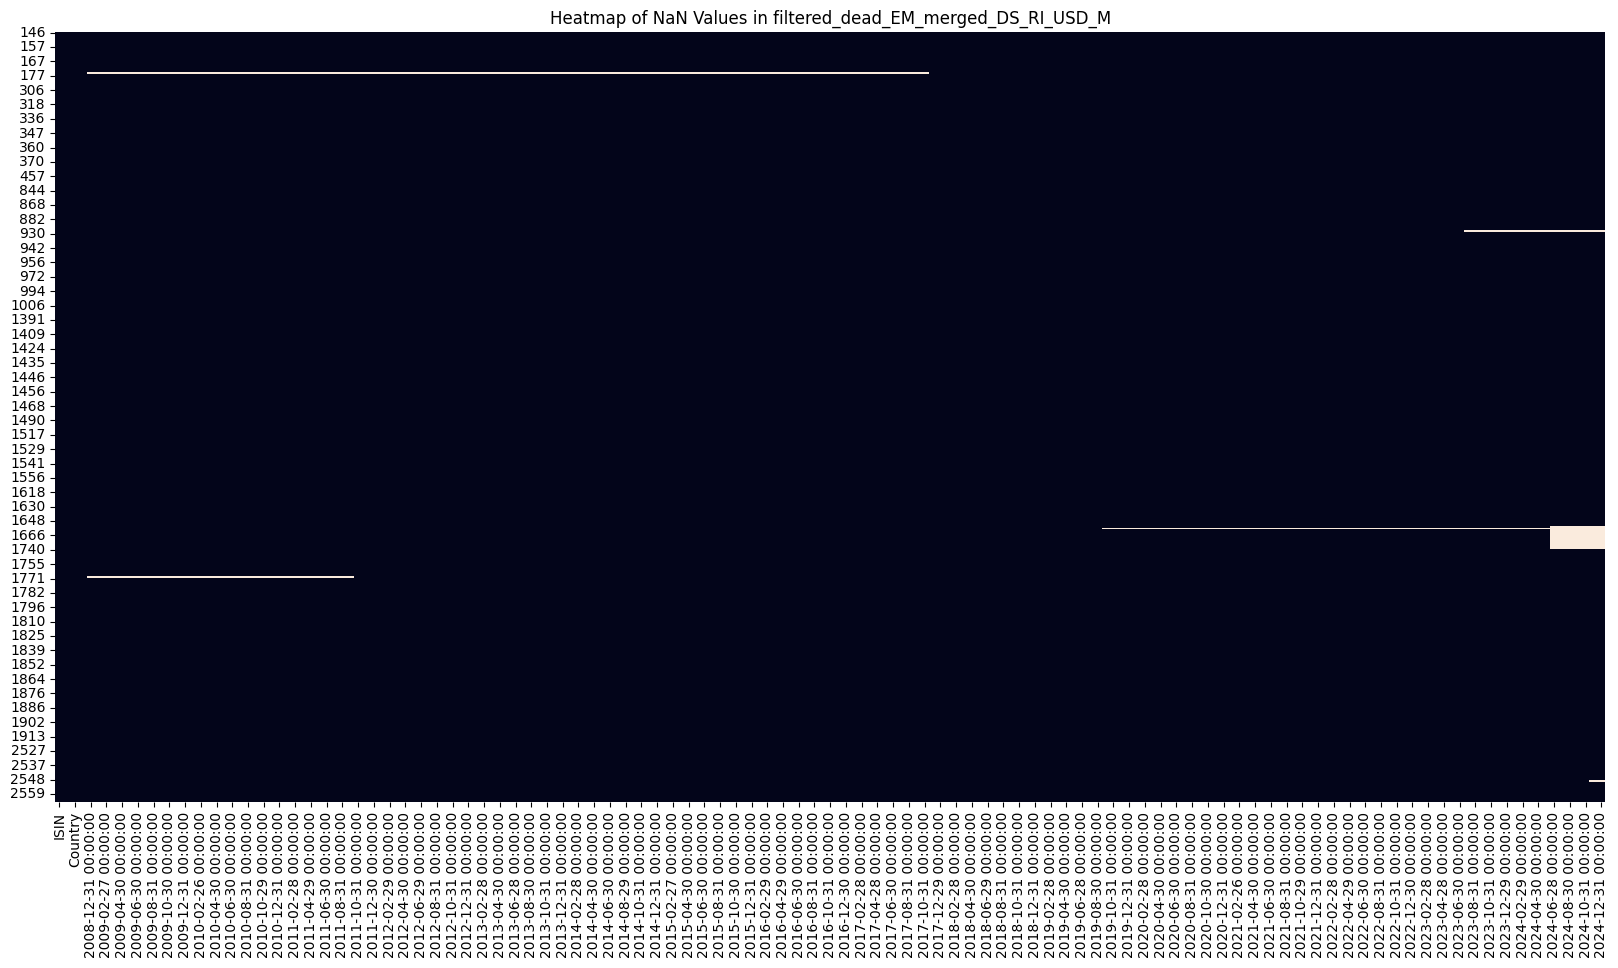

In [396]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_dead_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_dead_EM_merged_DS_RI_USD_M')
plt.show()

In [397]:
df_nan_rows = filtered_dead_EM_merged_DS_RI_USD_M[filtered_dead_EM_merged_DS_RI_USD_M.isnull().any(axis=1)][['Name', 'ISIN']]
df_nan_rows

,Name,ISIN
175,SUZANO ON,BRSUZBACNOR0
928,HOUSING DEVELOPMENT FINANCE CORPORATION,INE001A01036
1660,MMC NORILSK NICKEL,RU0007288411
1661,URALKALI,RU0007661302
1662,GAZPROM,RU0007661625
1663,ROSTELECOM,RU0008943394
1664,NK LUKOIL,RU0009024277
1665,SBERBANK OF RUSSIA,RU0009029540
1666,TATNEFT,RU0009033591
1667,SEVERSTAL,RU0009046510


In [398]:
isins_to_remove = df_nan_rows['ISIN'].tolist()

# Remove rows where ISIN is in isins_to_remove
filtered_dead_nan_EM_merged_DS_RI_USD_M = filtered_dead_EM_merged_DS_RI_USD_M[
    ~filtered_dead_EM_merged_DS_RI_USD_M['ISIN'].isin(isins_to_remove)
]

In [399]:
nan_counts = filtered_dead_nan_EM_merged_DS_RI_USD_M.isnull().sum().sum()
print("Total number of NaN values:", nan_counts)

Total number of NaN values: 0


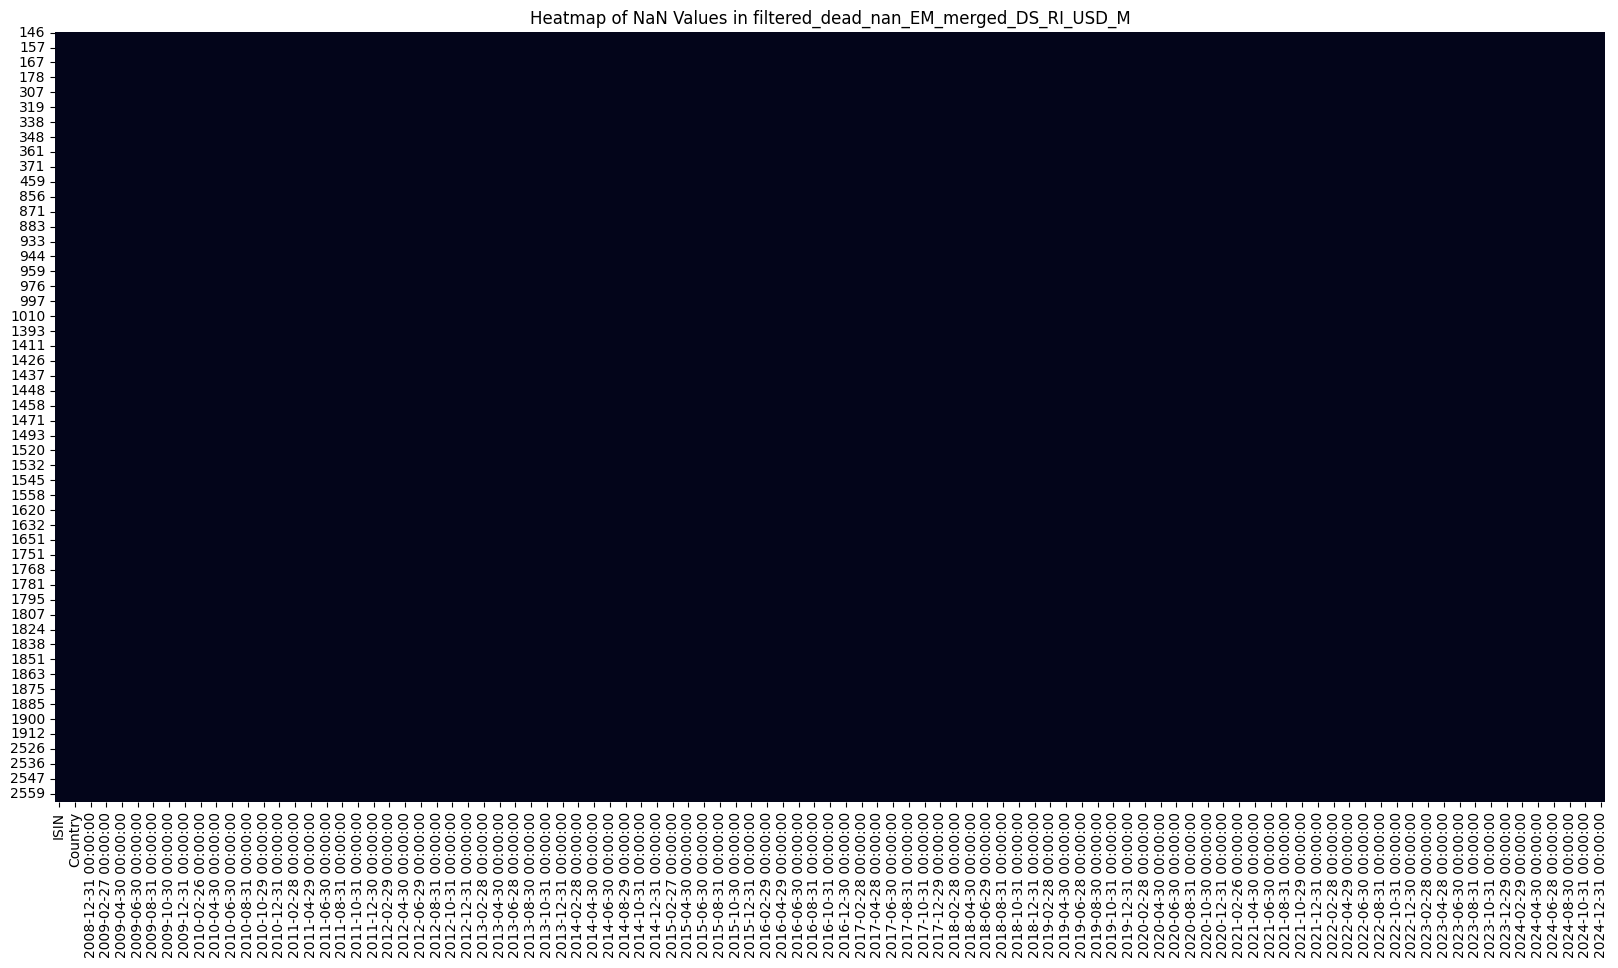

In [400]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_dead_nan_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_dead_nan_EM_merged_DS_RI_USD_M')
plt.show()

## Data frames

### Return index dataframe

In [401]:
returns = filtered_dead_nan_EM_merged_DS_RI_USD_M

### Simple returns data frame

In [402]:
# 1. Define metadata columns
metadata_cols = ['ISIN', 'Name', 'Country', 'Region']

# 2. Separate date and metadata columns
date_cols = [col for col in returns.columns if col not in metadata_cols]

# 3. Convert date columns to numeric (coerce errors)
data = returns[date_cols].apply(pd.to_numeric, errors='coerce')

# 4. Compute simple returns using built-in pct_change
returns_pct = data.pct_change(axis=1)

# 5. Replace infinite values and fill NaNs with 0
returns_pct.replace([np.inf, -np.inf], 0, inplace=True)
returns_pct.fillna(0, inplace=True)

# 6. Combine with metadata
simple_returns = pd.concat([
    returns[metadata_cols].reset_index(drop=True),
    returns_pct.reset_index(drop=True)
], axis=1)

simple_returns

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
0,BRABEVACNOR1,AMBEV ON,BR,EM,0.0,-0.042665,0.020508,0.139945,0.137388,0.202735,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,0.0,-0.029038,-0.024663,0.270417,0.161538,0.267537,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,0.0,-0.072389,-0.023411,0.155468,0.248645,0.234734,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,0.0,0.080043,-0.094964,0.001767,0.190736,0.338332,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,BRBRKMACNPA4,BRASKEM PN A,BR,EM,0.0,0.032655,-0.078423,-0.077588,0.361663,0.277753,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,ZAE000191342,ALTRON LIMITED A,ZA,EM,0.0,-0.038896,-0.182688,0.103545,0.233599,0.102493,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,ZAE000255915,ABSA GROUP,ZA,EM,0.0,-0.220778,-0.027959,0.186990,0.148198,0.087830,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,0.0,-0.230407,0.267228,0.264653,0.235547,0.274169,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,ZAE000302618,AVENG,ZA,EM,0.0,-0.221320,-0.009313,0.068622,0.408339,0.125422,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


### E-Score data frame

In [403]:
isin_list_R = simple_returns['ISIN'].tolist()

# Filter EM_merged_DS_EScore_Y to keep only rows with ISINs present in the list
EScore = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y['ISIN'].isin(isin_list_R)].copy()

EScore

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


### Market cap data frame

In [404]:
filtered_EM_DS_MV_USD_M = DS_MV_USD_M[DS_MV_USD_M['ISIN'].isin(isin_list_R)].copy()
market_cap_M = filtered_EM_DS_MV_USD_M

In [405]:
filtered_EM_DS_MV_USD_Y = DS_MV_USD_Y[DS_MV_USD_Y['ISIN'].isin(isin_list_R)].copy()
market_cap_Y = filtered_EM_DS_MV_USD_Y

### Risk free rate data frame

In [406]:
df = Risk_Free_Rate.copy()

df[df.columns[0]] = df[df.columns[0]].astype(str)

# Extract year (first 4 characters) and month (characters 5-6)
df['Year'] = df.iloc[:, 0].str[:4].astype(int)
df['Month'] = df.iloc[:, 0].str[4:6].astype(int)  # Extract month

# Get the last day of the month using calendar.monthrange
df['LastDay'] = df.apply(lambda row: calendar.monthrange(row['Year'], row['Month'])[1], axis=1)
# Rename 'LastDay' to 'Day' for pd.to_datetime
df = df.rename(columns={'LastDay': 'Day'}) # Rename to 'Day' to match expected input for pd.to_datetime

# Now create the 'ReadableDate' column using the calculated LastDay
df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']]) # Use 'Day' instead of 'LastDay'

# Drop the temporary 'Year', 'Month', and 'Day' columns
df = df.drop(['Year', 'Month', 'Day', 'Unnamed: 0' ], axis=1)

df = df[['date', 'RF']]

df['date'] = pd.to_datetime(df['date'])
df['RF'] = df['RF'] / 100

#df["RF"] = (1 + df["RF"]) ** (1/12) - 1
#df['RF'] = df['RF'] / 12

risk_free_rate = df

### Simple returns no zeros

In [407]:
threshold = 0.8 # Max 0 per row

def remove_rows_with_many_zeros(df, threshold):
  """Removes rows where the count of zero values exceeds the threshold."""
  rows_to_drop = []
  for index, row in df.iterrows():
    total_values = len(row)
    zero_count = (row == 0).sum()
    if total_values > 0 and (zero_count / total_values) > threshold:
      rows_to_drop.append(index)

  df_cleaned = df.drop(rows_to_drop)
  return df_cleaned

# Example usage:
simple_returns_cleaned = remove_rows_with_many_zeros(simple_returns, threshold)

# Print the cleaned DataFrame
simple_returns_no_zeros = simple_returns_cleaned

isin_list_simple_returns_cleaned = simple_returns_no_zeros['ISIN'].tolist()

In [408]:
simple_returns_no_zeros

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
0,BRABEVACNOR1,AMBEV ON,BR,EM,0.0,-0.042665,0.020508,0.139945,0.137388,0.202735,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,0.0,-0.029038,-0.024663,0.270417,0.161538,0.267537,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,0.0,-0.072389,-0.023411,0.155468,0.248645,0.234734,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,0.0,0.080043,-0.094964,0.001767,0.190736,0.338332,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,BRBRKMACNPA4,BRASKEM PN A,BR,EM,0.0,0.032655,-0.078423,-0.077588,0.361663,0.277753,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,ZAE000191342,ALTRON LIMITED A,ZA,EM,0.0,-0.038896,-0.182688,0.103545,0.233599,0.102493,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,ZAE000255915,ABSA GROUP,ZA,EM,0.0,-0.220778,-0.027959,0.186990,0.148198,0.087830,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,0.0,-0.230407,0.267228,0.264653,0.235547,0.274169,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,ZAE000302618,AVENG,ZA,EM,0.0,-0.221320,-0.009313,0.068622,0.408339,0.125422,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


In [409]:
#COUNTRY CONVERTER

# 1. Convert country codes to full names
# Assuming 'simple_returns_no_zeros' is your DataFrame
countries_codes = simple_returns_no_zeros['Country'].unique()
countries_names = cc.convert(names=countries_codes, to='name_short')

# 2. Create a DataFrame for Plotly with country names
df = pd.DataFrame({'Country': countries_names})

# 3. Create the choropleth map (rest of the code is the same)
fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color_discrete_sequence=['red'],
    scope='world',
    title='Countries in the Dataset (highlighted in red)'
)

# 4. Update layout
fig.update_geos(
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="LightGray",
    showocean=True, oceancolor="LightBlue",
    visible=False  # Hide the colorbar
)

fig.show()

In [410]:
# 1. Convert country codes to full names and get observations per country
countries_codes = simple_returns_no_zeros['Country'].unique()
countries_names = cc.convert(names=countries_codes, to='name_short')

# Calculate observations per country
observations_per_country = simple_returns_no_zeros['Country'].value_counts().to_dict()

# 2. Create a DataFrame for Plotly with country names and observations
df = pd.DataFrame({
    'Country': countries_names,
    'Observations': [observations_per_country.get(cc.convert(name, to='ISO2'), 0) for name in countries_names]
})

# 3. Create the choropleth map
fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color='Observations',  # Color by observations
    color_continuous_scale='Reds',  # Use a red color scale
    scope='world',
    title='Countries in the Dataset (colored by observations)',
    hover_data=['Observations']  # Show observations on hover
)

# 4. Update layout
fig.update_geos(
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="LightGray",
    showocean=True, oceancolor="LightBlue"
)

fig.show()

In [411]:
nan_count = simple_returns_no_zeros.isnull().sum().sum()
print(f"Total number of NaN values in simple_returns_no_zeros: {nan_count}")

Total number of NaN values in simple_returns_no_zeros: 0


<ipython-input-412-40a93cce14bd>:2: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



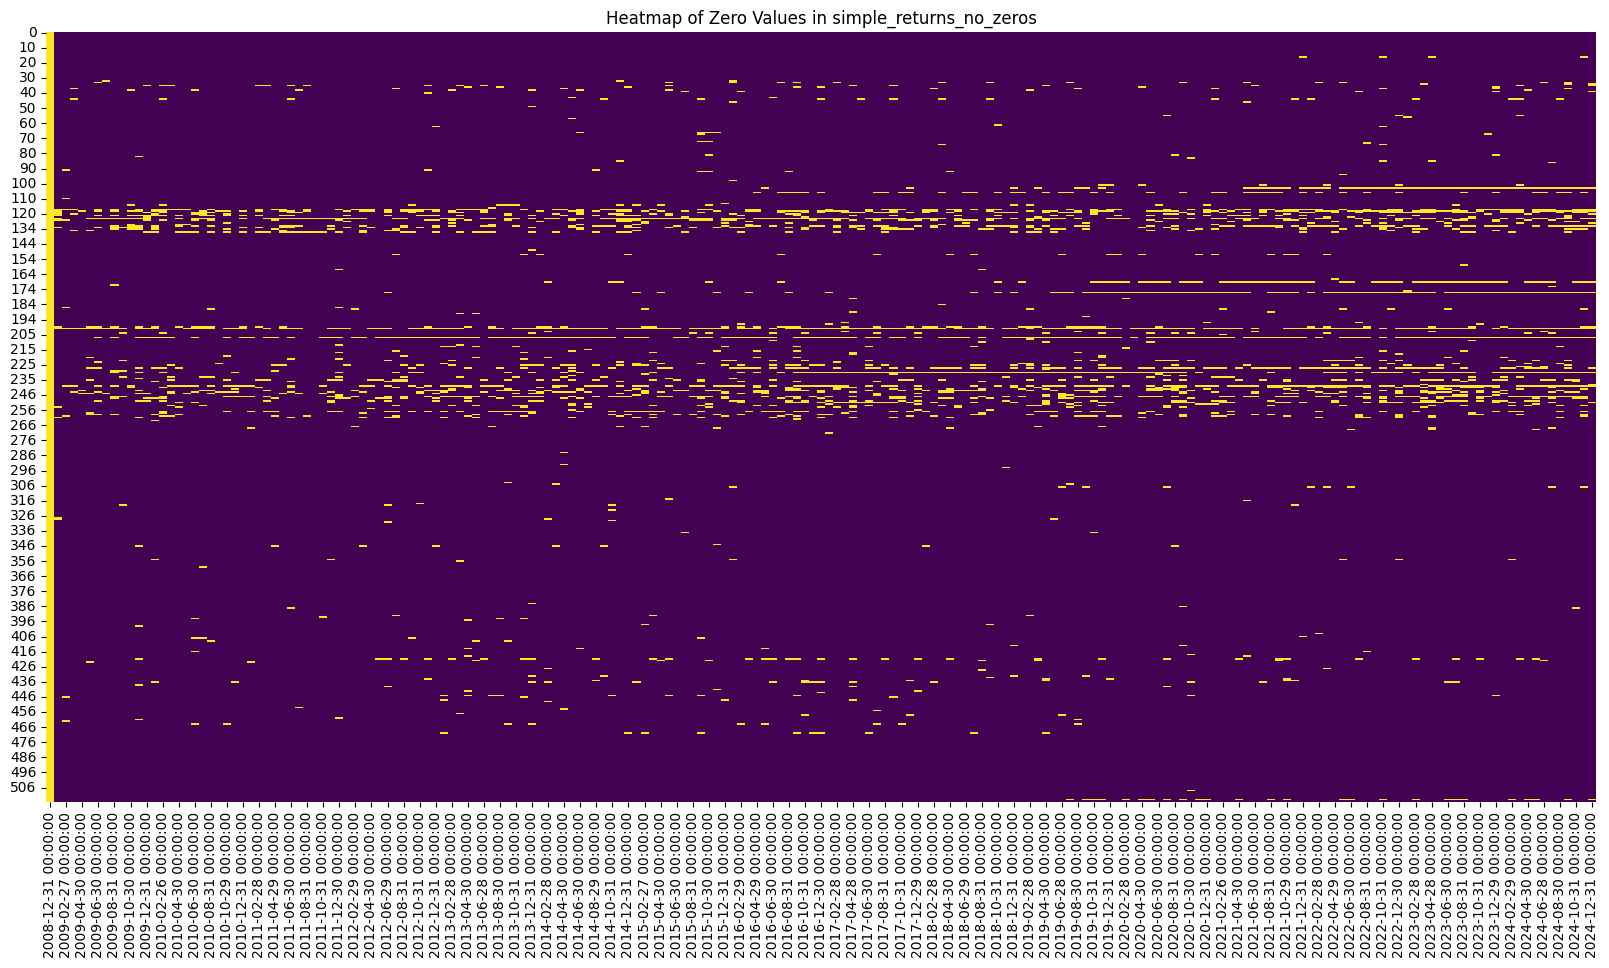

In [412]:
plt.figure(figsize=(20, 10))
sns.heatmap(simple_returns_no_zeros.iloc[:, 4:].applymap(lambda x: 1 if x == 0 else 0), cmap='viridis', cbar=False)
plt.title('Heatmap of Zero Values in simple_returns_no_zeros')
plt.show()

### E-Score no zeros

In [413]:
EScore_no_zeros = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
EScore_no_zeros

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


### Market Cap no zeros

In [414]:
market_cap_M_no_zeros = DS_MV_USD_M[DS_MV_USD_M['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
market_cap_M_no_zeros

,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,...,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00
146,AMBEV ON,BRABEVACNOR1,898.33,848.69,810.12,1064.46,1062.92,1017.51,1287.05,1591.09,...,36938.22,34658.22,32369.65,32280.60,35781.82,37847.65,34407.58,33596.80,29944.81,29942.67
147,BANCO DO BRASIL ON,BRBBASACNOR3,1869.6,1744.22,1680.67,1438.89,1327.29,1246.41,1427.23,1404.38,...,30317.50,29570.88,27558.30,26916.82,28455.29,28602.67,26066.58,23775.07,22421.07,27155.61
148,BANCO BRADESCO PN,BRBBDCACNPR8,4233.93,4330.41,3849.25,4416.12,3920.07,3616.62,4663.78,4660.55,...,14347.73,12805.03,11839.36,11680.45,14669.45,14338.50,13186.18,11236.44,9939.55,10993.84
149,BRF BRASIL FOODS ON,BRBRFSACNOR8,168.22,126.22,126.78,128.56,124.32,126.71,127.79,113.22,...,5479.35,5947.72,6866.89,6268.28,7792.49,7306.66,7623.63,6991.22,6906.52,6304.78
150,BRASKEM PN A,BRBRKMACNPA4,378.1,382.60,389.65,390.56,382.71,373.34,422.45,509.39,...,1416.69,1240.83,1109.52,1071.31,1099.16,1262.82,1046.73,866.89,646.79,815.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ALTRON LIMITED A,ZAE000191342,105.41,115.91,106.13,113.98,90.17,76.58,74.37,85.52,...,248.89,280.70,295.36,388.98,393.90,413.00,427.45,460.04,463.34,472.18
2561,ABSA GROUP,ZAE000255915,2882.25,2649.35,2483.04,2348.10,2295.91,2374.43,2458.35,2347.50,...,6906.91,7086.12,7760.90,7856.60,8858.64,9105.44,8530.48,8540.85,8993.55,8893.95
2562,NORTHAM PLATINUM HLDGS,ZAE000298253,230.57,259.71,207.52,249.66,193.50,206.19,264.77,300.82,...,2632.31,2730.05,2762.38,3107.39,2352.88,2507.23,2918.45,2467.31,2045.45,2687.92
2563,AVENG,ZAE000302618,436.66,445.83,454.09,389.04,351.95,276.11,312.53,299.24,...,42.32,39.84,48.32,61.15,71.10,70.09,66.52,78.76,84.89,83.96


In [415]:
market_cap_Y_no_zeros = DS_MV_USD_Y[DS_MV_USD_Y['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
market_cap_Y_no_zeros

,NAME,ISIN,1999,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
146,AMBEV ON,BRABEVACNOR1,NaN,819.89,3937.94,2602.40,1896.76,3559.93,11591.19,12592.77,...,99515.76,69538.70,90471.62,107508.68,77276.64,56712.12,39584.64,46420.10,40387.05,41249.56
147,BANCO DO BRASIL ON,BRBBASACNOR3,1229.28,1699.83,1491.64,1777.86,1936.54,5436.48,9889.44,20860.01,...,22818.99,9491.81,30601.78,38066.35,39989.52,29529.50,14422.12,19569.90,22329.53,33330.86
148,BANCO BRADESCO PN,BRBBDCACNPR8,1985.4,4140.79,4189.36,4149.60,2015.24,3825.63,7645.06,20084.50,...,27716.97,13100.56,29942.02,38172.77,40138.61,27651.57,18303.76,19138.44,13621.42,14719.11
149,BRF BRASIL FOODS ON,BRBRFSACNOR8,48.47,126.53,114.56,96.60,69.13,147.38,293.92,579.23,...,20231.08,10194.51,10648.29,7175.60,4725.59,5266.64,3154.82,3508.56,1346.17,4733.06
150,BRASKEM PN A,BRBRKMACNPA4,90.45,386.95,352.75,243.08,98.96,1220.00,3031.10,2055.91,...,1588.06,2159.27,3598.81,5028.61,5139.27,2269.71,1935.44,3194.64,1319.91,1446.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ALTRON LIMITED A,ZAE000191342,94.56,107.67,99.15,64.30,100.20,168.36,266.46,404.40,...,164.32,29.98,81.55,438.82,534.90,527.84,305.93,201.56,186.80,206.59
2561,ABSA GROUP,ZAE000255915,2769.41,2538.47,2643.38,1648.06,2716.00,4536.54,8868.79,12924.62,...,14339.19,7622.05,10219.45,14896.64,11171.05,8074.78,6791.52,9884.60,9004.67,7674.69
2562,NORTHAM PLATINUM HLDGS,ZAE000298253,129.22,211.66,457.28,312.74,451.25,376.75,351.63,1032.35,...,1727.00,1049.09,1987.98,1878.19,2067.38,4399.06,7468.55,5917.59,3332.08,2267.72
2563,AVENG,ZAE000302618,NaN,460.16,397.60,257.32,465.76,462.54,801.12,1509.59,...,562.52,77.34,231.85,61.56,41.90,25.62,78.03,164.93,106.15,47.52


## Data frames restricted time frame

### Simple returns no zeros

In [416]:
df = simple_returns_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:3]) + list(pd.to_datetime(df.columns[3:]))

start_date = pd.to_datetime('2009-01-30 00:00:00')
end_date = pd.to_datetime('2024-12-31 00:00:00')

# Select only the date range columns
simple_returns_M_2009_2024 = df.loc[:, start_date:end_date]
simple_returns_M_2009_2024_D=simple_returns_M_2009_2024.copy()

simple_returns_M_2009_2024

,2009-01-30,2009-02-27,2009-03-31,2009-04-30,2009-05-29,2009-06-30,2009-07-31,2009-08-31,2009-09-30,2009-10-30,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,-0.042665,0.020508,0.139945,0.137388,0.202735,-0.015351,0.071526,0.127902,0.112810,0.082226,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
BRBBASACNOR3,-0.029038,-0.024663,0.270417,0.161538,0.267537,0.015014,0.165587,0.118995,0.260807,-0.077842,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
BRBBDCACNPR8,-0.072389,-0.023411,0.155468,0.248645,0.234734,-0.036107,0.067797,0.046571,0.205743,0.002816,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
BRBRFSACNOR8,0.080043,-0.094964,0.001767,0.190736,0.338332,-0.038486,0.152918,0.018109,0.179561,-0.076438,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
BRBRKMACNPA4,0.032655,-0.078423,-0.077588,0.361663,0.277753,0.007898,0.208685,0.263173,0.129916,0.060759,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,-0.038896,-0.182688,0.103545,0.233599,0.102493,0.190152,0.065484,0.002709,0.024090,0.047046,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
ZAE000255915,-0.220778,-0.027959,0.186990,0.148198,0.087830,0.127362,0.052348,0.105134,-0.026847,0.004522,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
ZAE000298253,-0.230407,0.267228,0.264653,0.235547,0.274169,-0.087102,0.218085,0.087063,-0.144615,0.088641,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888


### Market cap no zeros

In [417]:
df = market_cap_Y_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:2]) + list(pd.to_datetime(df.columns[2:]))

start_date = pd.to_datetime('2009')
end_date = pd.to_datetime('2024')

# Select only the date range columns
market_cap_Y_2009_2024 = df.loc[:, start_date:end_date]

market_cap_Y_2009_2024

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00,2024-01-01 00:00:00
ISIN,,,,,,,,,,,,,,,,
BRABEVACNOR1,12459.26,28572.71,38352.47,58002.65,77661.18,112045.24,99515.76,69538.70,90471.62,107508.68,77276.64,56712.12,39584.64,46420.10,40387.05,41249.56
BRBBASACNOR3,15311.83,42291.45,50279.94,45935.40,36647.03,23818.34,22818.99,9491.81,30601.78,38066.35,39989.52,29529.50,14422.12,19569.90,22329.53,33330.86
BRBBDCACNPR8,13831.15,29506.49,36054.97,34042.85,33523.21,23987.44,27716.97,13100.56,29942.02,38172.77,40138.61,27651.57,18303.76,19138.44,13621.42,14719.11
BRBRFSACNOR8,2592.31,10634.70,15061.16,17852.74,18677.98,14895.12,20231.08,10194.51,10648.29,7175.60,4725.59,5266.64,3154.82,3508.56,1346.17,4733.06
BRBRKMACNPA4,734.86,2330.45,4210.54,3182.58,2547.68,2433.94,1588.06,2159.27,3598.81,5028.61,5139.27,2269.71,1935.44,3194.64,1319.91,1446.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,212.03,358.46,391.78,331.51,260.48,236.45,164.32,29.98,81.55,438.82,534.90,527.84,305.93,201.56,186.80,206.59
ZAE000255915,6498.75,12444.13,13278.42,15056.44,13286.88,10409.74,14339.19,7622.05,10219.45,14896.64,11171.05,8074.78,6791.52,9884.60,9004.67,7674.69
ZAE000298253,833.24,2094.32,2543.85,1687.29,1695.81,1502.48,1727.00,1049.09,1987.98,1878.19,2067.38,4399.06,7468.55,5917.59,3332.08,2267.72


### E-Score no zeros

In [418]:
df = EScore_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:4]) + list(pd.to_datetime(df.columns[4:]))

start_date = pd.to_datetime('2009')
end_date = pd.to_datetime('2023')

# Select only the date range columns
EScore_Y_2009_2024 = df.loc[:, start_date:end_date]
EScore_Y_2009_2024_D=EScore_Y_2009_2024.copy()
EScore_Y_2009_2024

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
ISIN,,,,,,,,,,,,,,,
BRABEVACNOR1,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
BRBBASACNOR3,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
BRBBDCACNPR8,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
BRBRFSACNOR8,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
BRBRKMACNPA4,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
ZAE000255915,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
ZAE000298253,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96


# **Question 2**

### Map

In [419]:
# 1. Convert country codes to full names
# Assuming 'simple_returns_no_zeros' is your DataFrame
countries_codes = simple_returns_no_zeros['Country'].unique()
countries_names = cc.convert(names=countries_codes, to='name_short')

# 2. Create a DataFrame for Plotly with country names
df = pd.DataFrame({'Country': countries_names})

# 3. Create the choropleth map (rest of the code is the same)
fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color_discrete_sequence=['red'],
    scope='world',
    title='Countries in the Dataset (highlighted in red)'
)

# 4. Update layout
fig.update_geos(
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="LightGray",
    showocean=True, oceancolor="LightBlue",
    visible=False  # Hide the colorbar
)

fig.show()

In [420]:
# 1. Convert country codes to full names
# Assuming 'simple_returns_no_zeros' is your DataFrame
countries_codes = simple_returns_no_zeros['Country'].unique()
countries_names = cc.convert(names=countries_codes, to='name_short')

# 2. Create a DataFrame for Plotly with country names
df = pd.DataFrame({'Country': countries_names})

# 3. Create the choropleth map (rest of the code is the same)
fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color_discrete_sequence=['red'],
    scope='world',
    title='Countries in the Dataset (highlighted in red)'
)

# 4. Update layout
fig.update_geos(
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="LightGray",
    showocean=True, oceancolor="LightBlue",
    visible=False  # Hide the colorbar
)

fig.show()

### Optimization

In [421]:
simple_returns_M_2014_2024 = simple_returns_M_2009_2024.loc[:, pd.to_datetime('2014-01-31'):]

In [422]:
simple_returns_M_2014_2024_T = simple_returns_M_2014_2024.T

In [423]:
simple_returns_M_2009_2013 = simple_returns_M_2009_2024.loc[:, :pd.to_datetime('2013-12-31')]
simple_returns_M_2009_2013

,2009-01-30,2009-02-27,2009-03-31,2009-04-30,2009-05-29,2009-06-30,2009-07-31,2009-08-31,2009-09-30,2009-10-30,...,2013-03-29,2013-04-30,2013-05-31,2013-06-28,2013-07-31,2013-08-30,2013-09-30,2013-10-31,2013-11-29,2013-12-31
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,-0.042665,0.020508,0.139945,0.137388,0.202735,-0.015351,0.071526,0.127902,0.112810,0.082226,...,-0.071255,-0.002323,-0.059527,-0.028378,0.007427,-0.065303,0.097211,-0.013309,0.002553,-0.024532
BRBBASACNOR3,-0.029038,-0.024663,0.270417,0.161538,0.267537,0.015014,0.165587,0.118995,0.260807,-0.077842,...,0.042196,-0.076808,-0.048842,-0.148282,-0.008913,0.010887,0.213421,0.152299,-0.173976,-0.049574
BRBBDCACNPR8,-0.072389,-0.023411,0.155468,0.248645,0.234734,-0.036107,0.067797,0.046571,0.205743,0.002816,...,0.045056,-0.025748,-0.019290,-0.188117,-0.066442,-0.036176,0.174037,0.066887,-0.082639,-0.069580
BRBRFSACNOR8,0.080043,-0.094964,0.001767,0.190736,0.338332,-0.038486,0.152918,0.018109,0.179561,-0.076438,...,0.018199,0.120400,-0.054438,-0.063042,-0.021226,0.090936,0.044678,-0.024725,-0.074108,-0.047004
BRBRKMACNPA4,0.032655,-0.078423,-0.077588,0.361663,0.277753,0.007898,0.208685,0.263173,0.129916,0.060759,...,-0.082013,0.285434,-0.099578,-0.048471,0.032665,-0.041125,0.080052,0.121391,-0.003014,-0.001511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,-0.038896,-0.182688,0.103545,0.233599,0.102493,0.190152,0.065484,0.002709,0.024090,0.047046,...,-0.065518,0.016004,-0.126313,0.045587,-0.058790,0.085144,0.177747,-0.015085,-0.043177,-0.031363
ZAE000255915,-0.220778,-0.027959,0.186990,0.148198,0.087830,0.127362,0.052348,0.105134,-0.026847,0.004522,...,-0.044929,-0.026783,-0.096573,0.007027,-0.035615,-0.072679,0.122490,0.057608,-0.092442,-0.056094
ZAE000298253,-0.230407,0.267228,0.264653,0.235547,0.274169,-0.087102,0.218085,0.087063,-0.144615,0.088641,...,-0.008944,-0.143523,-0.037390,-0.096398,0.132083,0.115637,0.034653,-0.022428,-0.043132,0.019182


In [424]:
returns_data = simple_returns_M_2014_2024_T
returns_data_ante = simple_returns_M_2009_2013.T
#num_assets = num_assets_per_month
cov_matrix = returns_data.cov()
cov_matrix_ante = returns_data_ante.cov()
num_assets = cov_matrix.shape[1]

In [425]:
def port_vol(weights) :
  return np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 12, weights)))

def port_ret(weights) :
  return np.sum(returns_data.mean() * weights)*12

def port_ret_neg(weights) :
  return -np.sum(returns_data.mean() * weights)*12

In [426]:
cons = ({'type' : 'eq', 'fun' : lambda x : np.sum(x) - 1})

# Bounds Setup (non-negative weights)
bounds = [(0, None)] * num_assets

init_weights = np.array(num_assets*[1/num_assets])

opt_l_gmv = sco.minimize(port_vol, init_weights, method = 'SLSQP', bounds = bounds, constraints = cons)
opt_l_gmv

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.07360948190760273
       x: [ 0.000e+00  0.000e+00 ...  1.038e-16  3.964e-16]
     nit: 16
     jac: [ 1.582e-01  2.332e-01 ...  1.682e-01  2.855e-01]
    nfev: 8178
    njev: 16

In [427]:
port_vol(opt_l_gmv['x'])

np.float64(0.07360948190760273)

In [428]:
port_ret(opt_l_gmv['x'])

np.float64(0.07976693595987727)

In [429]:
cons = ({'type' : 'eq', 'fun' : lambda x : np.sum(x) - 1})

# Bounds Setup (non-negative weights)
bounds = [(0, None)] * num_assets

init_weights = np.array(num_assets*[1/num_assets])

opt_l_gmr = sco.minimize(port_ret_neg, init_weights, method = 'SLSQP', bounds = bounds, constraints = cons)
opt_l_gmr

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.5633006519696411
       x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
     nit: 6
     jac: [ 3.643e-02 -1.744e-01 ...  3.090e-01  6.540e-02]
    nfev: 3066
    njev: 6

In [430]:
port_vol(opt_l_gmr['x'])

np.float64(0.6063101334185148)

In [431]:
port_ret(opt_l_gmr['x'])

np.float64(0.5633006519696411)

In [432]:
mv_v = port_vol(opt_l_gmv['x'])
mv_r = port_ret(opt_l_gmv['x'])
mr_v = port_vol(opt_l_gmr['x'])
mr_r = port_ret(opt_l_gmr['x'])

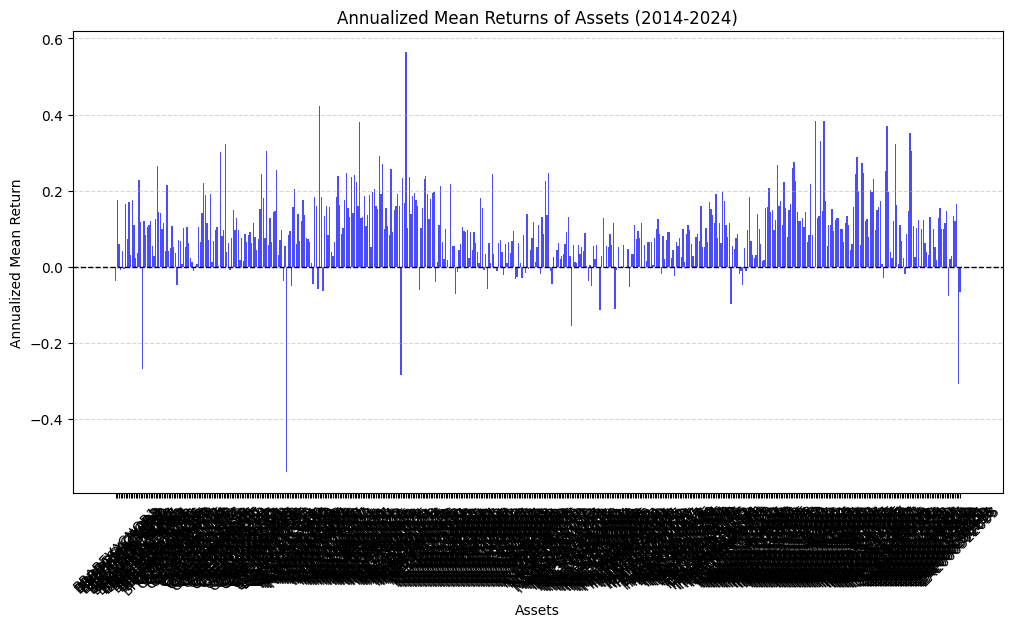

Mean Annualized Return Across Assets: 0.09289757823735516
Min Annualized Return: -0.5406776771934407
Max Annualized Return: 0.5633006519695752
Number of Negative Return Assets: 59


In [433]:
# Step 1: Calculate annualized mean returns
annualized_returns = returns_data.mean() * 12

# Step 2: Create a bar plot to visualize returns of each asset
plt.figure(figsize=(12, 6))
plt.bar(annualized_returns.index, annualized_returns.values, alpha=0.7, color='blue')
plt.axhline(0, color='black', linewidth=1, linestyle='--')  # Zero return line for reference

# Labels and title
plt.xlabel("Assets")
plt.ylabel("Annualized Mean Return")
plt.title("Annualized Mean Returns of Assets (2014-2024)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show plot
plt.show()

# Step 3: Print summary statistics
print("Mean Annualized Return Across Assets:", annualized_returns.mean())
print("Min Annualized Return:", annualized_returns.min())
print("Max Annualized Return:", annualized_returns.max())
print("Number of Negative Return Assets:", (annualized_returns < 0).sum())

In [434]:
num_portfolios = 6

mu_hat = np.array(simple_returns_M_2014_2024.T.mean() * 12)
Sigma = np.array(cov_matrix * 12)

num_assets = len(mu_hat)

# Define portfolio volatility and return functions
def port_vol(weights):
    return np.sqrt(weights.T @ Sigma @ weights)

def port_ret(weights):
    return mu_hat @ weights

# Constraints and bounds
bounds = [(0, None)] * num_assets

# Generate target returns
values = np.linspace(mv_r, mr_r, num_portfolios)

# Store results
target_returns = []
optimized_volatility = []

init_guess = np.array([1/num_assets] * num_assets)

# Iterate with tqdm for status bar
for mu_target in tqdm(values, desc='Optimizing Portfolios'):
    constraints = [
        {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},
        {'type': 'ineq', 'fun': lambda weights, mu_target=mu_target: port_ret(weights) - mu_target}
    ]

    result = sco.minimize(port_vol, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

    if result.success:
        optimized_volatility.append(result.fun)
        target_returns.append(mu_target)
    else:
        print(f"Optimization failed for target return {mu_target}: {result.message}")

# Convert results to arrays
target_returns = np.array(target_returns)
optimized_volatility = np.array(optimized_volatility)

# Report any missing portfolios due to optimization failure
missing = num_portfolios - len(target_returns)
if missing:
    print(f"Missing {missing}/{num_portfolios} optimizations due to failure.")

print("Target Returns:", target_returns)
print("Optimized Volatility:", optimized_volatility)


Optimizing Portfolios: 100%|██████████| 6/6 [00:33<00:00,  5.66s/it]

Target Returns: [0.07976694 0.17647368 0.27318042 0.36988717 0.46659391 0.56330065]
Optimized Volatility: [0.07360934 0.10118063 0.1560195  0.24147822 0.37399021 0.60631013]


In [435]:
# Convert the 'date' column to datetime objects if it's not already
risk_free_rate['date'] = pd.to_datetime(risk_free_rate['date'])

# Filter the DataFrame for the specified date range
start_date = pd.to_datetime('2009-01-01')
end_date = pd.to_datetime('2024-12-31')
filtered_df = risk_free_rate[(risk_free_rate['date'] >= start_date) & (risk_free_rate['date'] <= end_date)]

# Calculate the average risk-free rate
average_risk_free_rate = filtered_df['RF'].mean()

print(f"The average risk-free rate from 2014-01-01 to 2024-12-31 is: {average_risk_free_rate}")

The average risk-free rate from 2014-01-01 to 2024-12-31 is: 0.0008901041666666666


In [436]:
# Calculate mean returns and covariance matrix for annualized data
mu_hat = np.array(simple_returns_M_2014_2024.T.mean() * 12)
mu_hat_ante = np.array(simple_returns_M_2009_2013.T.mean() * 12)
Sigma = np.array(cov_matrix * 12)
Sigma_ante = np.array(cov_matrix_ante * 12)

num_assets = len(mu_hat)

# Define portfolio volatility and return functions
def port_vol(weights):
    return np.sqrt(weights.T @ Sigma @ weights)

def port_vol_ante(weights):
    return np.sqrt(weights.T @ Sigma_ante @ weights)

def port_ret(weights):
    return mu_hat @ weights

def port_ret_ante(weights):
    return mu_hat_ante @ weights

# Constraints and bounds
bounds = [(0, None)] * num_assets

# Generate target returns
num_portfolios = 6
values = np.linspace(mv_r, mr_r, num_portfolios)

# Store results
target_returns = []
optimized_volatility = []
optimized_weights = []  # Store optimized weights for each portfolio

init_guess = np.array([1/num_assets] * num_assets)

# Iterate with tqdm for status bar
for mu_target in tqdm(values, desc='Optimizing Portfolios'):
    constraints = [
        {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},
        {'type': 'ineq', 'fun': lambda weights, mu_target=mu_target: port_ret(weights) - mu_target}
    ]

    result = sco.minimize(port_vol, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

    if result.success:
        optimized_volatility.append(result.fun)
        target_returns.append(mu_target)
        optimized_weights.append(result.x)  # Store optimized weights
    else:
        print(f"Optimization failed for target return {mu_target}: {result.message}")

# Convert results to arrays
target_returns = np.array(target_returns)
optimized_volatility = np.array(optimized_volatility)
optimized_weights = np.array(optimized_weights)

# Report any missing portfolios due to optimization failure
missing = num_portfolios - len(target_returns)
if missing:
    print(f"Missing {missing}/{num_portfolios} optimizations due to failure.")

# Calculate ex-post annualized average return for each portfolio
ex_post_annualized_returns = np.array([port_ret(weights) for weights in optimized_weights])

# Calculate ex-ante annualized average return for each portfolio
ex_ante_annualized_returns = np.array([port_ret_ante(weights) for weights in optimized_weights])


# Calculate ex-post annualized volatility for each portfolio
ex_post_annualized_volatility = np.array([port_vol(weights) for weights in optimized_weights])

# Calculate ex-ante annualized volatility for each portfolio
ex_ante_annualized_volatility = np.array([port_vol_ante(weights) for weights in optimized_weights])

# Calculate ex-post annualized Sharpe ratio for each portfolio
risk_free_rate_float = average_risk_free_rate  # Annual risk-free rate
ex_post_sharpe_ratios = (ex_post_annualized_returns - risk_free_rate_float) / ex_post_annualized_volatility

# Calculate the ex-ante annualized Sharpe ratio for each porfolio
ex_ante_sharpe_ratios = (ex_ante_annualized_returns - risk_free_rate_float) / ex_ante_annualized_volatility

# Display results
print("Target Returns:", target_returns)
print("Optimized Volatility:", optimized_volatility)
print("Ex-post Annualized Returns:", ex_post_annualized_returns)
print("Ex-post Annualized Volatility:", ex_post_annualized_volatility)
print("Ex-post Annualized Sharpe Ratios:", ex_post_sharpe_ratios)
#print("Ex-ante Annualized Sharpe Ratios:", ex_ante_sharpe_ratios)

Optimizing Portfolios: 100%|██████████| 6/6 [00:35<00:00,  5.89s/it]

Target Returns: [0.07976694 0.17647368 0.27318042 0.36988717 0.46659391 0.56330065]
Optimized Volatility: [0.07360934 0.10118063 0.1560195  0.24147822 0.37399021 0.60631013]
Ex-post Annualized Returns: [0.07976694 0.17647368 0.27318042 0.36988717 0.46659391 0.56330065]
Ex-post Annualized Volatility: [0.07360934 0.10118063 0.1560195  0.24147822 0.37399021 0.60631013]
Ex-post Annualized Sharpe Ratios: [1.07156014 1.73534779 1.74523258 1.52807597 1.24522993 0.92759549]


In [437]:
# Create a DataFrame from the calculated ex-post metrics
ex_post_df = pd.DataFrame({
    'Ex-post Annualized Return': ex_post_annualized_returns,
    'Ex-post Annualized Volatility': ex_post_annualized_volatility,
    'Ex-post Annualized Sharpe Ratio': ex_post_sharpe_ratios,
    'Ex-ante Annualized Sharpe Ratio': ex_ante_sharpe_ratios
})

# Display the DataFrame
ex_post_df

,Ex-post Annualized Return,Ex-post Annualized Volatility,Ex-post Annualized Sharpe Ratio,Ex-ante Annualized Sharpe Ratio
0,0.079767,0.073609,1.071560,1.667805
1,0.176474,0.101181,1.735348,1.009037
2,0.273180,0.156020,1.745233,0.633828
3,0.369887,0.241478,1.528076,0.516793
4,0.466594,0.373990,1.245230,0.449715
5,0.563301,0.606310,0.927595,0.397503


In [438]:
# Create a DataFrame from the calculated ex-post metrics
ex_post_df = pd.DataFrame({
    'Ex-post Annualized Return': ex_post_annualized_returns,
    'Ex-post Annualized Volatility': ex_post_annualized_volatility,
    'Ex-post Annualized Sharpe Ratio': ex_post_sharpe_ratios
    #'Ex-ante Annualized Sharpe Ratio': ex_ante_sharpe_ratios
})

# Display the DataFrame
ex_post_df

,Ex-post Annualized Return,Ex-post Annualized Volatility,Ex-post Annualized Sharpe Ratio
0,0.079767,0.073609,1.071560
1,0.176474,0.101181,1.735348
2,0.273180,0.156020,1.745233
3,0.369887,0.241478,1.528076
4,0.466594,0.373990,1.245230
5,0.563301,0.606310,0.927595


In [439]:
# Calculate mean returns and covariance matrix for annualized data
mu_hat = np.array(simple_returns_M_2014_2024.T.mean() * 12)
mu_hat_ante = np.array(simple_returns_M_2009_2013.T.mean() * 12)
Sigma = np.array(cov_matrix * 12)
Sigma_ante = np.array(cov_matrix_ante * 12)

num_assets = len(mu_hat)

# Define portfolio volatility and return functions
def port_vol(weights):
    return np.sqrt(weights.T @ Sigma @ weights)

def port_vol_ante(weights):
    return np.sqrt(weights.T @ Sigma_ante @ weights)

def port_ret(weights):
    return mu_hat @ weights

def port_ret_ante(weights):
    return mu_hat_ante @ weights

# Constraints and bounds
bounds = [(0, None)] * num_assets

# Generate target returns
num_portfolios = 6
values = np.linspace(mv_r, mr_r, num_portfolios)

# Store results
target_returns = []
optimized_volatility = []
optimized_weights = []  # Store optimized weights for each portfolio

init_guess = np.array([1/num_assets] * num_assets)

# Iterate with tqdm for status bar
for mu_target in tqdm(values, desc='Optimizing Portfolios'):
    constraints = [
        {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},
        {'type': 'ineq', 'fun': lambda weights, mu_target=mu_target: port_ret(weights) - mu_target}
    ]

    result = sco.minimize(port_vol, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

    if result.success:
        optimized_volatility.append(result.fun)
        target_returns.append(mu_target)
        optimized_weights.append(result.x)  # Store optimized weights
    else:
        print(f"Optimization failed for target return {mu_target}: {result.message}")

# Convert results to arrays
target_returns = np.array(target_returns)
optimized_volatility = np.array(optimized_volatility)
optimized_weights = np.array(optimized_weights)

# Report any missing portfolios due to optimization failure
missing = num_portfolios - len(target_returns)
if missing:
    print(f"Missing {missing}/{num_portfolios} optimizations due to failure.")

# Calculate ex-post annualized average return for each portfolio
ex_post_annualized_returns = np.array([port_ret(weights) for weights in optimized_weights])

# Calculate ex-ante annualized average return for each portfolio
ex_ante_annualized_returns = np.array([port_ret_ante(weights) for weights in optimized_weights])


# Calculate ex-post annualized volatility for each portfolio
ex_post_annualized_volatility = np.array([port_vol(weights) for weights in optimized_weights])

# Calculate ex-ante annualized volatility for each portfolio
ex_ante_annualized_volatility = np.array([port_vol_ante(weights) for weights in optimized_weights])

# Calculate ex-post annualized Sharpe ratio for each portfolio
risk_free_rate_float = average_risk_free_rate  # Annual risk-free rate
ex_post_sharpe_ratios = (ex_post_annualized_returns - risk_free_rate_float) / ex_post_annualized_volatility

# Calculate the ex-ante annualized Sharpe ratio for each porfolio
ex_ante_sharpe_ratios = (ex_ante_annualized_returns - risk_free_rate_float) / ex_ante_annualized_volatility

# Display results
print("Target Returns:", target_returns)
print("Optimized Volatility:", optimized_volatility)
print("Ex-post Annualized Returns:", ex_post_annualized_returns)
print("Ex-post Annualized Volatility:", ex_post_annualized_volatility)
print("Ex-post Annualized Sharpe Ratios:", ex_post_sharpe_ratios)
print("Ex-ante Annualized Sharpe Ratios:", ex_ante_sharpe_ratios)

Optimizing Portfolios: 100%|██████████| 6/6 [00:33<00:00,  5.53s/it]

Target Returns: [0.07976694 0.17647368 0.27318042 0.36988717 0.46659391 0.56330065]
Optimized Volatility: [0.07360934 0.10118063 0.1560195  0.24147822 0.37399021 0.60631013]
Ex-post Annualized Returns: [0.07976694 0.17647368 0.27318042 0.36988717 0.46659391 0.56330065]
Ex-post Annualized Volatility: [0.07360934 0.10118063 0.1560195  0.24147822 0.37399021 0.60631013]
Ex-post Annualized Sharpe Ratios: [1.07156014 1.73534779 1.74523258 1.52807597 1.24522993 0.92759549]
Ex-ante Annualized Sharpe Ratios: [1.66780464 1.00903737 0.63382768 0.51679312 0.44971508 0.39750282]


In [440]:
# Create a DataFrame from the calculated ex-post metrics
ex_post_df = pd.DataFrame({
    'Ex-post Annualized Return': ex_post_annualized_returns,
    'Ex-post Annualized Volatility': ex_post_annualized_volatility,
    'Ex-post Annualized Sharpe Ratio': ex_post_sharpe_ratios,
    'Ex-ante Annualized Sharpe Ratio': ex_ante_sharpe_ratios
})

# Display the DataFrame
ex_post_df

,Ex-post Annualized Return,Ex-post Annualized Volatility,Ex-post Annualized Sharpe Ratio,Ex-ante Annualized Sharpe Ratio
0,0.079767,0.073609,1.071560,1.667805
1,0.176474,0.101181,1.735348,1.009037
2,0.273180,0.156020,1.745233,0.633828
3,0.369887,0.241478,1.528076,0.516793
4,0.466594,0.373990,1.245230,0.449715
5,0.563301,0.606310,0.927595,0.397503


In [441]:
# Example asset return and covariance matrix (replace with real data)
expected_returns = np.array(simple_returns_M_2014_2024.T.mean() * 12)
cov_matrix = np.array(cov_matrix * 12)

rf_rate = average_risk_free_rate  # Annual risk-free rate

# Portfolio performance functions
def portfolio_return(weights):
    return np.dot(weights, expected_returns)

def portfolio_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def sharpe_ratio(weights):
    return -(portfolio_return(weights) - rf_rate) / portfolio_volatility(weights)  # Negative for minimization

num_assets = len(expected_returns)
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})  # Constraint: Weights sum to 1
bounds = [(0, 1)] * num_assets  # Weights between 0 and 1 (long-only)
init_weights = np.array(num_assets * [1 / num_assets])  # Equal initial weights

opt_sharpe = sco.minimize(sharpe_ratio, init_weights, method='SLSQP', bounds=bounds, constraints=cons)

# Extract optimal weights
opt_weights = opt_sharpe.x
opt_return = portfolio_return(opt_weights)
opt_volatility = portfolio_volatility(opt_weights)
opt_sharpe_ratio = -opt_sharpe.fun  # Convert back to positive

# Print results
print("Optimal Portfolio Weights:", opt_weights)
print("Expected Return:", opt_return)
print("Expected Volatility:", opt_volatility)
print("Sharpe Ratio:", opt_sharpe_ratio)

Optimal Portfolio Weights: [8.15954666e-14 4.57678040e-14 9.01153344e-14 1.79555088e-13
 1.19342574e-13 7.77956070e-14 7.13249740e-14 2.29176902e-14
 3.38952499e-14 2.22432415e-13 1.29774644e-13 7.78039054e-14
 1.18327060e-13 4.55510497e-14 7.87205287e-14 4.28249308e-14
 4.12663246e-13 2.98338621e-13 4.27881881e-13 3.86546367e-13
 3.84213579e-14 6.79961536e-16 1.37691401e-13 5.02235220e-13
 5.64495776e-14 1.23493455e-13 2.27756501e-14 1.55466082e-13
 4.34021716e-13 1.77965761e-14 5.22576309e-14 1.20328034e-13
 2.51982595e-14 1.91648789e-14 2.52028775e-13 1.43223378e-14
 9.77577523e-14 1.29828560e-13 1.16780266e-13 2.19929223e-14
 4.02958832e-14 1.30204269e-13 1.39263024e-13 1.12366771e-13
 6.72687956e-14 7.68982162e-15 9.76533292e-14 1.69784634e-13
 6.48684764e-14 7.86331702e-14 3.01342887e-14 6.23793444e-14
 9.87372069e-14 9.80864102e-13 1.46741172e-02 1.48527855e-13
 6.30114526e-14 1.35927377e-13 2.13128988e-13 9.60975192e-14
 1.43054591e-13 1.26368990e-13 8.76729618e-15 7.35469358e-

### Efficient frontier

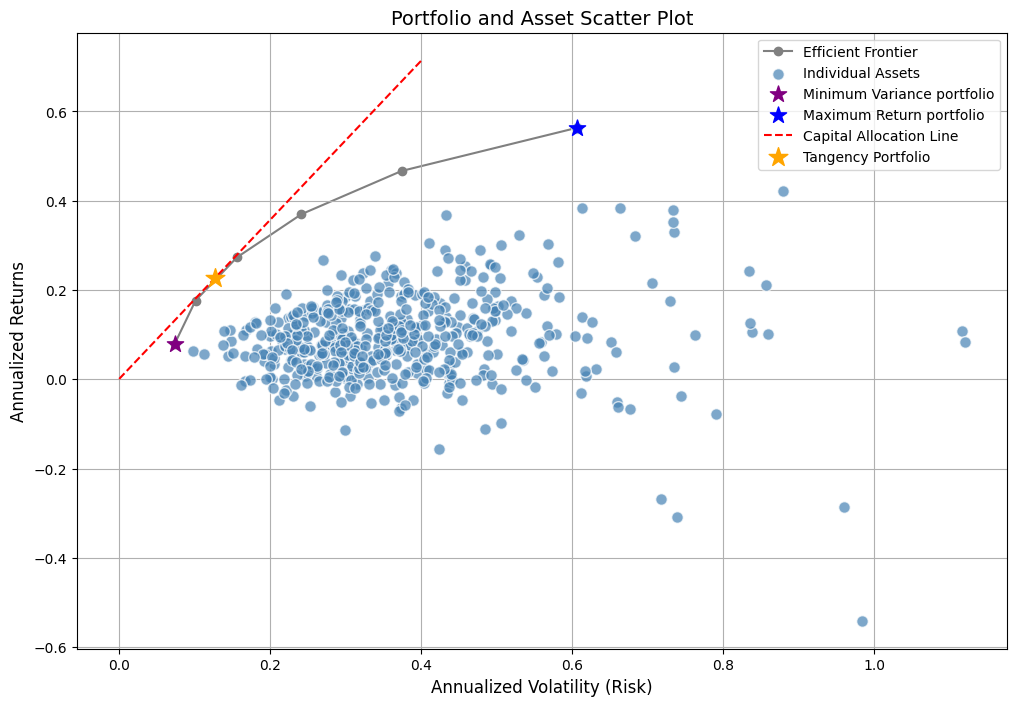

In [442]:
# Annualized returns and volatility for individual assets
asset_returns = returns_data.mean() * 12
asset_volatility = returns_data.std() * np.sqrt(12)

df = simple_returns_M_2014_2024.T
df.index = pd.to_datetime(df.index)

mu = df.mean()*12
S = df.cov()*12

#ef = EfficientFrontier(mu, S, weight_bounds=(0, 1), solver=None, verbose=False, solver_options=None)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

#plot_efficient_frontier(ef, ax=ax, show_assets=False)
#frontier_line = ax.lines[0]  # efficient frontier is typically the first line
#frontier_line.set_color('black')

# Efficient frontier (lowest layer)
ax.plot(optimized_volatility, target_returns, marker='o', linestyle='-',
        linewidth=1.5, color='grey', label='Efficient Frontier', zorder=1)

# Individual assets (above the efficient frontier)
ax.scatter(asset_volatility, asset_returns,
           marker='o', s=70, color='steelblue', alpha=0.7,
           edgecolors='w', linewidths=1, label='Individual Assets', zorder=2)

# Minimum variance portfolio
ax.scatter(mv_v, mv_r,
           marker='*', s=150, c='purple', label='Minimum Variance portfolio', zorder=4)

# Maximum return portfolio
ax.scatter(mr_v, mr_r,
           marker='*', s=150, c='blue', label='Maximum Return portfolio', zorder=4)


x_cal = np.linspace(0, 0.4, 100)  # Extend CAL beyond the efficient frontier
y_cal = rf_rate + (opt_sharpe_ratio * x_cal)  # Equation of the CAL

plt.plot(x_cal, y_cal, label="Capital Allocation Line", linestyle='dashed', color='red')

# Plot Tangency Portfolio (Optimal Portfolio)
plt.scatter(opt_volatility, opt_return, marker="*", color="orange", s=200, label="Tangency Portfolio", zorder=5)


# Set titles and labels
ax.set_title("Portfolio and Asset Scatter Plot", fontsize=14)
ax.set_xlabel("Annualized Volatility (Risk)", fontsize=12)
ax.set_ylabel("Annualized Returns", fontsize=12)

# Add legend
ax.legend()

# Display the plot
plt.grid(True)
plt.show()

### `Section Assignment 2`

In [443]:
filtered_EM_merged_DS_EScore_Y = EScore_Y_2009_2024.copy()

In [444]:
# Calculate the mean of ESG scores across years, excluding 'NAME' and 'ISIN'
filtered_EM_merged_DS_EScore_Y['Mean'] = filtered_EM_merged_DS_EScore_Y.iloc[:, 8:].mean(axis=1)

# Print or use the result as needed
filtered_EM_merged_DS_EScore_Y

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00,Mean
ISIN,,,,,,,,,,,,,,,,
BRABEVACNOR1,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78,67.297143
BRBBASACNOR3,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30,93.187143
BRBBDCACNPR8,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80,95.824286
BRBRFSACNOR8,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34,78.962857
BRBRKMACNPA4,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77,50.584286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06,36.228571
ZAE000255915,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75,81.838571
ZAE000298253,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96,65.560000


In [445]:
ESG_weights = pd.DataFrame(optimized_weights)
ESG_weights = ESG_weights.T
ESG_weights

,0,1,2,3,4,5
0,9.444546e-17,1.763234e-16,3.234543e-16,7.678377e-18,2.744988e-16,1.334196e-15
1,0.000000e+00,0.000000e+00,1.292952e-15,0.000000e+00,1.101676e-15,1.196559e-16
2,0.000000e+00,3.500228e-16,2.664521e-16,0.000000e+00,0.000000e+00,9.176190e-15
3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.409215e-12
4,0.000000e+00,1.184614e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
505,0.000000e+00,0.000000e+00,8.887164e-17,1.343219e-16,2.143416e-16,5.019439e-13
506,3.284419e-17,0.000000e+00,1.674458e-17,2.402293e-17,3.886443e-17,0.000000e+00
507,9.549263e-17,3.659535e-16,1.406846e-16,0.000000e+00,0.000000e+00,2.605773e-15
508,6.242859e-17,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.165274e-13


In [446]:
# Create a copy not to mess up things
filtered_ESG = filtered_EM_merged_DS_EScore_Y.copy()

# Multiply the 'Mean' column with each column in the weights DataFrame
weighted_values = ESG_weights.multiply(filtered_EM_merged_DS_EScore_Y['Mean'].values, axis=0)

# Calculate column sums
column_sums = weighted_values.sum()

print("Column sums:")
print(column_sums)


Column sums:
0    65.392784
1    62.381033
2    58.367412
3    56.357200
4    50.200311
5    38.248572
dtype: float64


In [447]:
weighted_values
num_portfolios = weighted_values.shape[1]
for i in range(num_portfolios):
     filtered_ESG['ESG_weights_' + str(i)] = weighted_values.iloc[:, i].values

In [448]:
filtered_ESG

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,...,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00,Mean,ESG_weights_0,ESG_weights_1,ESG_weights_2,ESG_weights_3,ESG_weights_4,ESG_weights_5
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,...,77.48,67.51,62.78,67.297143,6.355909e-15,1.186606e-14,2.176755e-14,5.167328e-16,1.847298e-14,8.978755e-14
BRBBASACNOR3,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,...,91.20,92.86,93.30,93.187143,0.000000e+00,0.000000e+00,1.204865e-13,0.000000e+00,1.026620e-13,1.115039e-14
BRBBDCACNPR8,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,...,95.52,94.60,97.80,95.824286,0.000000e+00,3.354069e-14,2.553258e-14,0.000000e+00,0.000000e+00,8.793019e-13
BRBRFSACNOR8,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,...,81.78,82.94,82.34,78.962857,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.060900e-10
BRBRKMACNPA4,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,...,51.08,48.23,50.77,50.584286,0.000000e+00,5.992284e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,...,38.62,31.87,37.06,36.228571,0.000000e+00,0.000000e+00,3.219693e-15,4.866290e-15,7.765290e-15,1.818471e-11
ZAE000255915,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,...,81.45,79.12,84.75,81.838571,2.687922e-15,0.000000e+00,1.370353e-15,1.966002e-15,3.180609e-15,0.000000e+00
ZAE000298253,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,...,73.50,74.37,63.96,65.560000,6.260497e-15,2.399191e-14,9.223282e-15,0.000000e+00,0.000000e+00,1.708345e-13


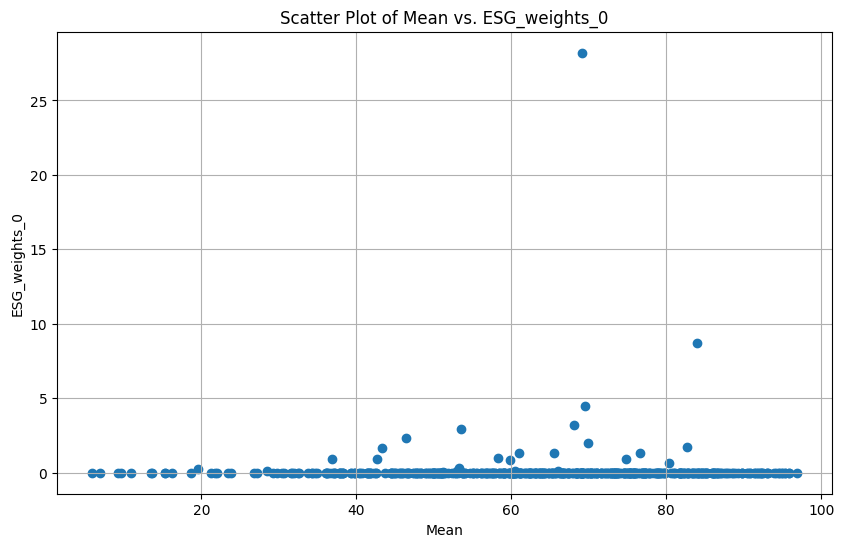

In [449]:
plt.figure(figsize=(10, 6))
plt.scatter(filtered_ESG['Mean'], filtered_ESG['ESG_weights_0'])
plt.xlabel('Mean')
plt.ylabel('ESG_weights_0')
plt.title('Scatter Plot of Mean vs. ESG_weights_0')
plt.grid(True)
plt.show()

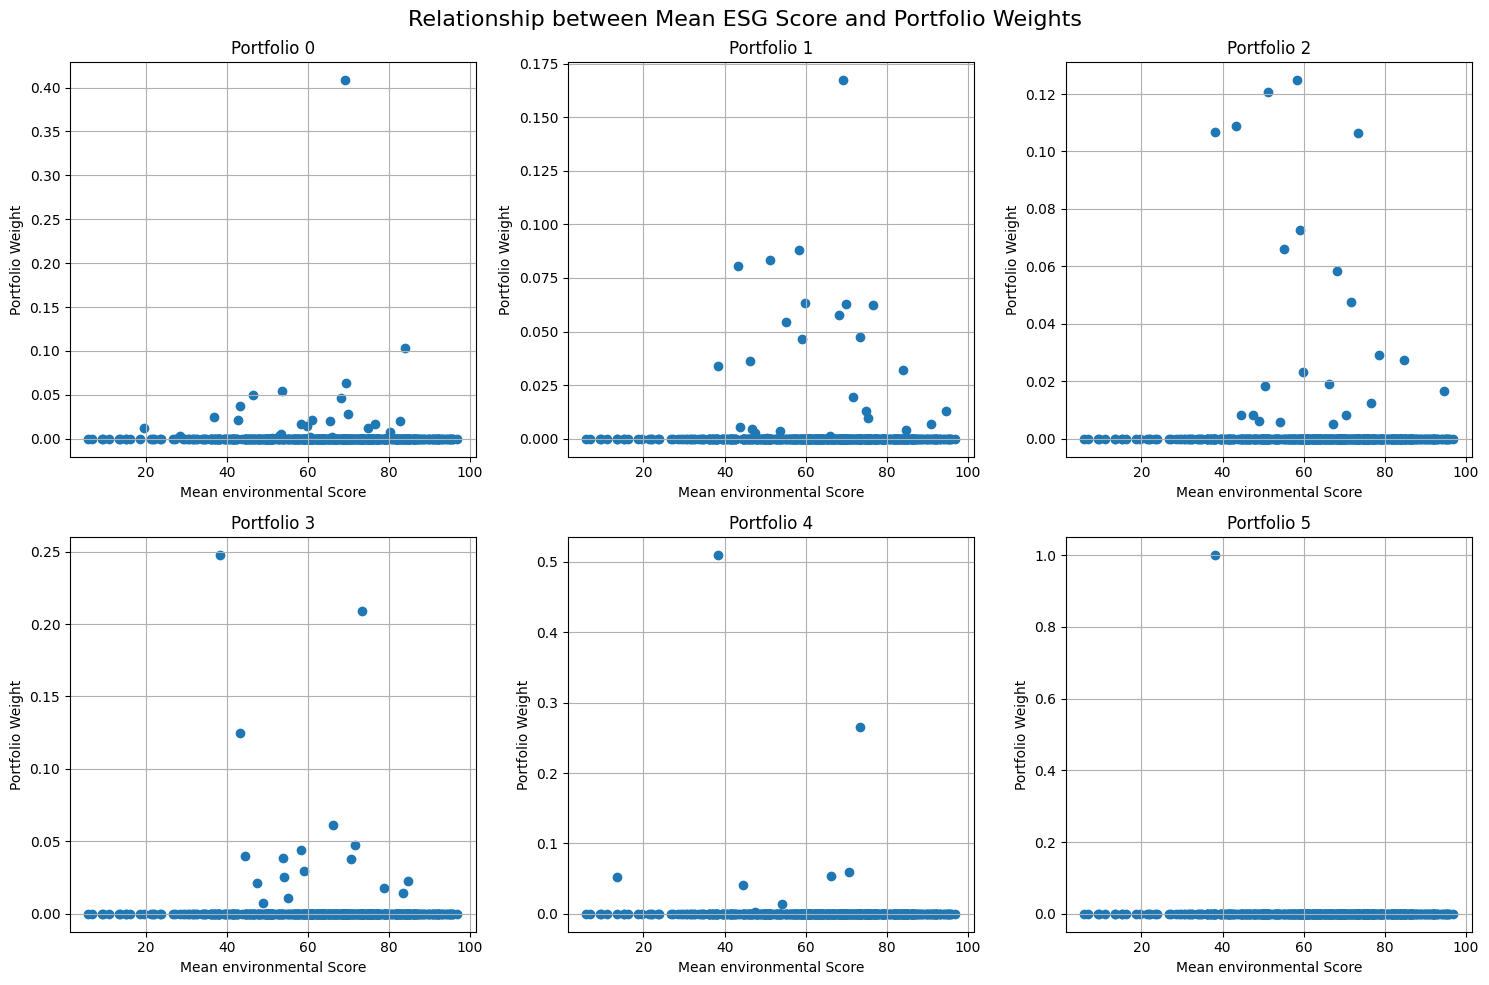

In [450]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Relationship between Mean ESG Score and Portfolio Weights', fontsize=16)

portfolio_names = ['Portfolio 0', 'Portfolio 1', 'Portfolio 2', 'Portfolio 3', 'Portfolio 4','Portfolio 5','Portfolio 6','Portfolio 7','Portfolio 8','Portfolio 9', 'Portfolio 10','Portfolio 11','Portfolio 12']

for i, ax in enumerate(axes.flatten()):
    ax.scatter(filtered_ESG['Mean'], ESG_weights.iloc[:, i])  # Use ESG_weights columns
    ax.set_xlabel('Mean environmental Score')
    ax.set_ylabel('Portfolio Weight')
    ax.set_title(portfolio_names[i])
    ax.grid(True)

plt.tight_layout()
plt.show()

In [451]:
optimized_weights

array([[9.44454555e-17, 0.00000000e+00, 0.00000000e+00, ...,
        9.54926301e-17, 6.24285873e-17, 7.48961911e-17],
       [1.76323432e-16, 0.00000000e+00, 3.50022832e-16, ...,
        3.65953499e-16, 0.00000000e+00, 7.27101563e-16],
       [3.23454257e-16, 1.29295248e-15, 2.66452078e-16, ...,
        1.40684591e-16, 0.00000000e+00, 0.00000000e+00],
       [7.67837685e-18, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.74498784e-16, 1.10167557e-15, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.33419562e-15, 1.19655875e-16, 9.17619046e-15, ...,
        2.60577313e-15, 4.16527449e-13, 0.00000000e+00]])

In [452]:
#VOLATILITY
filtered_2014_merged_DS_R_USD_M = simple_returns_M_2014_2024.copy()
start_year = pd.to_datetime('2013-12-31')
end_year = pd.to_datetime('2024-12-31')

# Select columns within the desired date range for returns calculation
date_2014 = [col for col in filtered_2014_merged_DS_R_USD_M.columns[4:]
                         if start_year <= pd.to_datetime(col, errors='coerce') <= end_year
                         and pd.notna(pd.to_datetime(col, errors='coerce'))]  # Check for valid dates

# Keep only the columns in the df which are in the date_2014 list
columns_to_keep = filtered_2014_merged_DS_R_USD_M.columns[:4].tolist() + date_2014  # Add the first 4 columns to the list
filtered_2014_merged_DS_R_USD_M = filtered_2014_merged_DS_R_USD_M[columns_to_keep]

T=120

# Calculate volatility for each asset
volatilities = []
for i in range(filtered_2014_merged_DS_R_USD_M.shape[0]): # Iterate using numerical index
    R_p_t = filtered_2014_merged_DS_R_USD_M.iloc[i, 4:].values  # Returns for the asset
    mu_p = np.mean(R_p_t)  # Mean return for the asset
    sigma = np.sqrt((1 / T) * np.sum((R_p_t - mu_p) ** 2))  # Volatility calculation
    volatilities.append(sigma)

# Add the volatility column to the DataFrame
filtered_2014_merged_DS_R_USD_M['Volatility'] = volatilities
filtered_2014_merged_DS_R_USD_M.head()

,2014-01-31 00:00:00,2014-02-28 00:00:00,2014-03-31 00:00:00,2014-04-30 00:00:00,2014-05-30 00:00:00,2014-06-30 00:00:00,2014-07-31 00:00:00,2014-08-29 00:00:00,2014-09-30 00:00:00,2014-10-31 00:00:00,...,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,Volatility
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,-0.081488,0.087626,0.039537,-0.021640,-0.030519,0.011256,-0.023384,0.053382,-0.101144,0.035225,...,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048,0.091295
BRBBASACNOR3,-0.165964,0.033939,0.158901,0.036656,-0.027553,0.124174,0.085073,0.281583,-0.332351,0.094324,...,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255,0.155013
BRBBDCACNPR8,-0.121563,0.085193,0.185800,0.077213,-0.060868,0.047383,0.053240,0.197649,-0.219025,0.072200,...,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998,0.134596
BRBRFSACNOR8,-0.137319,0.029053,0.092648,0.125540,-0.048807,0.127229,0.018894,0.092953,-0.111890,0.105586,...,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831,0.147839
BRBRKMACNPA4,-0.138089,-0.098876,0.140372,-0.102991,-0.041582,-0.020550,-0.031409,0.100712,-0.029674,0.117397,...,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886,0.159906


In [453]:
num_portfolios = len(optimized_weights)

for i in range(num_portfolios):
    print(f"Portfolio {i + 1}:")
    current_weights = optimized_weights[i]

    # Get indices where weights are greater than 0.01
    significant_indices = np.where(current_weights > 0.01)[0]

    # Print weights, asset names, ISINs, and annualized returns
    for index in significant_indices:
        asset_isin = filtered_ESG.index[index]
        weight = current_weights[index]

        # Use the index directly to access annualized_returns
        annualized_return = annualized_returns.iloc[index]
        annualized_volatility = filtered_2014_merged_DS_R_USD_M['Volatility'].iloc[index]

        print(f" (ISIN: {asset_isin}): {weight:.4f}, Annualized Return: {annualized_return:.4f}, Annualized Volatility: {annualized_volatility:.4f}")

    print("-" * 20)  # Separator between portfolios

Portfolio 1:
 (ISIN: BRKLBNACNPR9): 0.0207, Annualized Return: 0.0558, Annualized Volatility: 0.0802
 (ISIN: CNE1000002S8): 0.0466, Annualized Return: 0.0959, Annualized Volatility: 0.1115
 (ISIN: EGS60081C014): 0.0544, Annualized Return: 0.0296, Annualized Volatility: 0.0923
 (ISIN: INE009A01021): 0.0173, Annualized Return: 0.1623, Annualized Volatility: 0.0764
 (ISIN: INE016A01026): 0.0209, Annualized Return: 0.1006, Annualized Volatility: 0.0622
 (ISIN: INE030A01027): 0.0143, Annualized Return: 0.1403, Annualized Volatility: 0.0671
 (ISIN: INE059A01026): 0.0219, Annualized Return: 0.1316, Annualized Volatility: 0.0798
 (ISIN: INE361B01024): 0.0170, Annualized Return: 0.2340, Annualized Volatility: 0.0881
 (ISIN: KYG8020E1199): 0.0376, Annualized Return: 0.2456, Annualized Volatility: 0.1320
 (ISIN: MYL3395OO000): 0.0127, Annualized Return: 0.0205, Annualized Volatility: 0.1574
 (ISIN: PHY0005M1090): 0.0253, Annualized Return: 0.0474, Annualized Volatility: 0.0613
 (ISIN: PHY5764J148

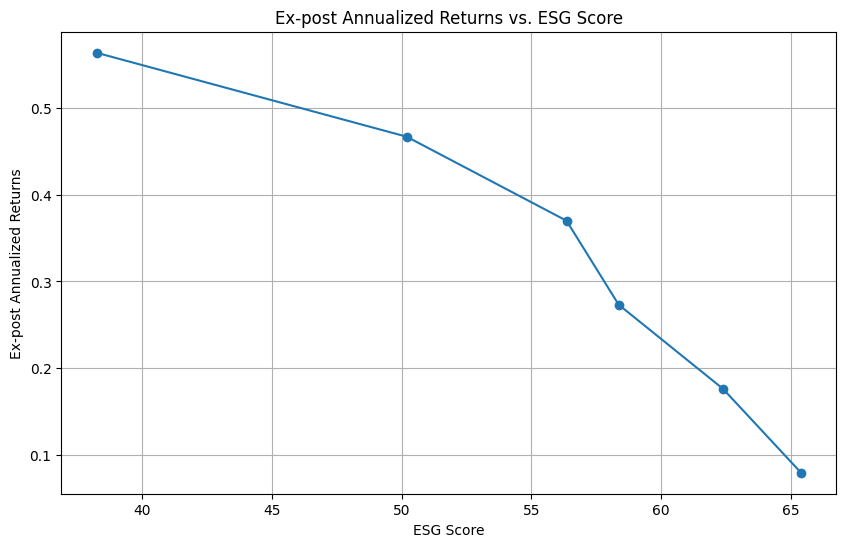

In [454]:
plt.figure(figsize=(10, 6))
plt.plot(column_sums, ex_post_annualized_returns, marker='o')
plt.xlabel('ESG Score')
plt.ylabel('Ex-post Annualized Returns')
plt.title('Ex-post Annualized Returns vs. ESG Score')
plt.grid(True)
plt.show()

In [455]:
# Create a dictionary to hold the data
portfolio_data = {
    'Environmental Score': column_sums.values,  # ESG scores
    'Annualized Return': ex_post_annualized_returns,  # Annualized returns
    'Annualized Volatility': ex_post_annualized_volatility  # Annualized volatilities
}

# Create the DataFrame
portfolio_df = pd.DataFrame(portfolio_data)

# Optionally, add a portfolio index column for better readability
portfolio_df.index = portfolio_df.index + 1
portfolio_df.index.name = 'Portfolio'

# Display the DataFrame
portfolio_df

,Environmental Score,Annualized Return,Annualized Volatility
Portfolio,,,
1,65.392784,0.079767,0.073609
2,62.381033,0.176474,0.101181
3,58.367412,0.273180,0.156020
4,56.357200,0.369887,0.241478
5,50.200311,0.466594,0.373990
6,38.248572,0.563301,0.606310


In [456]:
# Assuming 'EScore_Y_2009_2024' is your DataFrame and 'ISIN' is the column name
rows_to_get = ['PHY5764J1483', 'KYG8020E1199']
selected_rows = EScore[EScore['ISIN'].isin(rows_to_get)]

selected_rows

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
1457,KYG8020E1199,SEMICON.MNFG.INTL.,CN,EM,NaN,17.73,16.81,25.27,23.10,34.44,37.03,38.94,36.57,39.68,42.91,44.36,46.47,47.93,45.40
1589,PHY5764J1483,MANILA ELECTRIC,PH,EM,NaN,3.45,6.92,5.12,8.76,4.99,26.25,25.05,25.14,26.87,43.16,49.43,56.29,61.84,61.84


In [457]:
num_portfolios = len(optimized_weights)

for i in range(num_portfolios):
    print(f"Portfolio {i + 1}:")
    current_weights = optimized_weights[i]
    portfolio_values = []

    # Calculate portfolio's average ESG score
    portfolio_esg_score = np.dot(current_weights, filtered_ESG['Mean'])

    for j in range(len(current_weights)):
        # Check if the weight is greater than or equal to 0.01 before proceeding
        if current_weights[j] >= 0.01:
            asset_esg_score = filtered_ESG['Mean'][j]
            portfolio_value = (asset_esg_score - portfolio_esg_score) * current_weights[j]

            if portfolio_value != 0:
                portfolio_values.append((portfolio_value, j))

    portfolio_values.sort()  # Sort by portfolio_value (ascending)

    print("10 companies that drag down the E score per portfolio the most:")
    for k in range(min(10, len(portfolio_values))):
        value, asset_index = portfolio_values[k]
        # Only display if the value is negative
        if value < 0:
            asset_isin = filtered_ESG.index[asset_index]
            print(
                f"Asset {asset_index} (ISIN: {asset_isin}): Value = {value:.4f}, Weight = {current_weights[asset_index]:.4f}"
            )

    print("-" * 20)  # Separator between portfolios

Portfolio 1:
10 companies that drag down the E score per portfolio the most:
Asset 317 (ISIN: PHY5764J1483): Value = -0.9496, Weight = 0.0499
Asset 261 (ISIN: KYG8020E1199): Value = -0.8296, Weight = 0.0376
Asset 309 (ISIN: PHY0005M1090): Value = -0.7227, Weight = 0.0253
Asset 98 (ISIN: EGS60081C014): Value = -0.6449, Weight = 0.0544
Asset 289 (ISIN: MYL3395OO000): Value = -0.5810, Weight = 0.0127
Asset 137 (ISIN: INE016A01026): Value = -0.4749, Weight = 0.0209
Asset 173 (ISIN: INE361B01024): Value = -0.1208, Weight = 0.0170
Asset 149 (ISIN: INE059A01026): Value = -0.0959, Weight = 0.0219
Asset 143 (ISIN: INE030A01027): Value = -0.0787, Weight = 0.0143
--------------------
Portfolio 2:
10 companies that drag down the E score per portfolio the most:
Asset 261 (ISIN: KYG8020E1199): Value = -1.5337, Weight = 0.0805
Asset 188 (ISIN: INE752E01010): Value = -0.9352, Weight = 0.0834
Asset 175 (ISIN: INE423A01024): Value = -0.8230, Weight = 0.0341
Asset 317 (ISIN: PHY5764J1483): Value = -0.581

<ipython-input-457-65430866b685>:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [458]:
num_portfolios = len(optimized_weights)
asset_counts = defaultdict(int)  # Initialize a dictionary to store asset counts
asset_info = {}  # Store company name and country for each ISIN

# Use EScore DataFrame for ISIN, Name, and Country
for index, row in EScore.iterrows():
    asset_isin = index  # 'ISIN' is the index, not a column
    asset_info[asset_isin] = {
        'Name': row['Name'],
        'Country': row['Country']
    }

for i in range(num_portfolios):
    current_weights = optimized_weights[i]
    significant_indices = np.where(current_weights >= 0.01)[0]

    # Since optimized_weights are based on filtered_ESG,
    # we need to map indices back to EScore using ISIN
    filtered_ESG_isins = filtered_ESG.index.tolist()
    for index in significant_indices:
        asset_isin = filtered_ESG_isins[index]  # ISIN from filtered_ESG

        # Check if this ISIN is in EScore (it should be)
        if asset_isin in EScore.index:
            asset_counts[asset_isin] += 1

top_5_assets = sorted(asset_counts.items(), key=lambda item: item[1], reverse=True)[:5]

# Modified DataFrame creation:
top_5_assets_df = pd.DataFrame(top_5_assets, columns=['ISIN', 'Frequency'])
top_5_assets_df['Name'] = top_5_assets_df['ISIN'].map(lambda x: asset_info.get(x, {}).get('Name'))
top_5_assets_df['Country'] = top_5_assets_df['ISIN'].map(lambda x: asset_info.get(x, {}).get('Country'))

print(top_5_assets_df)

Empty DataFrame
Columns: [ISIN, Frequency, Name, Country]
Index: []


In [459]:
EScore

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


In [460]:
num_portfolios = len(optimized_weights)
asset_counts = defaultdict(int)  # Initialize a dictionary to store asset counts
asset_info = {}  # Store company name and country for each ISIN


for i in range(num_portfolios):
    current_weights = optimized_weights[i]
    significant_indices = np.where(current_weights >= 0.01)[0]
    for index in significant_indices:
        asset_isin = filtered_ESG.index[index]  # or filtered_ESG.iloc[index, filtered_ESG.columns.get_loc('ISIN')] if 'ISIN' is a column
        asset_counts[asset_isin] += 1

top_5_assets = sorted(asset_counts.items(), key=lambda item: item[1], reverse=True)[:5]

# Modified DataFrame creation:
top_5_assets_df = pd.DataFrame(top_5_assets, columns=['ISIN', 'Frequency'])


print(top_5_assets_df)

           ISIN  Frequency
0  INE423A01024          5
1  INE361B01024          4
2  KYG8020E1199          4
3  TW0008069006          4
4  CNE1000002S8          3


In [461]:
num_portfolios = len(optimized_weights)
asset_counts = defaultdict(int)  # Initialize a dictionary to store asset counts
asset_info = {}  # Store company name and country for each ISIN

# Build asset_info dictionary using EScore DataFrame
for index, row in EScore.iterrows():
    asset_isin = index # Assuming ISIN is the index of EScore
    asset_info[asset_isin] = {
        'Name': row['Name'],
        'Country': row['Country']
    }

for i in range(num_portfolios):
    current_weights = optimized_weights[i]
    significant_indices = np.where(current_weights >= 0.01)[0]
    for index in significant_indices:
        asset_isin = filtered_ESG.index[index]  # Assuming ISIN is the index of filtered_ESG
        asset_counts[asset_isin] += 1

top_5_assets = sorted(asset_counts.items(), key=lambda item: item[1], reverse=True)[:5]

# Modified DataFrame creation:
top_5_assets_df = pd.DataFrame(top_5_assets, columns=['ISIN', 'Frequency'])
top_5_assets_df['Name'] = top_5_assets_df['ISIN'].map(lambda x: asset_info.get(x, {}).get('Name'))
top_5_assets_df['Country'] = top_5_assets_df['ISIN'].map(lambda x: asset_info.get(x, {}).get('Country'))

print(top_5_assets_df)

           ISIN  Frequency  Name Country
0  INE423A01024          5  None    None
1  INE361B01024          4  None    None
2  KYG8020E1199          4  None    None
3  TW0008069006          4  None    None
4  CNE1000002S8          3  None    None


In [462]:
# Merge the DataFrames
merged_df = pd.merge(top_5_assets_df, EScore, on='ISIN', how='left')

# Select desired columns, using the correct column names after the merge
final_df = merged_df[['ISIN', 'Name_y', 'Frequency', 'Country_y']]  # Changed 'Name' to 'Name_x' and 'Country' to 'Country_x'

# Optionally, rename the columns for clarity
final_df = final_df.rename(columns={'Name_y': 'Name', 'Country_y': 'Country'})

# Print the final DataFrame
final_df

,ISIN,Name,Frequency,Country
0,INE423A01024,ADANI ENTERPRISES,5,IN
1,INE361B01024,DIVIS LABORATORIES,4,IN
2,KYG8020E1199,SEMICON.MNFG.INTL.,4,CN
3,TW0008069006,E INK HOLDINGS,4,TW
4,CNE1000002S8,COSCO SHIP.EN.TRSP. 'H',3,CN


<ipython-input-463-ce2ac0b1cbd0>:20: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-463-ce2ac0b1cbd0>:20: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-463-ce2ac0b1cbd0>:20: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-463-ce2ac0b1cbd0>:20: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

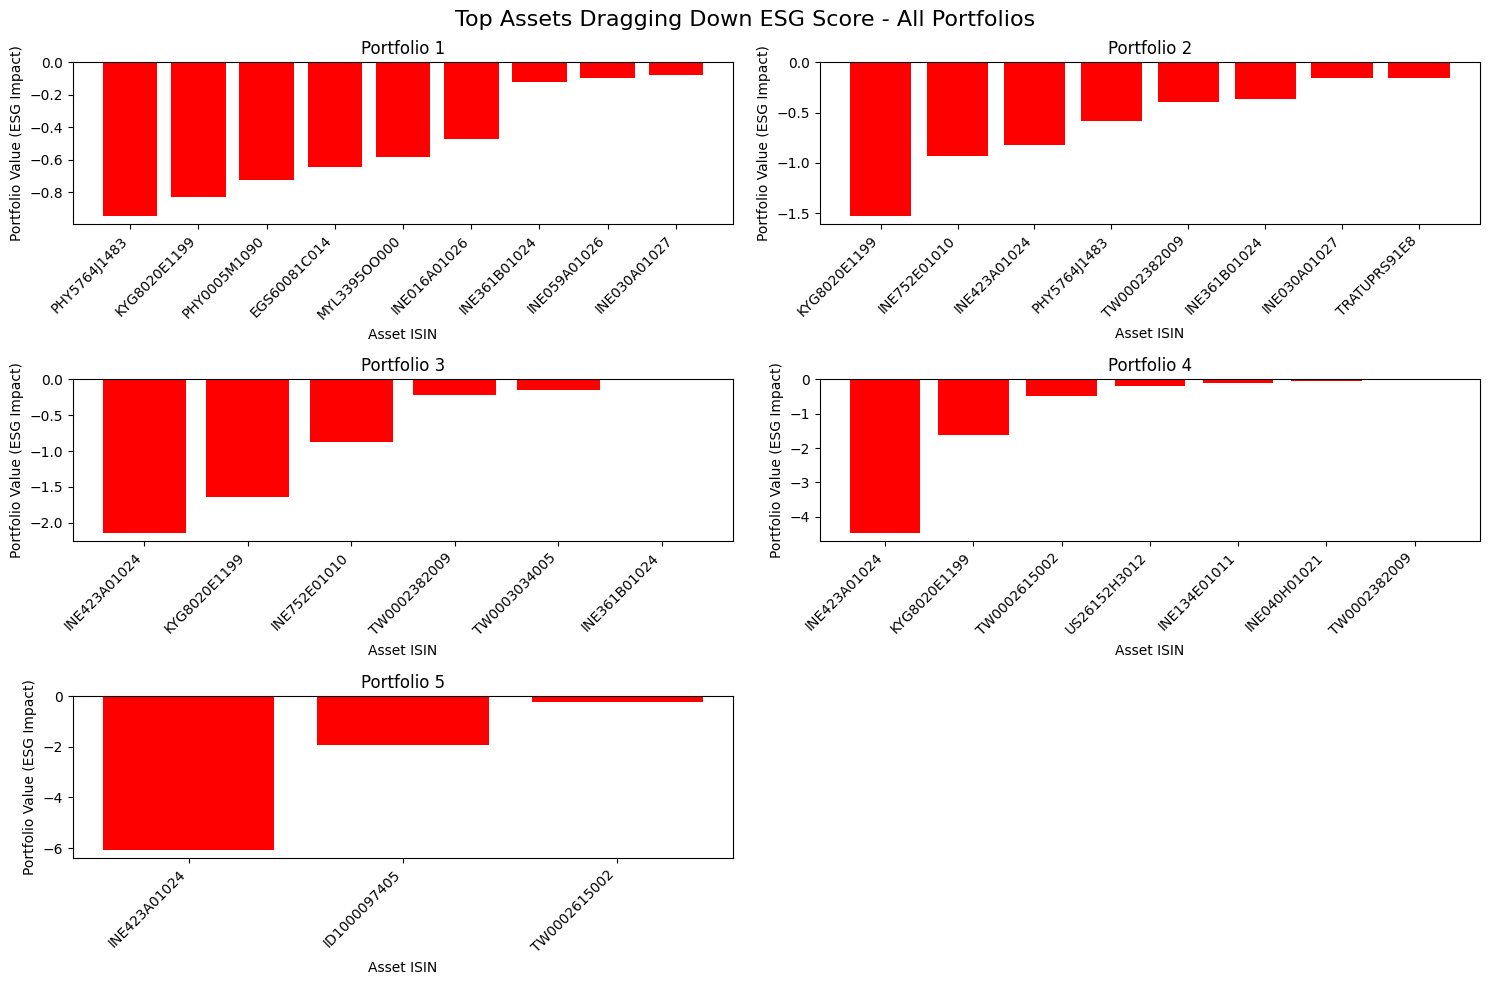

In [463]:
num_portfolios = len(optimized_weights)

fig, axes = plt.subplots(3, 2, figsize=(15, 10))  # Create a 3x4 grid of subplots
fig.suptitle('Top Assets Dragging Down ESG Score - All Portfolios', fontsize=16)

bar_width = 0.8  # Adjust this value for desired bar thickness

for i, ax in enumerate(axes.flatten()):  # Iterate through subplots
    if i == 5:  # Skip plotting for portfolio 12 (index 11)
        ax.axis('off')  # Hide the axes for this subplot
        continue  # Move to the next portfolio

    current_weights = optimized_weights[i]
    portfolio_values = []

    portfolio_esg_score = np.dot(current_weights, filtered_ESG['Mean'])

    for j in range(len(current_weights)):
        if current_weights[j] >= 0.01:
            asset_esg_score = filtered_ESG['Mean'][j]
            portfolio_value = (asset_esg_score - portfolio_esg_score) * current_weights[j]

            if portfolio_value < 0:  # Only consider negative values
                portfolio_values.append((portfolio_value, j))

    portfolio_values.sort()  # Sort by portfolio_value (ascending)

    # Extract values and ISINs for plotting
    top_values = [value for value, _ in portfolio_values[:10]]
    top_isins = [filtered_ESG.index[asset_index] for _, asset_index in portfolio_values[:10]]

    # Create bar chart in the current subplot with specified width and adjusted positions
    x_pos = np.arange(len(top_isins))  # Create x positions for bars
    ax.bar(x_pos, top_values, color='red', width=bar_width)

    # Set x-axis ticks and labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_isins, rotation=45, ha='right')

    ax.set_xlabel('Asset ISIN')
    ax.set_ylabel('Portfolio Value (ESG Impact)')
    ax.set_title(f'Portfolio {i + 1}')


plt.tight_layout()  # Adjust layout for better spacing
plt.show()

Portfolio 1:


<ipython-input-464-065829751775>:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



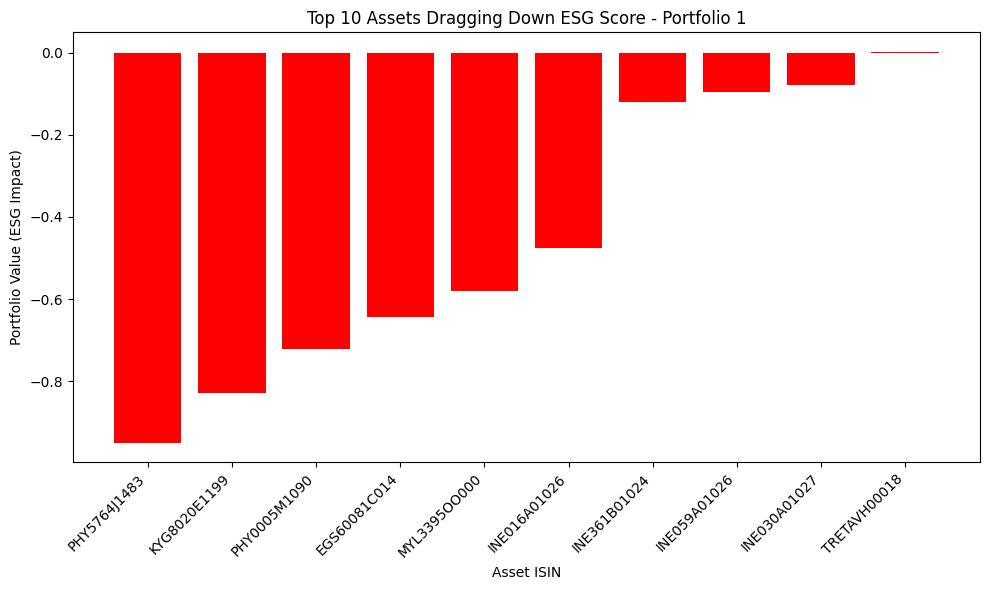

Portfolio 2:


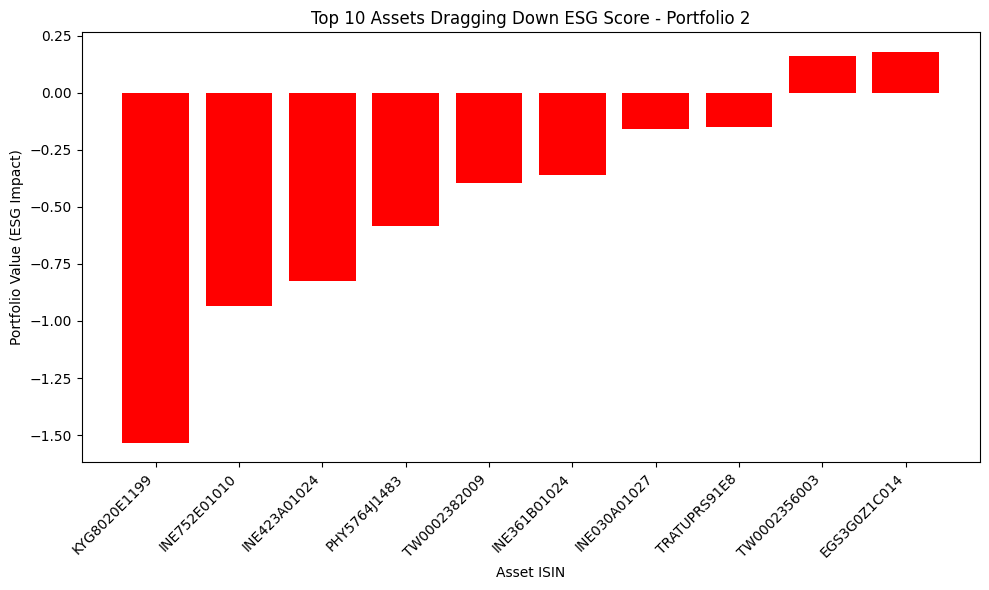

Portfolio 3:


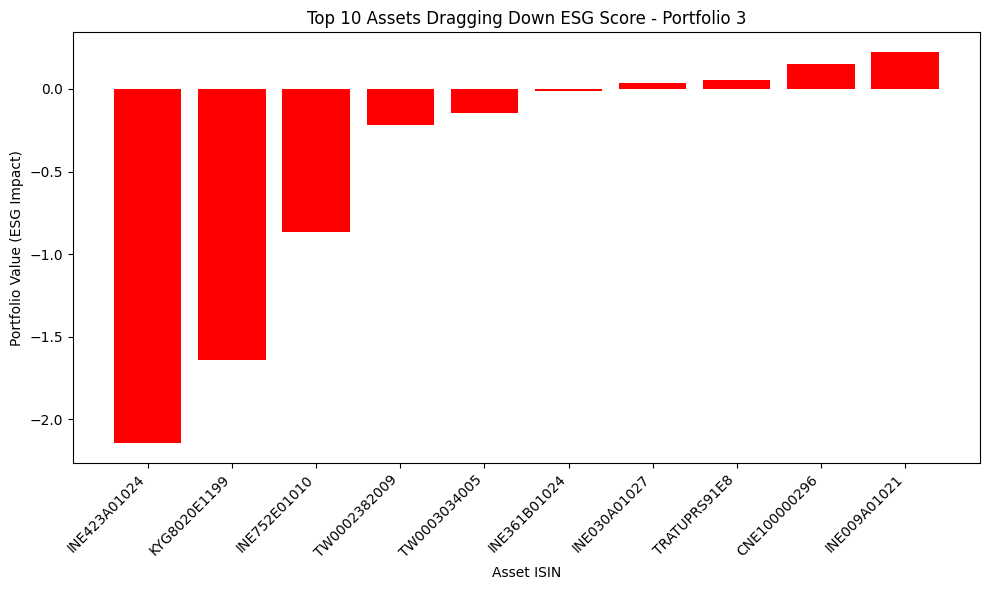

Portfolio 4:


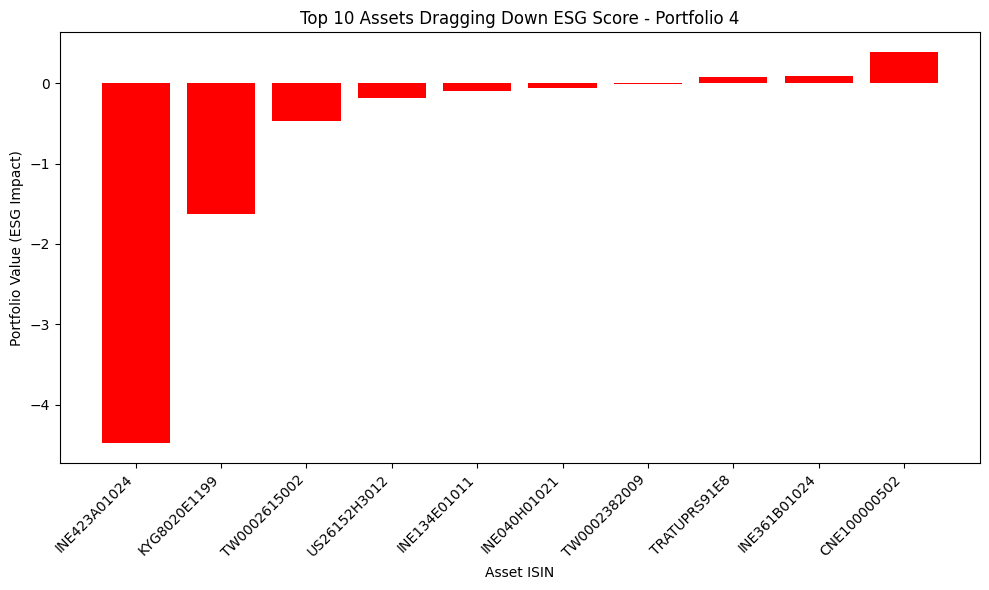

Portfolio 5:


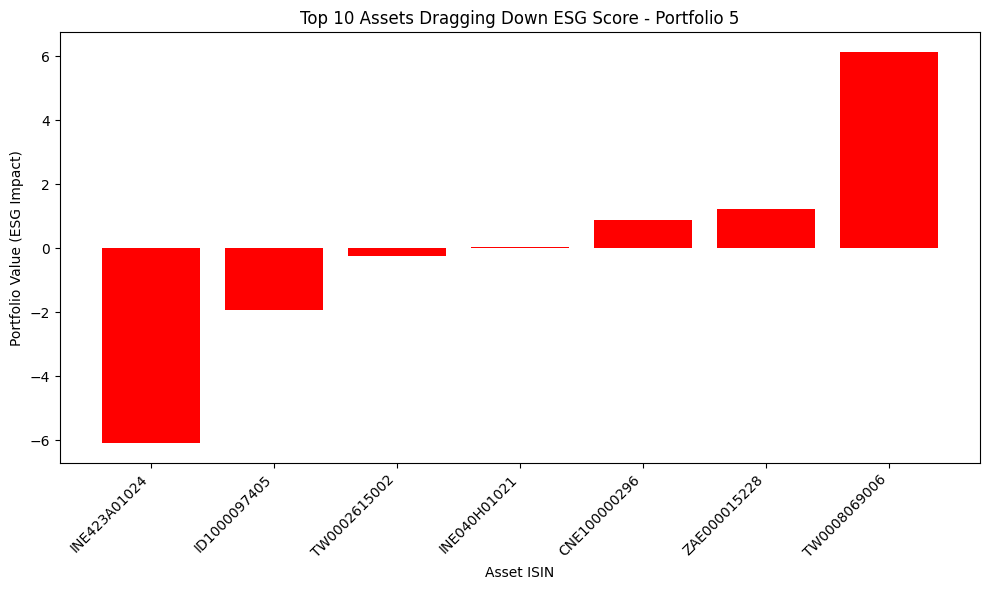

Portfolio 6:


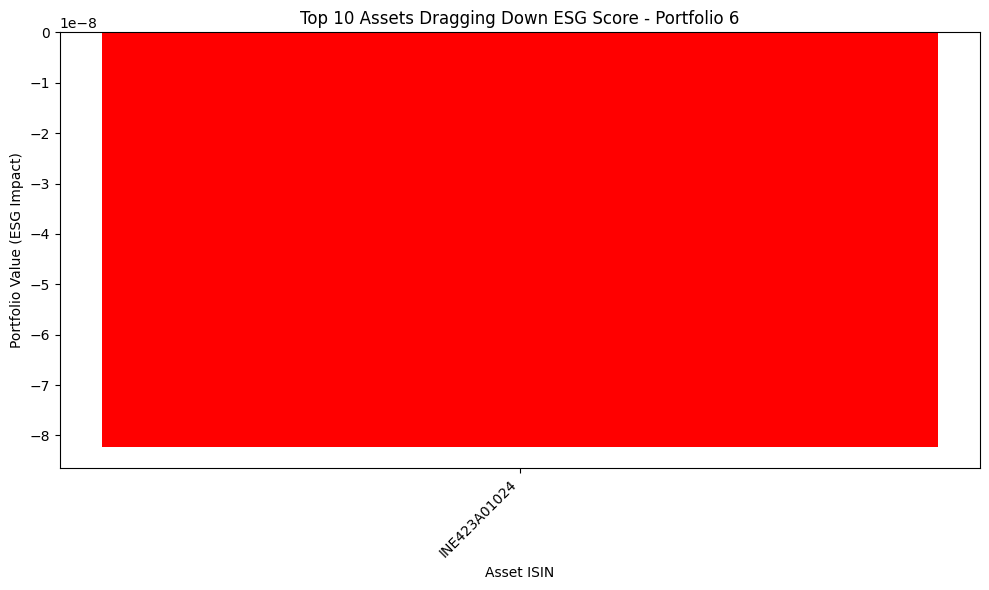

In [464]:
num_portfolios = len(optimized_weights)

for i in range(num_portfolios):
    print(f"Portfolio {i + 1}:")
    current_weights = optimized_weights[i]
    portfolio_values = []

    # Calculate portfolio's average ESG score
    portfolio_esg_score = np.dot(current_weights, filtered_ESG['Mean'])

    for j in range(len(current_weights)):
        if current_weights[j] >= 0.01:
            asset_esg_score = filtered_ESG['Mean'][j]
            portfolio_value = (asset_esg_score - portfolio_esg_score) * current_weights[j]

            if portfolio_value != 0:
                portfolio_values.append((portfolio_value, j))

    portfolio_values.sort()  # Sort by portfolio_value (ascending)

    # Store top 10 assets and values for plotting
    top_10_values = [value for value, _ in portfolio_values[:10]]
    top_10_isins = [filtered_ESG.index[asset_index] for _, asset_index in portfolio_values[:10]]

    # Create bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(top_10_isins, top_10_values, color='red')  # Use red for negative impact
    plt.xlabel('Asset ISIN')
    plt.ylabel('Portfolio Value (ESG Impact)')
    plt.title(f'Top 10 Assets Dragging Down ESG Score - Portfolio {i + 1}')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

In [465]:
# Assuming 'simple_returns_M_2009_2024' is your DataFrame and columns are datetime objects
start_date = pd.to_datetime('2014-01-01')
simple_returns_M_2014_2024 = simple_returns_M_2009_2024.loc[:, simple_returns_M_2009_2024.columns >= start_date]
simple_returns_M_2014_2024

,2014-01-31,2014-02-28,2014-03-31,2014-04-30,2014-05-30,2014-06-30,2014-07-31,2014-08-29,2014-09-30,2014-10-31,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,-0.081488,0.087626,0.039537,-0.021640,-0.030519,0.011256,-0.023384,0.053382,-0.101144,0.035225,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
BRBBASACNOR3,-0.165964,0.033939,0.158901,0.036656,-0.027553,0.124174,0.085073,0.281583,-0.332351,0.094324,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
BRBBDCACNPR8,-0.121563,0.085193,0.185800,0.077213,-0.060868,0.047383,0.053240,0.197649,-0.219025,0.072200,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
BRBRFSACNOR8,-0.137319,0.029053,0.092648,0.125540,-0.048807,0.127229,0.018894,0.092953,-0.111890,0.105586,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
BRBRKMACNPA4,-0.138089,-0.098876,0.140372,-0.102991,-0.041582,-0.020550,-0.031409,0.100712,-0.029674,0.117397,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,-0.081956,0.074204,0.039506,-0.005325,0.117630,-0.005184,-0.012862,-0.008018,-0.098141,-0.148107,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
ZAE000255915,-0.078198,0.060456,0.183882,0.032279,-0.004325,0.042585,0.029630,0.002107,-0.108775,0.155667,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
ZAE000298253,-0.069950,0.053963,-0.058240,0.051648,0.031664,0.064829,-0.039706,-0.022358,-0.188283,-0.056349,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888


# **Question 3: Minimum variance portfolio & E-Score improvement (30 points)**

In [466]:
#MEEEEEERGE

# Merging the EScore to EM, from 2003 to 2023

# Merging the data to filter per region
merged_DS_EScore_Y = pd.merge(DS_EScore_Y, Static, on='ISIN', how='inner')
merged_DS_EScore_Y = merged_DS_EScore_Y[['ISIN', 'Name', 'Region'] + [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Region', 'NAME']]]

#Keeping only the columns between 31/12/03 and 31/12/23
start_date = pd.to_datetime('2002-12-31')
end_date = pd.to_datetime('2023-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_EScore_Y = merged_DS_EScore_Y[selected_columns]


# Filter on EM countries
EM_merged_DS_EScore_Y = merged_DS_EScore_Y[merged_DS_EScore_Y['Region'] == 'EM']
EM_merged_DS_EScore_Y

<ipython-input-466-0a9241ab74ab>:14: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



,ISIN,Name,Country,Region,2003,2004,2005,2006,2007,2008,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,ARALUA010258,ALUAR,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,15.82,13.26,12.26,11.05,13.19,12.21,17.65
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,51.51,56.64,76.16,84.68,82.48,88.36,86.99,79.68
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,32.51,33.47,33.72,33.41,33.52,38.37,36.83,48.05
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,17.85,36.12,45.19,48.35,52.97,63.43,53.70,47.78
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,NaN,NaN,...,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,NaN,NaN,NaN,...,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,NaN,NaN,NaN,NaN,NaN,55.21,...,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,NaN,NaN,NaN,NaN,NaN,...,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,NaN,NaN,NaN,NaN,NaN,...,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


## **REBALANCED PORTFOLIO**


In [467]:
#WIDE TO LONG FORMAT FOR OUR ESCORE DATAFRAME

# Reset the index to make 'ISIN' a regular column

EScore_Y_2009_2024 = EScore_Y_2009_2024.reset_index()

# Melt the DataFrame to long format
long_filtered_EM_merged_DS_EScore_Y = pd.melt(
    EScore_Y_2009_2024,
    id_vars=['ISIN'],  # Include all metadata columns as id_vars
    var_name='Date',
    value_name='E_Score'
)

# Convert 'Date' column to datetime
long_filtered_EM_merged_DS_EScore_Y['Date'] = pd.to_datetime(long_filtered_EM_merged_DS_EScore_Y['Date'])

# Display the long-format DataFrame
long_filtered_EM_merged_DS_EScore_Y.head()

,ISIN,Date,E_Score
0,BRABEVACNOR1,2009-01-01,NaN
1,BRBBASACNOR3,2009-01-01,68.98
2,BRBBDCACNPR8,2009-01-01,78.70
3,BRBRFSACNOR8,2009-01-01,53.61
4,BRBRKMACNPA4,2009-01-01,58.64


In [468]:
#WIDE TO LONG FORMAT FOR OUR RETURNS DATAFRAME

# Reset the index to make 'ISIN' a regular column
simple_returns_M_2009_2024 = simple_returns_M_2009_2024.reset_index()

# Melt the DataFrame to long format
long_filtered_EM_merged_DS_R_USD_M = pd.melt(
    simple_returns_M_2009_2024,
    id_vars=['ISIN'],  # Include all metadata columns as id_vars
    var_name='Date',
    value_name='Returns'
)

# Convert 'Date' column to datetime
long_filtered_EM_merged_DS_R_USD_M['Date'] = pd.to_datetime(long_filtered_EM_merged_DS_R_USD_M['Date'])

# Display the long-format DataFrame
long_filtered_EM_merged_DS_R_USD_M.head()

,ISIN,Date,Returns
0,BRABEVACNOR1,2009-01-30,-0.042665
1,BRBBASACNOR3,2009-01-30,-0.029038
2,BRBBDCACNPR8,2009-01-30,-0.072389
3,BRBRFSACNOR8,2009-01-30,0.080043
4,BRBRKMACNPA4,2009-01-30,0.032655


#### Portfolios

In [469]:
# INITIALIZATION for 2014 (2009-2013: 5 year window)

# Define the start and end dates for the 5-year window before 2014
start_date = pd.to_datetime('2014-01-01') - pd.DateOffset(years=5)
end_date = pd.to_datetime('2014-01-01')

# Filter the data for the 5-year window
filtered_data = long_filtered_EM_merged_DS_R_USD_M[
    (long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) &
    (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)
]

# Pivot the data to create a DataFrame with ISINs as columns and dates as index
cov_matrix_initial = filtered_data.pivot(index='Date', columns='ISIN', values='Returns').cov()

# Display the covariance matrix
cov_matrix_initial

ISIN,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCCROACNOR2,BRCMIGACNPR3,BRCPFEACNOR0,BRCPLEACNPB9,BRCSANACNOR6,...,ZAE000109815,ZAE000117321,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,0.005977,0.005148,0.004486,0.003444,0.005371,0.004035,0.003562,0.002656,0.004353,0.005982,...,0.003589,0.002691,0.004314,0.003370,0.003218,0.002856,0.004472,0.004561,0.004286,0.002293
BRBBASACNOR3,0.005148,0.014718,0.010100,0.006505,0.008377,0.005804,0.004328,0.003611,0.006389,0.008979,...,0.007179,0.006474,0.008357,0.005711,0.005412,0.004924,0.007335,0.008084,0.007312,0.004229
BRBBDCACNPR8,0.004486,0.010100,0.009747,0.005720,0.007206,0.005797,0.003892,0.003434,0.005575,0.008184,...,0.005113,0.004783,0.006211,0.003798,0.004311,0.004007,0.005625,0.005547,0.005980,0.003513
BRBRFSACNOR8,0.003444,0.006505,0.005720,0.008410,0.007424,0.004472,0.001718,0.002989,0.004196,0.007366,...,0.003005,0.003373,0.004353,0.003147,0.002829,0.003070,0.003683,0.003847,0.004234,0.002800
BRBRKMACNPA4,0.005371,0.008377,0.007206,0.007424,0.019113,0.007300,0.004252,0.004991,0.007985,0.012079,...,0.004388,0.004882,0.006524,0.005283,0.005474,0.005493,0.005111,0.006048,0.007333,0.004666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,0.002856,0.004924,0.004007,0.003070,0.005493,0.003851,0.002305,0.001524,0.004126,0.004094,...,0.004891,0.004219,0.003798,0.003711,0.004190,0.007349,0.004730,0.004244,0.004439,0.002830
ZAE000255915,0.004472,0.007335,0.005625,0.003683,0.005111,0.004458,0.003323,0.002642,0.004659,0.005837,...,0.007382,0.005127,0.006491,0.005497,0.005047,0.004730,0.008264,0.006826,0.006684,0.003583
ZAE000298253,0.004561,0.008084,0.005547,0.003847,0.006048,0.005042,0.003080,0.002921,0.004652,0.007778,...,0.006769,0.005475,0.005553,0.006301,0.003533,0.004244,0.006826,0.016734,0.006703,0.003491


In [470]:
# INITIALIZATION OF WEIGHTS for 2014 (2009-2013: 5 year window): just for visualization

# Objective function: portfolio variance
def portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix,weights))

# Number of assets
num_assets = len(cov_matrix_initial)

# Assuming every asset have the same weights
init_guess = num_assets * [1. / num_assets]

# Constraint 1: sum of weights is 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Constraint 2: weights can only take values between 0 and 1
bounds = tuple((0, 1) for asset in range(num_assets))

# Optimization: minimize the portfolio variance
portfolio_initial = minimize(portfolio_variance, init_guess, args=(cov_matrix_initial,), method='SLSQP', bounds=bounds, constraints=constraints)

# Optimized weights
initial_weights = portfolio_initial.x

# Display the optimized weights
initial_weights

array([4.21848612e-18, 0.00000000e+00, 6.03114270e-18, 0.00000000e+00,
       5.37989730e-18, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 6.91476268e-18, 0.00000000e+00, 0.00000000e+00,
       1.79361997e-19, 7.87707406e-19, 0.00000000e+00, 0.00000000e+00,
       9.43689253e-19, 0.00000000e+00, 5.64201548e-18, 0.00000000e+00,
       1.27597309e-17, 0.00000000e+00, 5.78380311e-19, 8.30087857e-19,
       0.00000000e+00, 7.80694095e-19, 8.53260331e-18, 7.32341738e-19,
       1.87260392e-18, 0.00000000e+00, 0.00000000e+00, 6.39607203e-19,
       1.46468172e-17, 0.00000000e+00, 0.00000000e+00, 1.17116275e-02,
       2.98769018e-18, 0.00000000e+00, 9.12866492e-19, 0.00000000e+00,
       0.00000000e+00, 5.77775760e-18, 1.40993378e-18, 9.08165966e-18,
       3.63405729e-18, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.37026918e-18, 3.18457824e-02,
       5.01175158e-19, 8.87933056e-03, 2.07522317e-18, 7.03822573e-18,
      

In [471]:
#COMPUTATION OF THE OPTIMIZED WEIGHTS

weights = []  # List to store weights for each year

for time in ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']:
    start_date = pd.to_datetime(f'{time}-01-01') - pd.DateOffset(years=5)
    end_date = pd.to_datetime(f'{time}-01-01')
    rw_timeframe = long_filtered_EM_merged_DS_R_USD_M[(long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) & (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)]
    cov_matrix = rw_timeframe.pivot(index='Date', columns='ISIN', values='Returns').cov()
    num_assets = len(cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for asset in range(num_assets))
    initial_weights = num_assets * [1. / num_assets]  # Initial weights
    portfolio = minimize(portfolio_variance, initial_weights, args=(cov_matrix,), method='SLSQP', bounds=bounds, constraints=constraints)
    weights.append(portfolio.x)  # Store the calculated weights


In [472]:
#COMPUTATION OF THE FINAL PORTFOLIO WITH E SCORE
portfolio_final_E = pd.DataFrame()

for year in [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]:
    # Get the start and end dates for the 5-year window before the current year
    start_date = pd.to_datetime(f'{year}-01-01') - pd.DateOffset(years=5)
    end_date = pd.to_datetime(f'{year}-01-01')

    # Filter the returns data for the 5-year window (only to get ISINs)
    rw_timeframe = long_filtered_EM_merged_DS_R_USD_M[
        (long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) &
        (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)
    ]

    # Get the unique ISINs from the filtered returns data
    isins = rw_timeframe['ISIN'].unique()

    # Create a DataFrame with the ISINs and their corresponding weights for the current year
    names = pd.DataFrame({'ISIN': isins})
    names['weight'] = weights[year - 2014]

    # Filter E-scores for the current year
    escore_timeframe = long_filtered_EM_merged_DS_EScore_Y[long_filtered_EM_merged_DS_EScore_Y['Date'].dt.year == year]

    # Merge weights with E-scores using ISIN
    merged = pd.merge(escore_timeframe[['ISIN', 'Date', 'E_Score']], names, on='ISIN', how='left')

    # Calculate weighted E-score
    merged['weighted_E_score'] = merged['E_Score'] * merged['weight']

    portfolio_final_E = pd.concat([portfolio_final_E, merged])

#Computation of the rebalanced portfolio (weighted average E-score per date)
rebalanced_E = portfolio_final_E.groupby('Date')['weighted_E_score'].sum().reset_index()
rebalanced_E

#portfolio_final_E: to compare with 1.2 portfolio

,Date,weighted_E_score
0,2014-01-01,56.023496
1,2015-01-01,47.609825
2,2016-01-01,54.135171
3,2017-01-01,58.216474
4,2018-01-01,61.409009
5,2019-01-01,62.308167
6,2020-01-01,61.395988
7,2021-01-01,63.241498
8,2022-01-01,65.024234
9,2023-01-01,72.054920


In [473]:
prev_weighted_E_score = rebalanced_E.copy()

In [474]:
# COMPUTATION OF THE 1.2 OPTIMIZED WEIGHTS

weights = []  # List to store weights for each year

for time in ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']:
    start_date = pd.to_datetime(f'{time}-01-01') - pd.DateOffset(years=5)
    end_date = pd.to_datetime(f'{time}-01-01')

    # Filter data for the current time window
    rw_timeframe = long_filtered_EM_merged_DS_R_USD_M[
        (long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) &
        (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)
    ]
    escore_timeframe = long_filtered_EM_merged_DS_EScore_Y[
        long_filtered_EM_merged_DS_EScore_Y['Date'].dt.year == int(time)
    ]

    # Calculate covariance matrix
    cov_matrix = rw_timeframe.pivot(index='Date', columns='ISIN', values='Returns').cov()
    num_assets = len(cov_matrix)

    # Define constraints
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

    # Get E-scores for the current year
    e_scores = escore_timeframe.set_index('ISIN')['E_Score'].to_dict()

    # Check if e_scores is empty and handle it appropriately
    if not e_scores:
        # If e_scores is empty, skip the E-score constraint for this year
        print(f"Warning: E-scores are empty for year {time}. Skipping E-score constraint.")

    else:
        # Get the previous weighted E-score for the current year
        prev_weighted_E_score_value = prev_weighted_E_score[
            prev_weighted_E_score['Date'].dt.year == int(time)
        ]['weighted_E_score'].values[0]  # Access the value for the specific year


        # Add the E-score constraint to constraints
        constraints = (
            constraints,
            {'type': 'ineq', 'fun': lambda x: np.dot(x, list(e_scores.values())) - 1.2 * prev_weighted_E_score_value}
        )
    # Define bounds
    bounds = tuple((0, 1) for asset in range(num_assets))

    # Initial weights
    initial_weights = num_assets * [1. / num_assets]

    # Optimization
    portfolio = minimize(
        portfolio_variance,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    weights.append(portfolio.x)  # Store the calculated weights

In [475]:
# VISUALIZATION OF 1.2 PORTFOLIO for all years

# Initialize an empty DataFrame to store portfolio information for all years
portfolio_final_E_constrained_all_years = pd.DataFrame()

for year in range(2014, 2024):  # Iterate through years 2014 to 2023
    # Get the start and end dates for the 5-year window before the current year
    start_date = pd.to_datetime(f'{year}-01-01') - pd.DateOffset(years=5)
    end_date = pd.to_datetime(f'{year}-01-01')

    # Filter the returns data for the 5-year window (only to get ISINs)
    rw_timeframe = long_filtered_EM_merged_DS_R_USD_M[
        (long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) &
        (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)
    ]

    # Get the unique ISINs from the filtered returns data
    isins = rw_timeframe['ISIN'].unique()

    # Create a DataFrame with the ISINs and their corresponding weights for the current year
    names = pd.DataFrame({'ISIN': isins})
    names['weight'] = weights[year - 2014]  # Use weights calculated previously for the current year

    # Filter E-scores for the current year
    escore_timeframe = long_filtered_EM_merged_DS_EScore_Y[long_filtered_EM_merged_DS_EScore_Y['Date'].dt.year == year]

    # Merge weights with E-scores using ISIN
    merged = pd.merge(escore_timeframe[['ISIN', 'Date', 'E_Score']], names, on='ISIN', how='left')

    # Calculate weighted E-score
    merged['weighted_E_score'] = merged['E_Score'] * merged['weight']

    # Concatenate the results to the final DataFrame
    portfolio_final_E_constrained_all_years = pd.concat([portfolio_final_E_constrained_all_years, merged])

# Create the rebalanced portfolio with constrained weights for all years
rebalanced_E_constrained_all_years = portfolio_final_E_constrained_all_years.groupby('Date')['weighted_E_score'].sum().reset_index()

# Display the rebalanced portfolio with constrained weights for all years
print(rebalanced_E_constrained_all_years)

        Date  weighted_E_score
0 2014-01-01         67.228196
1 2015-01-01         57.131790
2 2016-01-01         64.962206
3 2017-01-01         69.859769
4 2018-01-01         73.690811
5 2019-01-01         74.769800
6 2020-01-01         73.675185
7 2021-01-01         75.889798
8 2022-01-01         78.029081
9 2023-01-01         86.465903


In [476]:
portfolio_final_E_constrained_all_years

,ISIN,Date,E_Score,weight,weighted_E_score
0,BRABEVACNOR1,2014-01-01,58.81,0.000000e+00,0.000000e+00
1,BRBBASACNOR3,2014-01-01,90.21,2.008516e-18,1.811882e-16
2,BRBBDCACNPR8,2014-01-01,83.16,0.000000e+00,0.000000e+00
3,BRBRFSACNOR8,2014-01-01,78.70,1.836757e-18,1.445527e-16
4,BRBRKMACNPA4,2014-01-01,41.05,2.001290e-18,8.215294e-17
...,...,...,...,...,...
505,ZAE000191342,2023-01-01,37.06,0.000000e+00,0.000000e+00
506,ZAE000255915,2023-01-01,84.75,1.008817e-18,8.549720e-17
507,ZAE000298253,2023-01-01,63.96,0.000000e+00,0.000000e+00
508,ZAE000302618,2023-01-01,25.61,0.000000e+00,0.000000e+00


#### Portfolios analysis

In [477]:
#COMPARISON OF ESCORES

# Rename the 'weighted_E_score' column in 'rebalanced_E_constrained_all_years'
rebalanced_E_constrained_all_years = rebalanced_E_constrained_all_years.rename(
    columns={'weighted_E_score': 'weighted_E_score_constrained'}
)

# Merge the two DataFrames based on 'Date'
merged_df = pd.merge(rebalanced_E, rebalanced_E_constrained_all_years, on='Date', how='left')

# Extract the year from the 'Date' column and create a new 'Year' column
merged_df['Year'] = merged_df['Date'].dt.year

# Group by 'Year' and calculate the average weighted E-scores for both portfolios
final_df = merged_df.groupby('Year')[
    ['weighted_E_score', 'weighted_E_score_constrained']
].mean().reset_index()

# Display the final DataFrame
print(final_df)

   Year  weighted_E_score  weighted_E_score_constrained
0  2014         56.023496                     67.228196
1  2015         47.609825                     57.131790
2  2016         54.135171                     64.962206
3  2017         58.216474                     69.859769
4  2018         61.409009                     73.690811
5  2019         62.308167                     74.769800
6  2020         61.395988                     73.675185
7  2021         63.241498                     75.889798
8  2022         65.024234                     78.029081
9  2023         72.054920                     86.465903


In [478]:
portfolio_final_E['Year'] = portfolio_final_E['Date'].dt.year
portfolio_final_E['Month'] = portfolio_final_E['Date'].dt.month

portfolio_final_E_constrained_all_years['Year'] = portfolio_final_E_constrained_all_years['Date'].dt.year
portfolio_final_E_constrained_all_years['Month'] = portfolio_final_E_constrained_all_years['Date'].dt.month

In [479]:
# CHANGES THAT WERE NECESSARY?

# 1. Average weighted E-scores in 2023
benchmark_e_score_2023 = portfolio_final_E[portfolio_final_E['Year'] == 2023]['weighted_E_score'].mean()
constrained_e_score_2023 = portfolio_final_E_constrained_all_years[portfolio_final_E_constrained_all_years['Year'] == 2023]['weighted_E_score'].mean()

# 2. Firms with low E-scores in 2023
low_e_score_firms = portfolio_final_E[portfolio_final_E['Year'] == 2023].sort_values('E_Score').head(n=10)  # Adjust 'n' for the number of firms to examine

# 3. Excluded firms (Firms with weight 0 in 2023)
excluded_firms_isins = portfolio_final_E_constrained_all_years[
    (portfolio_final_E_constrained_all_years['Year'] == 2023) & (portfolio_final_E_constrained_all_years['weight'] == 0)
]['ISIN'].unique().tolist() # Get unique ISINs of excluded firms

# 4. Retrieve names of excluded firms using ISINs from EScore_no_zeros
excluded_firms_names = EScore_no_zeros[EScore_no_zeros['ISIN'].isin(excluded_firms_isins)]['Name'].tolist()

# 5. Number and names of excluded firms
num_excluded_firms = len(excluded_firms_isins)

print(f"Number of excluded firms in 2023: {num_excluded_firms}")
print(f"ISINs of excluded firms: {excluded_firms_isins}")
print(f"Names of excluded firms: {excluded_firms_names}")

Number of excluded firms in 2023: 236
ISINs of excluded firms: ['BRBRFSACNOR8', 'BRBRKMACNPA4', 'BRCPFEACNOR0', 'BRCSANACNOR6', 'BRCSNAACNOR6', 'BRELETACNPB7', 'BREMBRACNOR4', 'BRGOAUACNPR8', 'BRITSAACNPR7', 'BRKLBNACNPR9', 'BRRENTACNOR4', 'BRUSIMACNPA6', 'BRVALEACNOR0', 'CL0000000035', 'CL0000000423', 'CL0000001256', 'CL0002841873', 'CLP0939W1081', 'CLP249051044', 'CLP256251073', 'CLP321331116', 'CLP371861061', 'CLP7847L1080', 'CNE000000644', 'CNE000000SK7', 'CNE1000001Q4', 'CNE1000001S0', 'CNE1000001T8', 'CNE1000001Z5', 'CNE100000221', 'CNE100000296', 'CNE1000002N9', 'CNE1000002V2', 'CNE1000002Z3', 'CNE100000304', 'CNE1000003G1', 'CNE1000003J5', 'CNE1000003K3', 'CNE1000003R8', 'CNE1000003W8', 'CNE1000004C8', 'CNE1000004K1', 'CNE1000004S4', 'CNE100000502', 'CNE1000006Z4', 'CZ0005112300', 'EGS69101C011', 'GRS014003032', 'GRS260333000', 'GRS298343005', 'GRS323003012', 'GRS419003009', 'GRS434003000', 'HK0941009539', 'HK0992009065', 'HU0000061726', 'HU0000153937', 'ID1000061302', 'ID10000

In [480]:
# CHANGES THAT WERE NECESSARY? Linne Version

# 1. Average weighted E-scores in 2023
benchmark_e_score_2023 = portfolio_final_E[portfolio_final_E['Year'] == 2023]['weighted_E_score'].mean()
constrained_e_score_2023 = portfolio_final_E_constrained_all_years[portfolio_final_E_constrained_all_years['Year'] == 2023]['weighted_E_score'].mean()

# 2. Firms with low E-scores in 2023
low_e_score_firms = portfolio_final_E[portfolio_final_E['Year'] == 2023].sort_values('E_Score').head(n=10)  # Adjust 'n' for the number of firms to examine

# 3. Excluded firms (Firms with weight 0 in 2023)
# 3.1 excluded firms in benchmark portfolio
excluded_firms_isins_bench = portfolio_final_E[
    (portfolio_final_E['Year'] == 2023) & (portfolio_final_E['weight'] == 0)
]['ISIN'].unique().tolist()

# 3.2 Excluded firms in constrained portfolio
excluded_firms_isins_constr = portfolio_final_E_constrained_all_years[
    (portfolio_final_E_constrained_all_years['Year'] == 2023) & (portfolio_final_E_constrained_all_years['weight'] == 0)
]['ISIN'].unique().tolist() # Get unique ISINs of excluded firms

# 4. Retrieve names of excluded firms using ISINs from EScore_no_zeros
excluded_firms_names_bench = EScore_no_zeros[EScore_no_zeros['ISIN'].isin(excluded_firms_isins_bench)]['Name'].tolist()
excluded_firms_names_constr = EScore_no_zeros[EScore_no_zeros['ISIN'].isin(excluded_firms_isins_constr)]['Name'].tolist()

# 5. Number and names of excluded firms
num_excluded_firms_bench = len(excluded_firms_isins_bench)
num_excluded_firms_constr = len(excluded_firms_isins_constr)

print(f"Number of excluded firms in benchmark portfolio 2023: {num_excluded_firms_bench}")
print(f"Number of excluded firms in constrained portfolio 2023: {num_excluded_firms_constr}")

print(f"ISINs of excluded firms in benchmark portfolio : {excluded_firms_isins_bench}")
print(f"ISINs of excluded firms in constrained portfolio: {excluded_firms_isins_constr}")

print(f"Names of excluded firms in benchmark portfolio: {excluded_firms_names_bench}")
print(f"Names of excluded firms in constrained portfolio: {excluded_firms_names_constr}")

Number of excluded firms in benchmark portfolio 2023: 240
Number of excluded firms in constrained portfolio 2023: 236
ISINs of excluded firms in benchmark portfolio : ['BRBBASACNOR3', 'BRBRFSACNOR8', 'BRCMIGACNPR3', 'BRCPFEACNOR0', 'BRCSANACNOR6', 'BRCSNAACNOR6', 'BRCYREACNOR7', 'BREGIEACNOR9', 'BRELETACNPB7', 'BREMBRACNOR4', 'BRITSAACNPR7', 'BRRENTACNOR4', 'BRVALEACNOR0', 'CL0000000035', 'CL0000001256', 'CLP256251073', 'CLP321331116', 'CLP3710M1090', 'CLP371861061', 'CLP3880F1085', 'CNE000000644', 'CNE1000001Q4', 'CNE1000001S0', 'CNE1000001V4', 'CNE1000001W2', 'CNE100000205', 'CNE100000296', 'CNE1000002F5', 'CNE1000002H1', 'CNE1000002L3', 'CNE1000002Q2', 'CNE1000002Z3', 'CNE1000003G1', 'CNE1000003R8', 'CNE1000004K1', 'CNE1000004Q8', 'CNE1000004S4', 'CNE100000536', 'EGS3G0Z1C014', 'EGS60121C018', 'EGS69101C011', 'GRS003003035', 'GRS004013009', 'GRS014003032', 'GRS260333000', 'GRS298343005', 'GRS419003009', 'GRS434003000', 'HK0267001375', 'HK0883013259', 'HK0992009065', 'HU0000061726', 

In [481]:
# Find firms that are in excluded_firms_names_bench but not in excluded_firms_names_constr
firms_only_in_bench = set(excluded_firms_names_bench) - set(excluded_firms_names_constr)

# Create a table with the firms that are only in the benchmark portfolio
table_firms_only_in_bench = pd.DataFrame({'Firms Only in Benchmark': list(firms_only_in_bench)})

# Print the table
table_firms_only_in_bench


,Firms Only in Benchmark
0,ORLEN
1,CP ALL
2,FALABELLA SACI
3,MEGA FINANCIAL HOLDING
4,CHINA CON.BANK 'H'
...,...
117,TELEKOMUNIKASI INDONESIA (PERSERO)
118,NTPC
119,ALFA 'A'
120,CIA.MINAS BUENAVENTURA ADR 1:1


In [482]:
# Find firms that are only in excluded_firms_names_constr but not in excluded_firms_names_bench
firms_only_in_constr = set(excluded_firms_names_constr) - set(excluded_firms_names_bench)

# Create a table with the firms that are only in the constrained portfolio
table_firms_only_in_constr = pd.DataFrame({'Firms Only in Constrained': list(firms_only_in_constr)})

# Print the table
table_firms_only_in_constr


,Firms Only in Constrained
0,MIRAE ASSET SECURITIES
1,BRASKEM PN A
2,GENTING
3,NH INVESTMENT & SECS.
4,AMBUJA CEMENTS
...,...
113,EXXARO RESOURCES
114,SIMPLO TECHNOLOGY
115,LOTTE SHOPPING
116,BANCO DE CHILE


In [483]:
# 1. Get ISINs with non-zero weight in constrained portfolio for 2023
included_constrained_2023 = portfolio_final_E_constrained_all_years[
    (portfolio_final_E_constrained_all_years['Year'] == 2023) &
    (portfolio_final_E_constrained_all_years['weight'] != 0)
]['ISIN'].unique().tolist()

# 2. Get ISINs with non-zero weight in final portfolio for 2023
included_final_2023 = portfolio_final_E[
    (portfolio_final_E['Year'] == 2023) &
    (portfolio_final_E['weight'] == 0)
]['ISIN'].unique().tolist()

# 3. Find ISINs that are in constrained but not in final
isin_in_constrained_not_in_final = [
    isin for isin in included_constrained_2023
    if isin in included_final_2023
]

# 4. Output the result
print("ISINs included in constrained but not in final portfolio (2023):")
print(isin_in_constrained_not_in_final)
print("Total:", len(isin_in_constrained_not_in_final))


ISINs included in constrained but not in final portfolio (2023):
['BRBBASACNOR3', 'BRCMIGACNPR3', 'BRCYREACNOR7', 'BREGIEACNOR9', 'CLP3710M1090', 'CLP3880F1085', 'CNE1000001V4', 'CNE1000001W2', 'CNE100000205', 'CNE1000002F5', 'CNE1000002H1', 'CNE1000002L3', 'CNE1000002Q2', 'CNE1000004Q8', 'CNE100000536', 'EGS3G0Z1C014', 'EGS60121C018', 'GRS003003035', 'GRS004013009', 'HK0267001375', 'HK0883013259', 'ID1000066004', 'ID1000095003', 'ID1000111602', 'ID1000129000', 'INE003A01024', 'INE019A01038', 'INE029A01011', 'INE075A01022', 'INE129A01019', 'INE151A01013', 'INE154A01025', 'INE205A01025', 'INE213A01029', 'INE237A01028', 'INE245A01021', 'INE669E01016', 'INE733E01010', 'KR7000100008', 'KR7000270009', 'KR7000810002', 'KR7001230002', 'KR7002380004', 'KR7003550001', 'KR7005830005', 'KR7006260004', 'KR7011200003', 'KR7012330007', 'KR7012450003', 'KR7012750006', 'KR7034020008', 'KR7035250000', 'KR7035420009', 'KR7036460004', 'KR7042660001', 'KR7047050000', 'KYG3066L1014', 'KYG811511131', 'MXP00

In [484]:
# 1. Get ISINs with non-zero weight in constrained portfolio for 2023
included_constrained_2023 = portfolio_final_E_constrained_all_years[
    (portfolio_final_E_constrained_all_years['Year'] == 2023) &
    (portfolio_final_E_constrained_all_years['weight'] == 0)
]['ISIN'].unique().tolist()

# 2. Get ISINs with non-zero weight in final portfolio for 2023
included_final_2023 = portfolio_final_E[
    (portfolio_final_E['Year'] == 2023) &
    (portfolio_final_E['weight'] != 0)
]['ISIN'].unique().tolist()

# 3. Find ISINs that are in constrained but not in final
isin_in_constrained_not_in_final = [
    isin for isin in included_constrained_2023
    if isin in included_final_2023
]

# 4. Output the result
print("ISINs included in constrained but not in final portfolio (2023):")
print(isin_in_constrained_not_in_final)
print("Total:", len(isin_in_constrained_not_in_final))


ISINs included in constrained but not in final portfolio (2023):
['BRBRKMACNPA4', 'BRGOAUACNPR8', 'BRKLBNACNPR9', 'BRUSIMACNPA6', 'CL0000000423', 'CL0002841873', 'CLP0939W1081', 'CLP249051044', 'CLP7847L1080', 'CNE000000SK7', 'CNE1000001T8', 'CNE1000001Z5', 'CNE100000221', 'CNE1000002N9', 'CNE1000002V2', 'CNE100000304', 'CNE1000003J5', 'CNE1000003K3', 'CNE1000003W8', 'CNE1000004C8', 'CNE100000502', 'CNE1000006Z4', 'CZ0005112300', 'GRS323003012', 'HK0941009539', 'HU0000153937', 'ID1000094006', 'ID1000097405', 'ID1000106800', 'ID1000109309', 'ID1000118201', 'INE016A01026', 'INE040A01034', 'INE062A01020', 'INE079A01024', 'INE114A01011', 'INE155A01022', 'INE158A01026', 'INE257A01026', 'INE361B01024', 'INE455F01025', 'INE465A01025', 'INE628A01036', 'INE686F01025', 'INE749A01030', 'INE854D01024', 'INE917I01010', 'KR7000150003', 'KR7000240002', 'KR7000720003', 'KR7002790004', 'KR7003470002', 'KR7003490000', 'KR7005380001', 'KR7005490008', 'KR7005940002', 'KR7006400006', 'KR7006800007', 'KR700

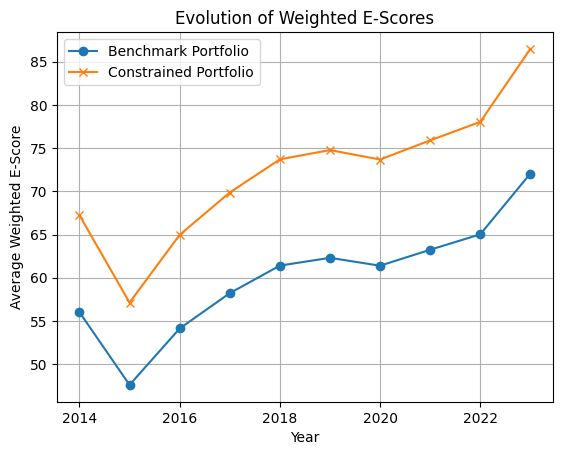

In [485]:
#PORTFOLIOS PERFORMANCE VISUALISATION

# Plot the data
plt.plot(final_df['Year'], final_df['weighted_E_score'], label='Benchmark Portfolio', marker='o')
plt.plot(final_df['Year'], final_df['weighted_E_score_constrained'], label='Constrained Portfolio', marker='x')

# Customize the plot
plt.title('Evolution of Weighted E-Scores')
plt.xlabel('Year')
plt.ylabel('Average Weighted E-Score')
plt.legend()  # Show legend
plt.grid(True)  # Add gridlines (optional)

# Display the plot
plt.show()

In [486]:
#CUMULATIVE RETURNS FOR MIN VAR PORTFOLIO

# Créer des colonnes pour le mois et l'année dans long_filtered_EM_merged_DS_R_USD_M
long_filtered_EM_merged_DS_R_USD_M['Year'] = long_filtered_EM_merged_DS_R_USD_M['Date'].dt.year
long_filtered_EM_merged_DS_R_USD_M['Month'] = long_filtered_EM_merged_DS_R_USD_M['Date'].dt.month

# Fusionner les DataFrames sur ISIN, Year et Month
cumulative_R_minvar = pd.merge(portfolio_final_E, long_filtered_EM_merged_DS_R_USD_M, on=['ISIN', 'Year', 'Month'], how='left')

# Calculer les rendements pondérés
cumulative_R_minvar['weighted_returns'] = cumulative_R_minvar['weight'] * cumulative_R_minvar['Returns']

# Afficher le DataFrame résultant
cumulative_R_minvar

,ISIN,Date_x,E_Score,weight,weighted_E_score,Year,Month,Date_y,Returns,weighted_returns
0,BRABEVACNOR1,2014-01-01,58.81,4.218486e-18,2.480892e-16,2014,1,2014-01-31,-0.081488,-3.437570e-19
1,BRBBASACNOR3,2014-01-01,90.21,0.000000e+00,0.000000e+00,2014,1,2014-01-31,-0.165964,-0.000000e+00
2,BRBBDCACNPR8,2014-01-01,83.16,6.031143e-18,5.015498e-16,2014,1,2014-01-31,-0.121563,-7.331621e-19
3,BRBRFSACNOR8,2014-01-01,78.70,0.000000e+00,0.000000e+00,2014,1,2014-01-31,-0.137319,-0.000000e+00
4,BRBRKMACNPA4,2014-01-01,41.05,5.379897e-18,2.208448e-16,2014,1,2014-01-31,-0.138089,-7.429043e-19
...,...,...,...,...,...,...,...,...,...,...
5095,ZAE000191342,2023-01-01,37.06,1.706965e-18,6.326013e-17,2023,1,2023-01-31,-0.078724,-1.343789e-19
5096,ZAE000255915,2023-01-01,84.75,7.741300e-20,6.560751e-18,2023,1,2023-01-31,0.001249,9.670485e-23
5097,ZAE000298253,2023-01-01,63.96,0.000000e+00,0.000000e+00,2023,1,2023-01-31,-0.109795,-0.000000e+00
5098,ZAE000302618,2023-01-01,25.61,0.000000e+00,0.000000e+00,2023,1,2023-01-31,-0.071429,-0.000000e+00


In [487]:
#CUMULATIVE RETURNS FOR 20%PORTFOLIO

# Créer des colonnes pour le mois et l'année dans portfolio_final_E_constrained_all_years
portfolio_final_E_constrained_all_years['Year'] = portfolio_final_E_constrained_all_years['Date'].dt.year
portfolio_final_E_constrained_all_years['Month'] = portfolio_final_E_constrained_all_years['Date'].dt.month

# Fusionner les DataFrames sur ISIN, Year et Month
cumulative_R_20 = pd.merge(portfolio_final_E_constrained_all_years, long_filtered_EM_merged_DS_R_USD_M, on=['Year', 'Month'], how='left') #Attention: pas ISIN ici

# Reset index to bring 'ISIN' back as a regular column (if needed):
cumulative_R_20 = cumulative_R_20.reset_index()

# Calculer les rendements pondérés (cette partie peut nécessiter des ajustements en fonction de la colonne contenant les poids)
cumulative_R_20['weighted_returns'] = cumulative_R_20['weight'] * cumulative_R_20['Returns']

# Afficher le DataFrame résultant
cumulative_R_20

,index,ISIN_x,Date_x,E_Score,weight,weighted_E_score,Year,Month,ISIN_y,Date_y,Returns,weighted_returns
0,0,BRABEVACNOR1,2014-01-01,58.81,0.0,0.0,2014,1,BRABEVACNOR1,2014-01-31,-0.081488,-0.0
1,1,BRABEVACNOR1,2014-01-01,58.81,0.0,0.0,2014,1,BRBBASACNOR3,2014-01-31,-0.165964,-0.0
2,2,BRABEVACNOR1,2014-01-01,58.81,0.0,0.0,2014,1,BRBBDCACNPR8,2014-01-31,-0.121563,-0.0
3,3,BRABEVACNOR1,2014-01-01,58.81,0.0,0.0,2014,1,BRBRFSACNOR8,2014-01-31,-0.137319,-0.0
4,4,BRABEVACNOR1,2014-01-01,58.81,0.0,0.0,2014,1,BRBRKMACNPA4,2014-01-31,-0.138089,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2600995,2600995,ZAE000322095,2023-01-01,28.72,0.0,0.0,2023,1,ZAE000191342,2023-01-31,-0.078724,-0.0
2600996,2600996,ZAE000322095,2023-01-01,28.72,0.0,0.0,2023,1,ZAE000255915,2023-01-31,0.001249,0.0
2600997,2600997,ZAE000322095,2023-01-01,28.72,0.0,0.0,2023,1,ZAE000298253,2023-01-31,-0.109795,-0.0
2600998,2600998,ZAE000322095,2023-01-01,28.72,0.0,0.0,2023,1,ZAE000302618,2023-01-31,-0.071429,-0.0


In [488]:
#PLOTTING CUMULATIVE RETURNS

minvar_annual_returns = {}  # Annual returns for cumulative_R_minvar (benchmark)
constrained_annual_returns = {}  # Annual returns for cumulative_R_20 (optimized)

for year in range(2014, 2024):  # Iterate through the years
    # Get returns for the current year
    minvar_returns_year = cumulative_R_minvar[cumulative_R_minvar['Year'] == year]['weighted_returns']
    constrained_returns_year = cumulative_R_20[cumulative_R_20['Year'] == year]['weighted_returns']

    # Calculate and store annual returns
    minvar_annual_returns[year] = minvar_returns_year.mean()*12 # Additive version
    constrained_annual_returns[year] = constrained_returns_year.mean()*12  # Additive version
    # Or, for compounded version:
    #minvar_annual_returns[year] = (minvar_returns_year + 1).prod() - 1
    #constrained_annual_returns[year] = (constrained_returns_year + 1).prod() - 1

# Create a DataFrame for plotting or further analysis:
annual_returns_df = pd.DataFrame({
    'Year': list(minvar_annual_returns.keys()),
    'Min Var Annual Returns': list(minvar_annual_returns.values()),
    'Constrained Annual Returns': list(constrained_annual_returns.values())
})

# Display the annual returns:
print(annual_returns_df)

   Year  Min Var Annual Returns  Constrained Annual Returns
0  2014               -0.000819                   -0.001231
1  2015                0.000536                    0.000188
2  2016               -0.000746                   -0.001123
3  2017                0.000402                    0.001593
4  2018                0.000765                    0.001807
5  2019                0.001430                    0.001719
6  2020               -0.000926                   -0.001427
7  2021               -0.000983                   -0.000375
8  2022               -0.000171                   -0.000008
9  2023                0.000485                    0.001330


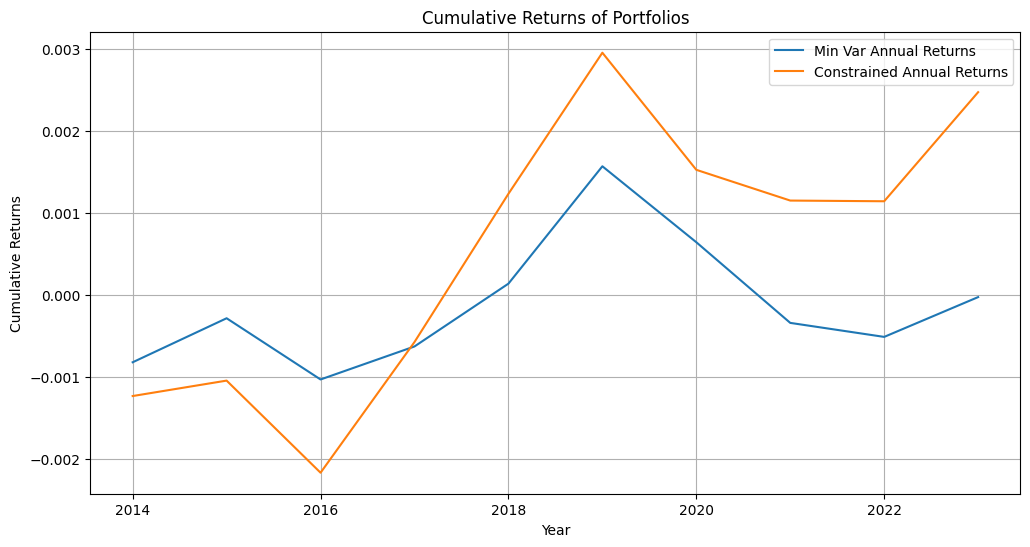

In [489]:
# prompt: for annual_returns_df make cummulative returns line graph for each column

import matplotlib.pyplot as plt
# Assuming annual_returns_df is already created as shown in the provided code
plt.figure(figsize=(12, 6))

for column in annual_returns_df.columns:
    if column != 'Year':
        plt.plot(annual_returns_df['Year'], annual_returns_df[column].cumsum(), label=column)

plt.title('Cumulative Returns of Portfolios')
plt.xlabel('Year')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()


# **Question 4**

### Value-Weighted Tracking Error

In [490]:
# === Replace with your actual DataFrames ===
market_cap_df = market_cap_Y_2009_2024
EScore_df = EScore_Y_2009_2024_D
returns_df = simple_returns_M_2009_2024_D

market_cap_df.columns = pd.to_datetime(market_cap_df.columns).year.astype(str)
EScore_df.columns = pd.to_datetime(EScore_df.columns).year.astype(str)

returns_df.columns = pd.to_datetime(returns_df.columns)

# === Store results ===
optimized_weights_by_year = {}
benchmark_scores = {}
optimized_scores = {}

# === Loop through years ===
for year in range(2013, 2024):
    print(f"Processing year: {year}")

    try:
        # --- Extract benchmark inputs ---
        market_caps = market_cap_df[str(year)]
        ESG_scores = EScore_df[str(year)]

        # Drop missing firms
        valid_firms = market_caps.dropna().index.intersection(ESG_scores.dropna().index)
        market_caps = market_caps.loc[valid_firms]
        ESG_scores = ESG_scores.loc[valid_firms]

        alpha_vw = market_caps / market_caps.sum()  # benchmark weights
        Sc_vw = np.dot(alpha_vw, ESG_scores)        # benchmark ESG score

        # --- Covariance matrix  ---

        #mask = returns_df.columns.to_series().dt.year == year + 0
        mask = returns_df.columns.to_series().dt.year.isin([year -4, year -3, year -2, year-1, year])
        returns_year = returns_df.loc[valid_firms, mask]

        Sigma = returns_year.T.cov().values  # Covariance matrix

        n_assets = len(alpha_vw)

        # --- Optimization setup ---
        def tracking_error_variance(alpha, alpha_vw, Sigma):
            diff = alpha - alpha_vw
            return diff.T @ Sigma @ diff

        constraint_sum = {'type': 'eq', 'fun': lambda alpha: np.sum(alpha) - 1}
        constraint_esg = {
            'type': 'ineq',
            'fun': lambda alpha: np.dot(alpha, ESG_scores.values) - 1.2 * Sc_vw
        }
        bounds = [(0, 1) for _ in range(n_assets)]
        constraints = [constraint_sum, constraint_esg]

        x0 = alpha_vw.values

        # --- Run optimizer ---
        result = minimize(
            tracking_error_variance,
            x0=x0,
            args=(alpha_vw.values, Sigma),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        if result.success:
            optimized_weights = pd.Series(result.x, index=valid_firms)
            optimized_weights_by_year[year] = optimized_weights

            # Store ESG scores
            benchmark_scores[year] = Sc_vw
            optimized_scores[year] = np.dot(result.x, ESG_scores.values)

        else:
            print(f"Optimization failed for year {year}: {result.message}")

    except Exception as e:
        print(f"Error in year {year}: {e}")

Processing year: 2013
Processing year: 2014
Processing year: 2015
Processing year: 2016
Processing year: 2017
Processing year: 2018
Processing year: 2019
Processing year: 2020
Processing year: 2021
Processing year: 2022
Processing year: 2023


In [491]:
# Combine optimized weights into one DataFrame
optimized_weights_df = pd.DataFrame(optimized_weights_by_year)

# ESG scores comparison
score_comparison = pd.DataFrame({
    'benchmark_ESG': benchmark_scores,
    'optimized_ESG': optimized_scores
})

In [492]:
score_comparison

,benchmark_ESG,optimized_ESG
2013,55.446702,66.536042
2014,56.292505,67.551006
2015,59.787546,71.745055
2016,62.909965,75.491958
2017,66.561943,79.874332
2018,68.474026,82.168831
2019,69.155723,82.986867
2020,69.177359,83.012831
2021,70.376230,84.451476
2022,72.783358,87.340029


In [493]:
optimized_annual_returns = {}
benchmark_annual_returns = {}
optimized_annual_returns_comp = {}
benchmark_annual_returns_comp = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    # Get market-cap weights for benchmark
    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    # Returns for the NEXT year
    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    # === Matrix multiplication: weights.T @ monthly returns ===
    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # === Total annual return (additive or compounded) ===



    # Additive version:
    optimized_annual_returns[next_year] = monthly_returns_opt.mean()*12
    benchmark_annual_returns[next_year] = monthly_returns_benchmark.mean()*12

    optimized_annual_returns

    # # Or Compounded version (optional)
    optimized_annual_returns_comp[next_year] = (monthly_returns_opt + 1).prod() - 1
    benchmark_annual_returns_comp[next_year] = (monthly_returns_benchmark + 1).prod() - 1

In [494]:
# Convert dict values to a list or array
opt_returns = np.array(list(optimized_annual_returns_comp.values()))
bench_returns = np.array(list(benchmark_annual_returns_comp.values()))

# Compound returns across the years
optimized_total_return = np.prod(opt_returns + 1) - 1
benchmark_total_return = np.prod(bench_returns + 1) - 1

print("Total compounded return (optimized):", optimized_total_return)
print("Total compounded return (benchmark):", benchmark_total_return)

Total compounded return (optimized): 1.2305201882318841
Total compounded return (benchmark): 1.0269711604868705


In [495]:
opt_returns

array([ 0.05368382, -0.16412143,  0.17433194,  0.35004   , -0.06832356,
        0.13819684,  0.11075064,  0.13773048, -0.05355629,  0.20389032,
        0.04615246])

In [496]:
bench_returns

array([ 0.05506204, -0.16638988,  0.14520189,  0.33585154, -0.08333978,
        0.14605917,  0.09405549,  0.1138246 , -0.07407826,  0.20137869,
        0.0578901 ])

In [497]:
optimized_monthly_returns = {}
benchmark_monthly_returns = {}

# Convert specific columns to datetime
date_columns = returns_df.columns[1:]  # Assuming the first column is not a date
returns_df[date_columns] = returns_df[date_columns].apply(pd.to_datetime, errors='coerce')


# Ensure returns_df has datetime columns
datetime_columns = returns_df.select_dtypes(include=['datetime']).columns

if datetime_columns.empty:
    raise ValueError("returns_df does not have any datetime columns.")

for year in range(returns_df[datetime_columns].columns.to_series().dt.year.min(), returns_df[datetime_columns].columns.to_series().dt.year.max() + 1):  # Iterate through years
    weights_opt = optimized_weights_by_year.get(year)  # Safely get weights for the year

    if weights_opt is None:
        continue  # Skip if no weights for the year

    firms = weights_opt.index

    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # Store monthly returns instead of annual
    optimized_monthly_returns[next_year] = monthly_returns_opt
    benchmark_monthly_returns[next_year] = monthly_returns_benchmark

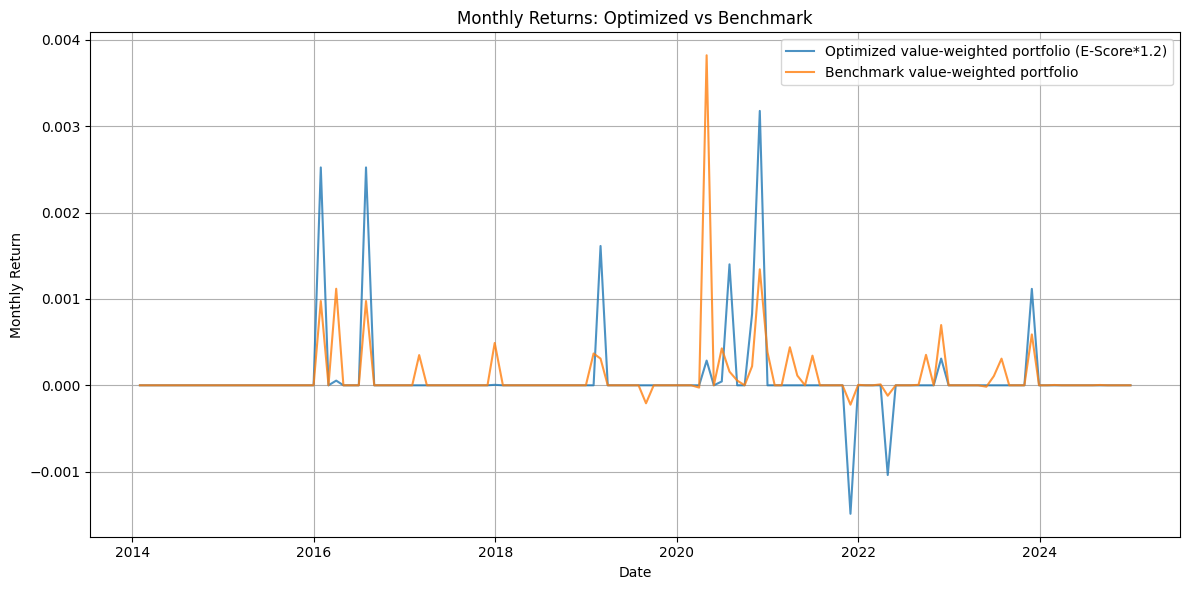

In [498]:
# Convert optimized_monthly_returns and benchmark_monthly_returns into Series
opt_returns_series = pd.concat(optimized_monthly_returns.values(), axis=0)
bench_returns_series = pd.concat(benchmark_monthly_returns.values(), axis=0)

plt.figure(figsize=(12, 6))
plt.plot(opt_returns_series, label='Optimized value-weighted portfolio (E-Score*1.2)', alpha=0.8)
plt.plot(bench_returns_series, label='Benchmark value-weighted portfolio', alpha=0.8)
plt.title('Monthly Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Monthly Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [499]:
opt_returns_series

,0
2014-01-31,0.0
2014-02-28,0.0
2014-03-31,0.0
2014-04-30,0.0
2014-05-30,0.0
...,...
2024-08-30,0.0
2024-09-30,0.0
2024-10-31,0.0
2024-11-29,0.0


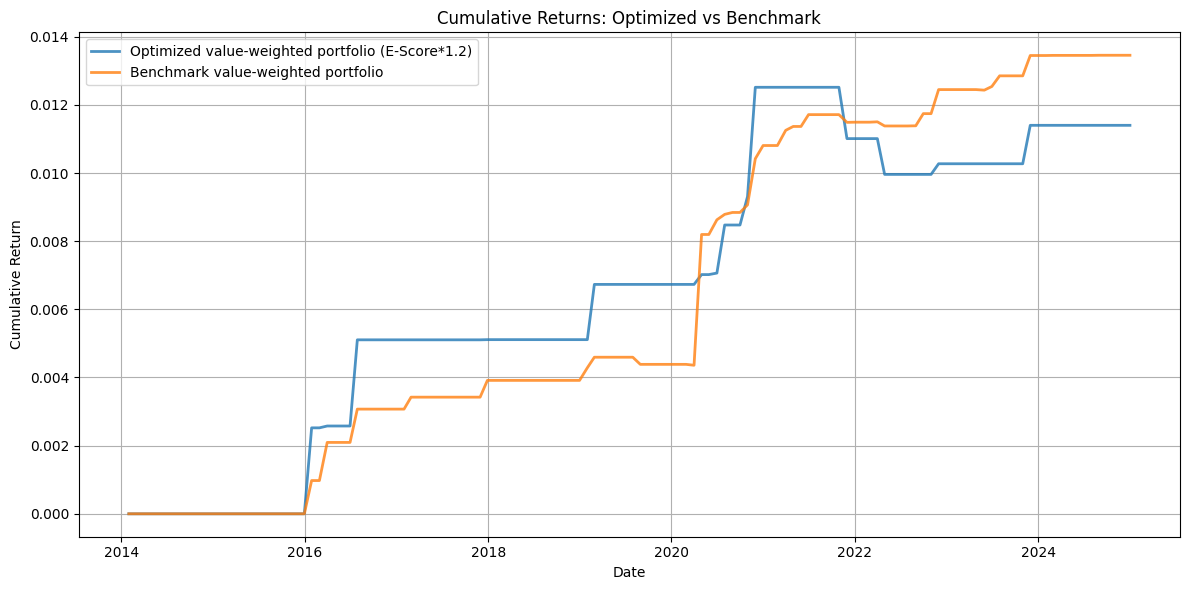

In [500]:
cumulative_opt = (1 + opt_returns_series).cumprod() -1
cumulative_bench = (1 + bench_returns_series).cumprod() -1

plt.figure(figsize=(12, 6))
plt.plot(cumulative_opt, label='Optimized value-weighted portfolio (E-Score*1.2)', alpha=0.8, linewidth =2)
plt.plot(cumulative_bench, label='Benchmark value-weighted portfolio', alpha=0.8, linewidth =2)
plt.title('Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

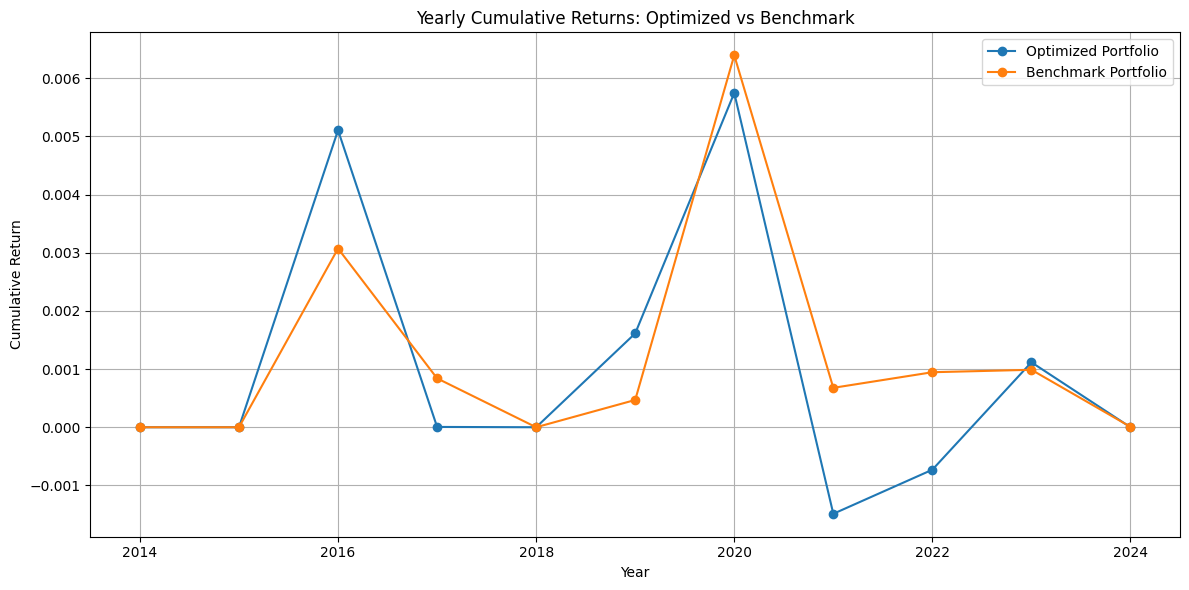

In [501]:
# Convert to yearly cumulative returns
yearly_opt = (1 + opt_returns_series).groupby(opt_returns_series.index.year).prod() - 1
yearly_bench = (1 + bench_returns_series).groupby(bench_returns_series.index.year).prod() - 1

# Plot
plt.figure(figsize=(12, 6))
plt.plot(yearly_opt, label='Optimized Portfolio', marker='o')
plt.plot(yearly_bench, label='Benchmark Portfolio', marker='o')
plt.title('Yearly Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Year')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [502]:
# prompt: can you find the companies with contribute the most to this weights_opt, and find their names via the ISIN in the df returns

# Assuming optimized_weights_by_year is a dictionary with year as keys and pd.Series as values
# where the series contains the weights of each company in that year, indexed by ISIN.
# We also assume returns has an ISIN column with the company ISIN.

# Example: Get the most important company in 2023
year_to_check = 2023
if year_to_check in optimized_weights_by_year:
  weights_opt = optimized_weights_by_year[year_to_check]
  most_important_isin = weights_opt.idxmax()

  # Find company name using the ISIN
  company_name = returns[returns['ISIN'] == most_important_isin]['Name'].values

  if len(company_name) > 0:
    print(f"In {year_to_check}, the company with the highest contribution to the portfolio is: {company_name[0]} (ISIN: {most_important_isin})")
  else:
    print(f"ISIN {most_important_isin} not found in the returns dataframe")
else:
  print(f"No optimized weights found for the year {year_to_check}.")


# To find the top N companies with the highest contributions, you can use nlargest()
def find_top_n_companies(year, n=5):
  if year in optimized_weights_by_year:
    weights_opt = optimized_weights_by_year[year]
    top_n_isins = weights_opt.nlargest(n).index.tolist()

    for isin in top_n_isins:
      company_name = returns[returns['ISIN'] == isin]['Name'].values
      if len(company_name) > 0:
        print(f"In {year}, {company_name[0]} (ISIN: {isin}) has a weight of {weights_opt[isin]}")
      else:
        print(f"ISIN {isin} not found in the returns dataframe")
  else:
    print(f"No optimized weights found for the year {year}.")


# Example: Find the top 3 companies in 2023
find_top_n_companies(2020, n=10)

In 2023, the company with the highest contribution to the portfolio is: TAIWAN SEMICON.MNFG. (ISIN: TW0002330008)
In 2020, TAIWAN SEMICON.MNFG. (ISIN: TW0002330008) has a weight of 0.052418043967445274
In 2020, SAMSUNG ELECTRONICS (ISIN: KR7005930003) has a weight of 0.043703816862688656
In 2020, CHINA CON.BANK 'H' (ISIN: CNE1000002H1) has a weight of 0.038986943061609707
In 2020, CHINA MOBILE (ISIN: HK0941009539) has a weight of 0.023071262412775677
In 2020, TATA CONSULTANCY SVS. (ISIN: INE467B01029) has a weight of 0.021231529003806836
In 2020, CHINA VANKE 'A' (ISIN: CNE0000000T2) has a weight of 0.01664165956599623
In 2020, CHINA MERCHANTS BANK 'A' (ISIN: CNE000001B33) has a weight of 0.015909932870710432
In 2020, HDFC BANK (ISIN: INE040A01034) has a weight of 0.01587386013314172
In 2020, PING AN INSURANCE (GROUP) OF CHINA 'H' (ISIN: CNE1000003X6) has a weight of 0.015302925751908319
In 2020, WALMART DE MEXICO 'V' (ISIN: MX01WA000038) has a weight of 0.01530188649599061


In [503]:
df = pd.DataFrame({'opt_returns_series': opt_returns_series, 'benchmark_return_series': bench_returns_series})
df

,opt_returns_series,benchmark_return_series
2014-01-31,0.0,0.0
2014-02-28,0.0,0.0
2014-03-31,0.0,0.0
2014-04-30,0.0,0.0
2014-05-30,0.0,0.0
...,...,...
2024-08-30,0.0,0.000004
2024-09-30,0.0,0.0
2024-10-31,0.0,0.0
2024-11-29,0.0,0.0


In [504]:
risk_free_rate

,date,RF
0,2000-01-31,0.0041
1,2000-02-29,0.0043
2,2000-03-31,0.0047
3,2000-04-30,0.0046
4,2000-05-31,0.0050
...,...,...
295,2024-08-31,0.0048
296,2024-09-30,0.0040
297,2024-10-31,0.0039
298,2024-11-30,0.0040


In [505]:
returns_df = df.copy()

#num_assets_per_month = simple_returns_M_2014_2024_prev.count(axis=0) # count total number of companies (N) in the previous month

#total_market_cap_df = total_market_cap_per_month.reset_index()
#total_market_cap_df.columns = ['date', 'market_cap_total_prev_month']

#returns_df = pd.merge(returns_df, total_market_cap_df, on='date', how='left')

# Number of assets based on market cap
#num_assets_per_month_df = num_assets_per_month.reset_index()
#num_assets_per_month_df.columns = ['date', 'num_assets_per_month']

#returns_df = pd.merge(returns_df, num_assets_per_month_df, on='date', how='left')

# Number of assets based on return data
#num_assets_per_month_return_data = simple_returns_M_2014_2024.count(axis=0)

#num_assets_per_month_return_data_df = num_assets_per_month_return_data.reset_index()
#num_assets_per_month_return_data_df.columns = ['date', 'num_assets_per_month_return_data']

#returns_df = pd.merge(returns_df, num_assets_per_month_return_data_df, on='date', how='left')

# Add risk free rate to df
returns_df['year_month'] = returns_df.index.to_period('M').astype(str)

risk_free_rate['year_month'] = risk_free_rate['date'].dt.to_period('M').astype(str)

returns_df = pd.merge(returns_df, risk_free_rate[['year_month', 'RF']], on='year_month', how='left')

# Adding squared difference to df
ew_return_average = returns_df['opt_returns_series'].mean()
vw_return_average = returns_df['benchmark_return_series'].mean()

if 'ew_squared_difference_ew'not in returns_df.columns:
  returns_df['ew_squared_difference'] = ((returns_df['opt_returns_series'] - ew_return_average) ** 2)
if 'vw_squared_difference_vw'not in returns_df.columns:
  returns_df['vw_squared_difference'] = ((returns_df['benchmark_return_series'] - vw_return_average) ** 2)

# Adding cumulative returns to df
if 'ew_cumulative_returns'not in returns_df.columns:
  returns_df['ew_cumulative_returns'] = ((1 + returns_df['opt_returns_series']).cumprod() - 1)
if 'vw_cumulative_returns'not in returns_df.columns:
  returns_df['vw_cumulative_returns'] = ((1 + returns_df['benchmark_return_series']).cumprod() - 1)

if 'rf_cumulative_returns'not in returns_df.columns:
  returns_df['rf_cumulative_returns'] = ((1 + returns_df['RF']).cumprod() - 1)


returns_df

,opt_returns_series,benchmark_return_series,year_month,RF,ew_squared_difference,vw_squared_difference,ew_cumulative_returns,vw_cumulative_returns,rf_cumulative_returns
0,0.0,0.0,2014-01,0.0000,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,2014-02,0.0000,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,2014-03,0.0000,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,2014-04,0.0000,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,2014-05,0.0000,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...
127,0.0,0.000004,2024-08,0.0048,0.0,0.0,0.0114,0.013456,0.164355
128,0.0,0.0,2024-09,0.0040,0.0,0.0,0.0114,0.013456,0.169012
129,0.0,0.0,2024-10,0.0039,0.0,0.0,0.0114,0.013456,0.173571
130,0.0,0.0,2024-11,0.0040,0.0,0.0,0.0114,0.013456,0.178265


In [506]:
total_return = (1 + returns_df['opt_returns_series']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
ew_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the opt_returns_series: {ew_annualized_return:.6f}")

Annualized return of the opt_returns_series: 0.001031


In [507]:
total_return = (1 + returns_df['benchmark_return_series']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
vw_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the benchmark_return_series: {vw_annualized_return:.6f}")

Annualized return of the benchmark_return_series: 0.001216


In [508]:
min_ew_return = returns_df['opt_returns_series'].min()
print(f"Minimum retrun in the equally weighted portfolio: {min_ew_return}")

Minimum retrun in the equally weighted portfolio: -0.0014876324006918625


In [509]:
min_vw_return = returns_df['benchmark_return_series'].min()
print(f"Minimum retrun in the value weighted portfolio: {min_vw_return}")

Minimum retrun in the value weighted portfolio: -0.0002243396624198407


In [510]:
max_ew_return = returns_df['opt_returns_series'].max()
print(f"Maximum retrun in the equally weighted portfolio: {max_ew_return}")

Maximum retrun in the equally weighted portfolio: 0.0031764304685648185


In [511]:
max_vw_return = returns_df['benchmark_return_series'].max()
print(f"Maximum retrun in the value weighted portfolio: {max_vw_return}")

Maximum retrun in the value weighted portfolio: 0.0038208413119254804


In [512]:
# Compute sample variance (N-1 for unbiased estimator)
ew_variance = returns_df['ew_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
ew_volatility = np.sqrt(ew_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
ew_volatility_annualized = ew_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the equally-weighted portfolio: {ew_volatility_annualized}")

Annualized volatility of the equally-weighted portfolio: 0.0017004747939899502


In [513]:
# Compute sample variance (N-1 for unbiased estimator)
vw_variance = returns_df['vw_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
vw_volatility = np.sqrt(vw_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
vw_volatility_annualized = vw_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the value-weighted portfolio: {vw_volatility_annualized}")

Annualized volatility of the value-weighted portfolio: 0.001371700543875529


In [514]:
df = returns_df

df['ew_excess_return'] = df['opt_returns_series'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['ew_excess_return'].mean()
std_excess_return = df['ew_excess_return'].std()

ew_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {ew_sharpe_ratio:.4f}")

Sharpe Ratio: -0.7206


In [515]:
ew_annualized_sharpe_ratio = ew_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {ew_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: -2.4963


In [516]:
df = returns_df

df['vw_excess_return'] = df['benchmark_return_series'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['vw_excess_return'].mean()
std_excess_return = df['vw_excess_return'].std()

vw_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {vw_sharpe_ratio:.4f}")

Sharpe Ratio: -0.7162


In [517]:
vw_annualized_sharpe_ratio = vw_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {vw_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: -2.4811


In [518]:
data = {
    'Portfolio': ['Optimized value-weighted portfolio', 'Benchmark value-weighted portfolio'],
    'Annualized Return': [ew_annualized_return, vw_annualized_return],  # Replace with actual values
    'Minimum Return': [min_ew_return, min_vw_return],
    'Maximum Return': [max_ew_return, max_vw_return],
    'Annualized Volatility': [ew_volatility_annualized, vw_volatility_annualized],
    'Annualized Sharpe Ratio': [ew_annualized_sharpe_ratio, vw_annualized_sharpe_ratio]
}

df = pd.DataFrame(data)
summary_df = df

summary_df

,Portfolio,Annualized Return,Minimum Return,Maximum Return,Annualized Volatility,Annualized Sharpe Ratio
0,Optimized value-weighted portfolio,0.001031,-0.001488,0.003176,0.001700,-2.496298
1,Benchmark value-weighted portfolio,0.001216,-0.000224,0.003821,0.001372,-2.481122


### Equally-Weighted Portfolio

In [520]:
# === Replace with your actual DataFrames ===
market_cap_df = market_cap_Y_2009_2024
EScore_df = EScore_Y_2009_2024_D
returns_df = simple_returns_M_2009_2024_D

market_cap_df.columns = pd.to_datetime(market_cap_df.columns).year.astype(str)
EScore_df.columns = pd.to_datetime(EScore_df.columns).year.astype(str)

returns_df.columns = pd.to_datetime(returns_df.columns)

# === Store results ===
optimized_weights_by_year = {}
benchmark_scores = {}
optimized_scores = {}

# === Loop through years ===
for year in range(2013, 2024):
    print(f"Processing year: {year}")

    try:
        # --- Extract benchmark inputs ---
        market_caps = market_cap_df[str(year)]
        ESG_scores = EScore_df[str(year)]

        # Drop missing firms
        valid_firms = market_caps.dropna().index.intersection(ESG_scores.dropna().index)
        market_caps = market_caps.loc[valid_firms]
        ESG_scores = ESG_scores.loc[valid_firms]

        n_assets = market_caps.count()
        alpha_vw = pd.Series(1 / n_assets, index=market_caps.index)  # Equal weight

        Sc_vw = np.dot(alpha_vw, ESG_scores)        # benchmark ESG score

        # --- Covariance matrix  ---

        #mask = returns_df.columns.to_series().dt.year == year + 0
        mask = returns_df.columns.to_series().dt.year.isin([year -4, year -3, year -2, year-1, year])
        returns_year = returns_df.loc[valid_firms, mask]

        Sigma = returns_year.T.cov().values  # Covariance matrix

        n_assets = len(alpha_vw)

        # --- Optimization setup ---
        def tracking_error_variance(alpha, alpha_vw, Sigma):
            diff = alpha - alpha_vw
            return diff.T @ Sigma @ diff

        constraint_sum = {'type': 'eq', 'fun': lambda alpha: np.sum(alpha) - 1}
        constraint_esg = {
            'type': 'ineq',
            'fun': lambda alpha: np.dot(alpha, ESG_scores.values) - 1.2 * Sc_vw
        }
        bounds = [(0, 1) for _ in range(n_assets)]
        constraints = [constraint_sum, constraint_esg]

        x0 = alpha_vw.values

        # --- Run optimizer ---
        result = minimize(
            tracking_error_variance,
            x0=x0,
            args=(alpha_vw.values, Sigma),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        if result.success:
            optimized_weights = pd.Series(result.x, index=valid_firms)
            optimized_weights_by_year[year] = optimized_weights

            # Store ESG scores
            benchmark_scores[year] = Sc_vw
            optimized_scores[year] = np.dot(result.x, ESG_scores.values)

        else:
            print(f"Optimization failed for year {year}: {result.message}")

    except Exception as e:
        print(f"Error in year {year}: {e}")

Processing year: 2013
Error in year 2013: float() argument must be a string or a real number, not 'Timestamp'
Processing year: 2014
Processing year: 2015
Processing year: 2016
Processing year: 2017
Processing year: 2018
Processing year: 2019
Processing year: 2020
Processing year: 2021
Processing year: 2022
Processing year: 2023


In [521]:
# Combine optimized weights into one DataFrame
optimized_weights_df = pd.DataFrame(optimized_weights_by_year)

# ESG scores comparison
score_comparison = pd.DataFrame({
    'benchmark_ESG': benchmark_scores,
    'optimized_ESG': optimized_scores
})

In [522]:
score_comparison

,benchmark_ESG,optimized_ESG
2014,45.561788,54.674145
2015,49.777623,59.733147
2016,53.716582,64.459898
2017,57.234165,68.680998
2018,59.569057,71.482868
2019,62.234676,74.681611
2020,64.620668,77.544802
2021,66.377937,79.653525
2022,68.403477,82.084173
2023,68.680079,82.416094


In [523]:
optimized_annual_returns = {}
benchmark_annual_returns = {}
optimized_annual_returns_comp = {}
benchmark_annual_returns_comp = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    # Get market-cap weights for benchmark
    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    # Returns for the NEXT year
    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    # === Matrix multiplication: weights.T @ monthly returns ===
    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # === Total annual return (additive or compounded) ===



    # Additive version:
    optimized_annual_returns[next_year] = monthly_returns_opt.mean()*12
    benchmark_annual_returns[next_year] = monthly_returns_benchmark.mean()*12

    optimized_annual_returns

    # # Or Compounded version (optional)
    optimized_annual_returns_comp[next_year] = (monthly_returns_opt + 1).prod() - 1
    benchmark_annual_returns_comp[next_year] = (monthly_returns_benchmark + 1).prod() - 1

In [524]:
import numpy as np

# Convert dict values to a list or array
opt_returns = np.array(list(optimized_annual_returns_comp.values()))
bench_returns = np.array(list(benchmark_annual_returns_comp.values()))

# Compound returns across the years
optimized_total_return = np.prod(opt_returns + 1) - 1
benchmark_total_return = np.prod(bench_returns + 1) - 1

print("Total compounded return (optimized):", optimized_total_return)
print("Total compounded return (benchmark):", benchmark_total_return)

Total compounded return (optimized): 0.05052140196221244
Total compounded return (benchmark): 0.013456155913985857


In [525]:
opt_returns

array([0.        , 0.0126601 , 0.00343203, 0.        , 0.0026525 ,
       0.02081286, 0.00111803, 0.00357017, 0.00536473, 0.        ])

In [526]:
bench_returns

array([0.00000000e+00, 3.07192214e-03, 8.40369797e-04, 0.00000000e+00,
       4.68810160e-04, 6.39384142e-03, 6.77495276e-04, 9.45728186e-04,
       9.87695042e-04, 7.25304055e-06])

In [527]:
optimized_monthly_returns = {}
benchmark_monthly_returns = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # Store monthly returns instead of annual
    optimized_monthly_returns[next_year] = monthly_returns_opt
    benchmark_monthly_returns[next_year] = monthly_returns_benchmark


In [528]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all monthly returns into one time series
opt_returns_series = pd.concat(optimized_monthly_returns.values())
bench_returns_series = pd.concat(benchmark_monthly_returns.values())

# Align the index (make sure it uses datetime if it's not already)
opt_returns_series.index = pd.to_datetime(opt_returns_series.index)
bench_returns_series.index = pd.to_datetime(bench_returns_series.index)


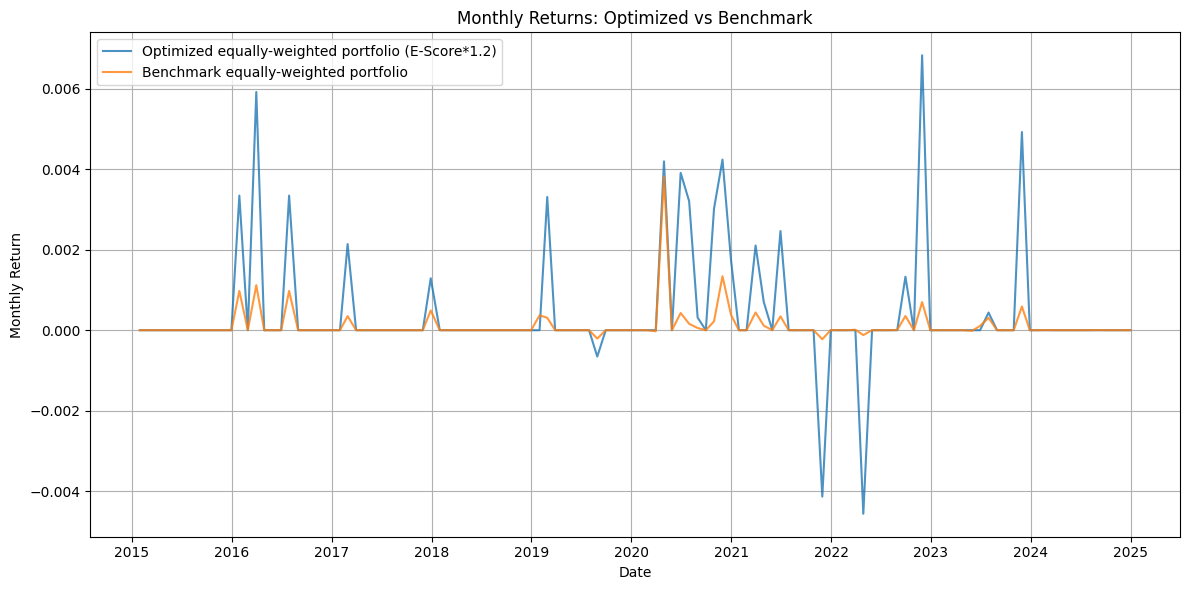

In [529]:
plt.figure(figsize=(12, 6))
plt.plot(opt_returns_series, label='Optimized equally-weighted portfolio (E-Score*1.2)', alpha=0.8)
plt.plot(bench_returns_series, label='Benchmark equally-weighted portfolio', alpha=0.8)
plt.title('Monthly Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Monthly Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [530]:
opt_returns_series

,0
2015-01-30,0.0
2015-02-27,0.0
2015-03-31,0.0
2015-04-30,0.0
2015-05-29,0.0
...,...
2024-08-30,0.0
2024-09-30,0.0
2024-10-31,0.0
2024-11-29,0.0


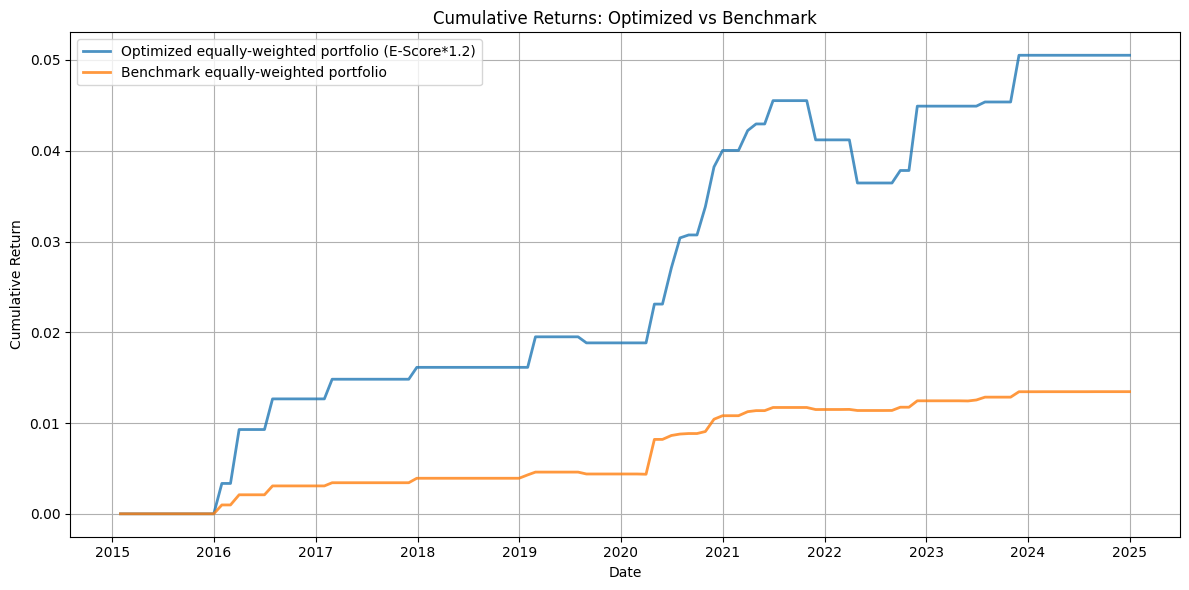

In [531]:
cumulative_opt = (1 + opt_returns_series).cumprod() -1
cumulative_bench = (1 + bench_returns_series).cumprod() -1

plt.figure(figsize=(12, 6))
plt.plot(cumulative_opt, label='Optimized equally-weighted portfolio (E-Score*1.2)', alpha=0.8, linewidth =2)
plt.plot(cumulative_bench, label='Benchmark equally-weighted portfolio', alpha=0.8, linewidth =2)
plt.title('Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


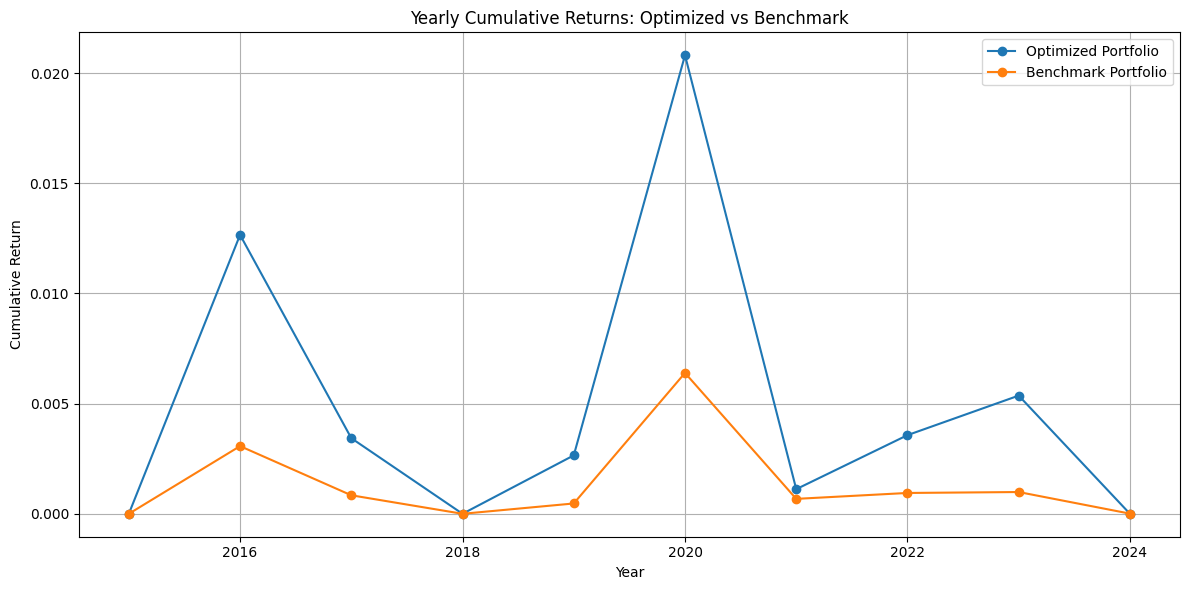

In [532]:
# Convert to yearly cumulative returns
yearly_opt = (1 + opt_returns_series).groupby(opt_returns_series.index.year).prod() - 1
yearly_bench = (1 + bench_returns_series).groupby(bench_returns_series.index.year).prod() - 1

# Plot
plt.figure(figsize=(12, 6))
plt.plot(yearly_opt, label='Optimized Portfolio', marker='o')
plt.plot(yearly_bench, label='Benchmark Portfolio', marker='o')
plt.title('Yearly Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Year')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [533]:
# prompt: can you find the companies with contribute the most to this weights_opt, and find their names via the ISIN in the df returns

# Assuming optimized_weights_by_year is a dictionary with year as keys and pd.Series as values
# where the series contains the weights of each company in that year, indexed by ISIN.
# We also assume returns has an ISIN column with the company ISIN.

# Example: Get the most important company in 2023
year_to_check = 2023
if year_to_check in optimized_weights_by_year:
  weights_opt = optimized_weights_by_year[year_to_check]
  most_important_isin = weights_opt.idxmax()

  # Find company name using the ISIN
  company_name = returns[returns['ISIN'] == most_important_isin]['Name'].values

  if len(company_name) > 0:
    print(f"In {year_to_check}, the company with the highest contribution to the portfolio is: {company_name[0]} (ISIN: {most_important_isin})")
  else:
    print(f"ISIN {most_important_isin} not found in the returns dataframe")
else:
  print(f"No optimized weights found for the year {year_to_check}.")


# To find the top N companies with the highest contributions, you can use nlargest()
def find_top_n_companies(year, n=5):
  if year in optimized_weights_by_year:
    weights_opt = optimized_weights_by_year[year]
    top_n_isins = weights_opt.nlargest(n).index.tolist()

    for isin in top_n_isins:
      company_name = returns[returns['ISIN'] == isin]['Name'].values
      if len(company_name) > 0:
        print(f"In {year}, {company_name[0]} (ISIN: {isin}) has a weight of {weights_opt[isin]}")
      else:
        print(f"ISIN {isin} not found in the returns dataframe")
  else:
    print(f"No optimized weights found for the year {year}.")


# Example: Find the top 3 companies in 2023
find_top_n_companies(2020, n=10)

In 2023, the company with the highest contribution to the portfolio is: BANCO BRADESCO PN (ISIN: BRBBDCACNPR8)
In 2020, TURKIYE IS BANKASI 'C' (ISIN: TRAISCTR91N2) has a weight of 0.00466095578179508
In 2020, NEDBANK GROUP (ISIN: ZAE000004875) has a weight of 0.004605912463824082
In 2020, TKI.GARANTI BKSI. (ISIN: TRAGARAN91N1) has a weight of 0.004604218783512769
In 2020, UNI-PRESIDENT ENTS. (ISIN: TW0001216000) has a weight of 0.004559337305132119
In 2020, ARCELIK (ISIN: TRAARCLK91H5) has a weight of 0.004554256344957392
In 2020, LARSEN & TOUBRO (ISIN: INE018A01030) has a weight of 0.004552562745405182
In 2020, HYUNDAI ENGR.& CON. (ISIN: KR7000720003) has a weight of 0.004498365467028814
In 2020, HACI OMER SABANCI HLDG. (ISIN: TRASAHOL91Q5) has a weight of 0.0044052159502059925
In 2020, TATUNG (ISIN: TW0002371002) has a weight of 0.004372189910967845
In 2020, MINOR INTERNATIONAL (ISIN: TH0128B10Z09) has a weight of 0.004369649471260036


In [534]:
df = pd.DataFrame({'opt_returns_series': opt_returns_series, 'benchmark_return_series': bench_returns_series})
df

,opt_returns_series,benchmark_return_series
2015-01-30,0.0,0.0
2015-02-27,0.0,0.0
2015-03-31,0.0,0.0
2015-04-30,0.0,0.0
2015-05-29,0.0,0.0
...,...,...
2024-08-30,0.0,0.000004
2024-09-30,0.0,0.0
2024-10-31,0.0,0.0
2024-11-29,0.0,0.0


In [535]:
risk_free_rate

,date,RF,year_month
0,2000-01-31,0.0041,2000-01
1,2000-02-29,0.0043,2000-02
2,2000-03-31,0.0047,2000-03
3,2000-04-30,0.0046,2000-04
4,2000-05-31,0.0050,2000-05
...,...,...,...
295,2024-08-31,0.0048,2024-08
296,2024-09-30,0.0040,2024-09
297,2024-10-31,0.0039,2024-10
298,2024-11-30,0.0040,2024-11


In [536]:
returns_df = df.copy()

#num_assets_per_month = simple_returns_M_2014_2024_prev.count(axis=0) # count total number of companies (N) in the previous month

#total_market_cap_df = total_market_cap_per_month.reset_index()
#total_market_cap_df.columns = ['date', 'market_cap_total_prev_month']

#returns_df = pd.merge(returns_df, total_market_cap_df, on='date', how='left')

# Number of assets based on market cap
#num_assets_per_month_df = num_assets_per_month.reset_index()
#num_assets_per_month_df.columns = ['date', 'num_assets_per_month']

#returns_df = pd.merge(returns_df, num_assets_per_month_df, on='date', how='left')

# Number of assets based on return data
#num_assets_per_month_return_data = simple_returns_M_2014_2024.count(axis=0)

#num_assets_per_month_return_data_df = num_assets_per_month_return_data.reset_index()
#num_assets_per_month_return_data_df.columns = ['date', 'num_assets_per_month_return_data']

#returns_df = pd.merge(returns_df, num_assets_per_month_return_data_df, on='date', how='left')

# Add risk free rate to df
returns_df['year_month'] = returns_df.index.to_period('M').astype(str)

risk_free_rate['year_month'] = risk_free_rate['date'].dt.to_period('M').astype(str)

returns_df = pd.merge(returns_df, risk_free_rate[['year_month', 'RF']], on='year_month', how='left')

# Adding squared difference to df
ew_return_average = returns_df['opt_returns_series'].mean()
vw_return_average = returns_df['benchmark_return_series'].mean()

if 'ew_squared_difference_ew'not in returns_df.columns:
  returns_df['ew_squared_difference'] = ((returns_df['opt_returns_series'] - ew_return_average) ** 2)
if 'vw_squared_difference_vw'not in returns_df.columns:
  returns_df['vw_squared_difference'] = ((returns_df['benchmark_return_series'] - vw_return_average) ** 2)

# Adding cumulative returns to df
if 'ew_cumulative_returns'not in returns_df.columns:
  returns_df['ew_cumulative_returns'] = ((1 + returns_df['opt_returns_series']).cumprod() - 1)
if 'vw_cumulative_returns'not in returns_df.columns:
  returns_df['vw_cumulative_returns'] = ((1 + returns_df['benchmark_return_series']).cumprod() - 1)

if 'rf_cumulative_returns'not in returns_df.columns:
  returns_df['rf_cumulative_returns'] = ((1 + returns_df['RF']).cumprod() - 1)


returns_df

,opt_returns_series,benchmark_return_series,year_month,RF,ew_squared_difference,vw_squared_difference,ew_cumulative_returns,vw_cumulative_returns,rf_cumulative_returns
0,0.0,0.0,2015-01,0.0000,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,2015-02,0.0000,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,2015-03,0.0000,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,2015-04,0.0000,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,2015-05,0.0000,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...
115,0.0,0.000004,2024-08,0.0048,0.0,0.0,0.050521,0.013456,0.164355
116,0.0,0.0,2024-09,0.0040,0.0,0.0,0.050521,0.013456,0.169012
117,0.0,0.0,2024-10,0.0039,0.0,0.0,0.050521,0.013456,0.173571
118,0.0,0.0,2024-11,0.0040,0.0,0.0,0.050521,0.013456,0.178265


In [537]:
total_return = (1 + returns_df['opt_returns_series']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
ew_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the opt_returns_series: {ew_annualized_return:.6f}")

Annualized return of the opt_returns_series: 0.004941


In [538]:
total_return = (1 + returns_df['benchmark_return_series']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
vw_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the benchmark_return_series: {vw_annualized_return:.6f}")

Annualized return of the benchmark_return_series: 0.001338


In [539]:
min_ew_return = returns_df['opt_returns_series'].min()
print(f"Minimum retrun in the equally weighted portfolio: {min_ew_return}")

Minimum retrun in the equally weighted portfolio: -0.004562625948569189


In [540]:
min_vw_return = returns_df['benchmark_return_series'].min()
print(f"Minimum retrun in the value weighted portfolio: {min_vw_return}")

Minimum retrun in the value weighted portfolio: -0.0002243396624198407


In [541]:
max_ew_return = returns_df['opt_returns_series'].max()
print(f"Maximum retrun in the equally weighted portfolio: {max_ew_return}")

Maximum retrun in the equally weighted portfolio: 0.006832530207573311


In [542]:
max_vw_return = returns_df['benchmark_return_series'].max()
print(f"Maximum retrun in the value weighted portfolio: {max_vw_return}")

Maximum retrun in the value weighted portfolio: 0.0038208413119254804


In [543]:
# Compute sample variance (N-1 for unbiased estimator)
ew_variance = returns_df['ew_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
ew_volatility = np.sqrt(ew_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
ew_volatility_annualized = ew_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the equally-weighted portfolio: {ew_volatility_annualized}")

Annualized volatility of the equally-weighted portfolio: 0.00499908951105242


In [544]:
# Compute sample variance (N-1 for unbiased estimator)
vw_variance = returns_df['vw_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
vw_volatility = np.sqrt(vw_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
vw_volatility_annualized = vw_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the value-weighted portfolio: {vw_volatility_annualized}")

Annualized volatility of the value-weighted portfolio: 0.0014339321365289344


In [545]:
df = returns_df

df['ew_excess_return'] = df['opt_returns_series'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['ew_excess_return'].mean()
std_excess_return = df['ew_excess_return'].std()

ew_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {ew_sharpe_ratio:.4f}")

Sharpe Ratio: -0.4520


In [546]:
ew_annualized_sharpe_ratio = ew_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {ew_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: -1.5657


In [547]:
df = returns_df

df['vw_excess_return'] = df['benchmark_return_series'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['vw_excess_return'].mean()
std_excess_return = df['vw_excess_return'].std()

vw_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {vw_sharpe_ratio:.4f}")

Sharpe Ratio: -0.7711


In [548]:
vw_annualized_sharpe_ratio = vw_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {vw_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: -2.6712


In [549]:
data = {
    'Portfolio': ['Optimized equally-weighted portfolio', 'Benchmark equally-weighted portfolio'],
    'Annualized Return': [ew_annualized_return, vw_annualized_return],  # Replace with actual values
    'Minimum Return': [min_ew_return, min_vw_return],
    'Maximum Return': [max_ew_return, max_vw_return],
    'Annualized Volatility': [ew_volatility_annualized, vw_volatility_annualized],
    'Annualized Sharpe Ratio': [ew_annualized_sharpe_ratio, vw_annualized_sharpe_ratio]
}

df = pd.DataFrame(data)
summary_df = df

summary_df

,Portfolio,Annualized Return,Minimum Return,Maximum Return,Annualized Volatility,Annualized Sharpe Ratio
0,Optimized equally-weighted portfolio,0.004941,-0.004563,0.006833,0.004999,-1.565741
1,Benchmark equally-weighted portfolio,0.001338,-0.000224,0.003821,0.001434,-2.671183


## Homework 1 // Question 2

In [550]:
risk_free_rate_df = risk_free_rate.copy()
risk_free_rate_df

,date,RF,year_month
0,2000-01-31,0.0041,2000-01
1,2000-02-29,0.0043,2000-02
2,2000-03-31,0.0047,2000-03
3,2000-04-30,0.0046,2000-04
4,2000-05-31,0.0050,2000-05
...,...,...,...
295,2024-08-31,0.0048,2024-08
296,2024-09-30,0.0040,2024-09
297,2024-10-31,0.0039,2024-10
298,2024-11-30,0.0040,2024-11


In [551]:
df = market_cap_M_no_zeros.copy()

df = df.iloc[:, 2:]

df.columns = pd.to_datetime(df.columns, errors='ignore')

start_date = pd.to_datetime('2013-12-31 00:00:00')
end_date = pd.to_datetime('2024-11-29 00:00:00')

df_2009_2024 = df.loc[:, start_date:end_date]

DS_MV_USD_M_2014_2024 = df_2009_2024

DS_MV_USD_M_2014_2024

<ipython-input-551-4f2532edd0dd>:5: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



,2013-12-31,2014-01-31,2014-02-28,2014-03-31,2014-04-30,2014-05-30,2014-06-30,2014-07-31,2014-08-29,2014-09-30,...,2024-02-29,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29
146,114996.59,104071.17,113190.46,117679.20,114417.33,110958.88,112207.74,108525.20,114330.89,102799.57,...,39886.69,39309.19,36938.22,34658.22,32369.65,32280.60,35781.82,37847.65,34407.58,33596.80
147,29634.93,24716.57,25391.21,28952.72,30013.98,29087.67,32305.75,35054.33,44808.42,29594.35,...,33367.76,32411.79,30317.50,29570.88,27558.30,26916.82,28455.29,28602.67,26066.58,23775.07
148,25938.29,22723.27,24593.36,29077.23,31240.11,29269.99,30588.96,32131.64,38395.87,29919.18,...,14699.78,15132.55,14347.73,12805.03,11839.36,11680.45,14669.45,14338.50,13186.18,11236.44
149,18213.15,15577.58,16030.14,17515.29,19714.15,18752.00,21137.78,21370.09,23356.46,20743.13,...,5113.12,5485.47,5479.35,5947.72,6866.89,6268.28,7792.49,7306.66,7623.63,6991.22
150,3070.92,2646.86,2385.18,2719.98,2349.48,2251.76,2205.46,2136.20,2351.37,2281.60,...,1461.17,1819.89,1416.69,1240.83,1109.52,1071.31,1099.16,1262.82,1046.73,866.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,239.61,219.97,236.29,245.64,244.33,273.06,263.71,260.31,258.23,232.88,...,220.68,239.09,248.89,280.70,295.36,388.98,393.90,413.00,427.45,460.04
2561,10704.38,9867.48,10464.15,12009.48,12396.91,12343.29,12869.13,13250.40,13278.13,11564.96,...,7625.44,6996.32,6906.91,7086.12,7760.90,7856.60,8858.64,9105.44,8530.48,8540.85
2562,1534.18,1482.66,1562.70,1471.59,1547.89,1596.54,1700.40,1632.78,1596.26,1295.70,...,2265.43,2363.04,2632.31,2730.05,2762.38,3107.39,2352.88,2507.23,2918.45,2467.31
2563,984.11,815.02,805.68,839.87,836.60,870.75,906.68,945.20,894.82,819.46,...,45.79,39.68,42.32,39.84,48.32,61.15,71.10,70.09,66.52,78.76


In [552]:
df = simple_returns_no_zeros.copy()

df = df.iloc[:, 4:]

df.columns = pd.to_datetime(df.columns, errors='ignore')

start_date = pd.to_datetime('2014-01-29 00:00:00')
end_date = pd.to_datetime('2024-12-31 00:00:00')

df_2009_2024 = df.loc[:, start_date:end_date]

simple_returns_M_2014_2024 = df_2009_2024

simple_returns_M_2014_2024

<ipython-input-552-303fa50678e7>:5: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



,2014-01-31,2014-02-28,2014-03-31,2014-04-30,2014-05-30,2014-06-30,2014-07-31,2014-08-29,2014-09-30,2014-10-31,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
0,-0.081488,0.087626,0.039537,-0.021640,-0.030519,0.011256,-0.023384,0.053382,-0.101144,0.035225,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,-0.165964,0.033939,0.158901,0.036656,-0.027553,0.124174,0.085073,0.281583,-0.332351,0.094324,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,-0.121563,0.085193,0.185800,0.077213,-0.060868,0.047383,0.053240,0.197649,-0.219025,0.072200,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,-0.137319,0.029053,0.092648,0.125540,-0.048807,0.127229,0.018894,0.092953,-0.111890,0.105586,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,-0.138089,-0.098876,0.140372,-0.102991,-0.041582,-0.020550,-0.031409,0.100712,-0.029674,0.117397,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,-0.081956,0.074204,0.039506,-0.005325,0.117630,-0.005184,-0.012862,-0.008018,-0.098141,-0.148107,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,-0.078198,0.060456,0.183882,0.032279,-0.004325,0.042585,0.029630,0.002107,-0.108775,0.155667,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,-0.069950,0.053963,-0.058240,0.051648,0.031664,0.064829,-0.039706,-0.022358,-0.188283,-0.056349,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,-0.171951,-0.011345,0.042418,-0.003932,0.040853,-0.025787,0.042429,-0.053211,-0.084204,-0.067614,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


In [553]:
#num_assets_per_month = simple_returns_M_2014_2024_prev.count(axis=0) # count total number of companies (N) in the previous month
num_assets_per_month = (DS_MV_USD_M_2014_2024).count(axis=0)

equal_weights_df = pd.DataFrame([1/num_assets_per_month] * simple_returns_M_2014_2024.shape[0]) # create df that has weighting multiplier for the whole df, varying over months

DS_MV_USD_M_2014_2024_modified = DS_MV_USD_M_2014_2024.fillna(0).replace(np.nan, 0).applymap(lambda x: 1 if x != 0 else 0)

#equal_weights_df = equal_weights_df*DS_MV_USD_M_2014_2024_modified

equal_weights_df.columns = simple_returns_M_2014_2024.columns # adjust indices

simple_returns_M_2014_2024.reset_index(drop=True, inplace=True)

equal_weighted_returns_df = simple_returns_M_2014_2024 * equal_weights_df # matrix with the whole equal weighted returns

ew_portfolio_returns = equal_weighted_returns_df.sum(axis=0) # average monthly equal weighted return per month

ew_portfolio_returns = ew_portfolio_returns.reset_index()
ew_portfolio_returns.columns = ['date', 'ew_return']

ew_portfolio_returns

<ipython-input-553-96a4cb1dfbf9>:6: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,date,ew_return
0,2014-01-31,-0.052422
1,2014-02-28,0.031641
2,2014-03-31,0.045419
3,2014-04-30,0.012918
4,2014-05-30,0.036918
...,...,...
127,2024-08-30,0.024411
128,2024-09-30,0.049864
129,2024-10-31,-0.053969
130,2024-11-29,-0.024602


In [554]:
total_market_cap_per_month = DS_MV_USD_M_2014_2024.sum(axis=0) # total market cap of previous month (determined by data selection in data frame preparation)

market_cap_divider_df = pd.DataFrame([1/total_market_cap_per_month] * simple_returns_M_2014_2024.shape[0]) # matrix with 1/montly market cap to divide

market_cap_divider_df.reset_index(drop=True, inplace=True)

DS_MV_USD_M_2014_2024.reset_index(drop=True, inplace=True)

value_weights_df = DS_MV_USD_M_2014_2024 * market_cap_divider_df # matrix with monthly weighted assets

simple_returns_M_2014_2024.reset_index(drop=True, inplace=True)

value_weights_df.columns = simple_returns_M_2014_2024.columns # adjusting indices

value_weighted_returns_df = simple_returns_M_2014_2024 * value_weights_df # matrix with the whole value weighted returns

vw_portfolio_returns = value_weighted_returns_df.sum(axis=0) # average monthly value weighted return

vw_portfolio_returns = vw_portfolio_returns.reset_index()
vw_portfolio_returns.columns = ['date', 'vw_return']

vw_portfolio_returns

,date,vw_return
0,2014-01-31,-0.063516
1,2014-02-28,0.029697
2,2014-03-31,0.044319
3,2014-04-30,0.012073
4,2014-05-30,0.039124
...,...,...
127,2024-08-30,0.018963
128,2024-09-30,0.023080
129,2024-10-31,-0.040511
130,2024-11-29,-0.028141


In [555]:
returns_df = pd.merge(ew_portfolio_returns, vw_portfolio_returns, on='date')

total_market_cap_df = total_market_cap_per_month.reset_index()
total_market_cap_df.columns = ['date', 'market_cap_total_prev_month']

returns_df = pd.merge(returns_df, total_market_cap_df, on='date', how='left')

# Number of assets based on market cap
num_assets_per_month_df = num_assets_per_month.reset_index()
num_assets_per_month_df.columns = ['date', 'num_assets_per_month']

returns_df = pd.merge(returns_df, num_assets_per_month_df, on='date', how='left')

# Number of assets based on return data
num_assets_per_month_return_data = simple_returns_M_2014_2024.count(axis=0)

num_assets_per_month_return_data_df = num_assets_per_month_return_data.reset_index()
num_assets_per_month_return_data_df.columns = ['date', 'num_assets_per_month_return_data']

returns_df = pd.merge(returns_df, num_assets_per_month_return_data_df, on='date', how='left')

# Add risk free rate to df
returns_df['year_month'] = returns_df['date'].dt.to_period('M').astype(str)
risk_free_rate_df['year_month'] = risk_free_rate_df['date'].dt.to_period('M').astype(str)

returns_df = pd.merge(returns_df, risk_free_rate_df[['year_month', 'RF']], on='year_month', how='left')

# Adding squared difference to df
ew_return_average = returns_df['ew_return'].mean()
vw_return_average = returns_df['vw_return'].mean()

if 'ew_squared_difference_ew'not in returns_df.columns:
  returns_df['ew_squared_difference'] = ((returns_df['ew_return'] - ew_return_average) ** 2)
if 'vw_squared_difference_vw'not in returns_df.columns:
  returns_df['vw_squared_difference'] = ((returns_df['vw_return'] - vw_return_average) ** 2)

# Adding cumulative returns to df
if 'ew_cumulative_returns'not in returns_df.columns:
  returns_df['ew_cumulative_returns'] = ((1 + returns_df['ew_return']).cumprod() - 1)
if 'vw_cumulative_returns'not in returns_df.columns:
  returns_df['vw_cumulative_returns'] = ((1 + returns_df['vw_return']).cumprod() - 1)

if 'rf_cumulative_returns'not in returns_df.columns:
  returns_df['rf_cumulative_returns'] = ((1 + returns_df['RF']).cumprod() - 1)


returns_df

,date,ew_return,vw_return,market_cap_total_prev_month,num_assets_per_month,num_assets_per_month_return_data,year_month,RF,ew_squared_difference,vw_squared_difference,ew_cumulative_returns,vw_cumulative_returns,rf_cumulative_returns
0,2014-01-31,-0.052422,-0.063516,4527014.02,509.0,510,2014-01,0.0000,0.003621,0.004872,-0.052422,-0.063516,0.000000
1,2014-02-28,0.031641,0.029697,4665458.38,509.0,510,2014-02,0.0000,0.000571,0.000548,-0.022440,-0.035705,0.000000
2,2014-03-31,0.045419,0.044319,4862814.43,509.0,510,2014-03,0.0000,0.001419,0.001447,0.021960,0.007032,0.000000
3,2014-04-30,0.012918,0.012073,4910623.82,509.0,510,2014-04,0.0000,0.000027,0.000034,0.035162,0.019190,0.000000
4,2014-05-30,0.036918,0.039124,5098995.06,509.0,510,2014-05,0.0000,0.000851,0.001079,0.073378,0.059065,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,2024-08-30,0.024411,0.018963,7625962.84,510.0,510,2024-08,0.0048,0.000277,0.000161,1.459681,1.102069,0.164355
128,2024-09-30,0.049864,0.023080,7773539.36,510.0,510,2024-09,0.0040,0.001773,0.000282,1.582332,1.150584,0.169012
129,2024-10-31,-0.053969,-0.040511,7453242.64,510.0,510,2024-10,0.0039,0.003810,0.002190,1.442967,1.063463,0.173571
130,2024-11-29,-0.024602,-0.028141,7235849.44,510.0,510,2024-11,0.0040,0.001047,0.001185,1.382865,1.005394,0.178265


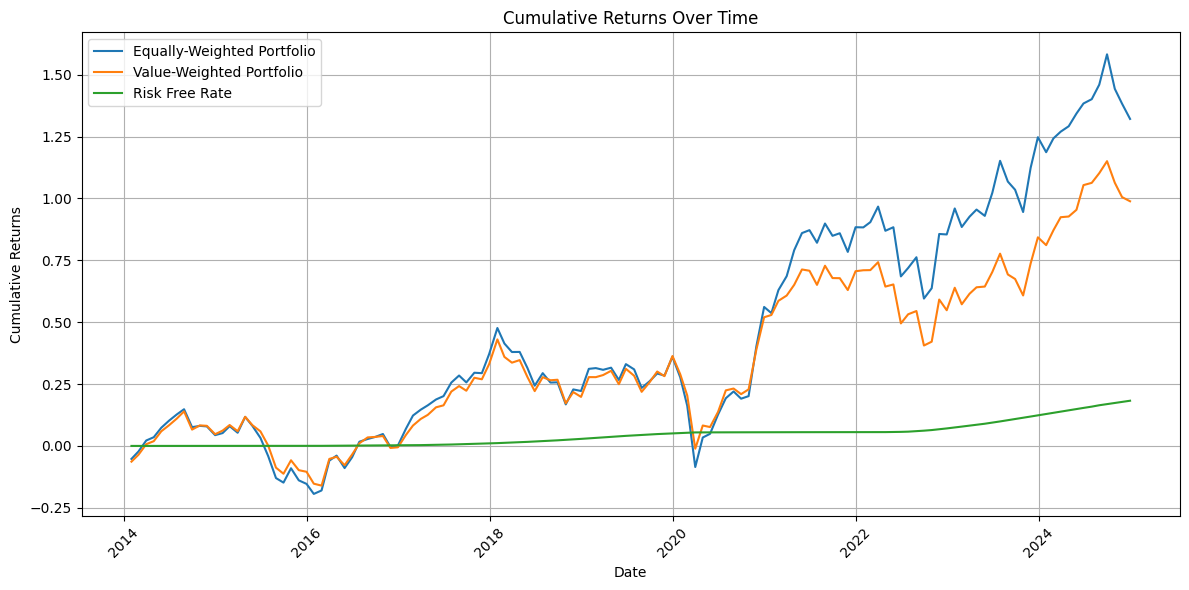

In [556]:
plt.figure(figsize=(12, 6))
plt.plot(returns_df.date, returns_df.ew_cumulative_returns, label='Equally-Weighted Portfolio')
plt.plot(returns_df.date, returns_df.vw_cumulative_returns, label='Value-Weighted Portfolio')
plt.plot(returns_df.date, returns_df.rf_cumulative_returns, label='Risk Free Rate')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Cumulative Returns Over Time')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.legend()  # Add the legend
plt.show()

In [557]:
total_return = (1 + returns_df['ew_return']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
ew_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the equally weighted portfolio: {ew_annualized_return:.6f}")


Annualized return of the equally weighted portfolio: 0.079560


In [558]:
total_return = (1 + returns_df['vw_return']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
vw_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the value weighted portfolio: {vw_annualized_return:.6f}")

Annualized return of the value weighted portfolio: 0.064485


In [559]:
min_ew_return = returns_df['ew_return'].min()
print(f"Minimum retrun in the equally weighted portfolio: {min_ew_return}")

Minimum retrun in the equally weighted portfolio: -0.21290682220093285


In [560]:
min_vw_return = returns_df['vw_return'].min()
print(f"Minimum retrun in the value weighted portfolio: {min_vw_return}")

Minimum retrun in the value weighted portfolio: -0.17857427485480376


In [561]:
max_ew_return = returns_df['ew_return'].max()
print(f"Maximum retrun in the equally weighted portfolio: {max_ew_return}")

Maximum retrun in the equally weighted portfolio: 0.16779218844833546


In [562]:
max_vw_return = returns_df['vw_return'].max()
print(f"Maximum retrun in the value weighted portfolio: {max_vw_return}")

Maximum retrun in the value weighted portfolio: 0.1309822901656277


In [563]:
# Compute sample variance (N-1 for unbiased estimator)
ew_variance = returns_df['ew_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
ew_volatility = np.sqrt(ew_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
ew_volatility_annualized = ew_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the equally-weighted portfolio: {ew_volatility_annualized}")

Annualized volatility of the equally-weighted portfolio: 0.17962802651486687


In [564]:
# Compute sample variance (N-1 for unbiased estimator)
vw_variance = returns_df['vw_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
vw_volatility = np.sqrt(vw_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
vw_volatility_annualized = vw_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the value-weighted portfolio: {vw_volatility_annualized}")

Annualized volatility of the value-weighted portfolio: 0.15902226345247503


In [565]:
df = returns_df

df['ew_excess_return'] = df['ew_return'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['ew_excess_return'].mean()
std_excess_return = df['ew_excess_return'].std()

ew_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {ew_sharpe_ratio:.4f}")

Sharpe Ratio: 0.1244


In [566]:
ew_annualized_sharpe_ratio = ew_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {ew_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.4310


In [567]:
df = returns_df

df['vw_excess_return'] = df['vw_return'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['vw_excess_return'].mean()
std_excess_return = df['vw_excess_return'].std()

vw_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {vw_sharpe_ratio:.4f}")

Sharpe Ratio: 0.1087


In [568]:
vw_annualized_sharpe_ratio = vw_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {vw_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.3765


In [569]:
data = {
    'Portfolio': ['Equally Weighted', 'Value Weighted'],
    'Annualized Return': [ew_annualized_return, vw_annualized_return],  # Replace with actual values
    'Minimum Return': [min_ew_return, min_vw_return],
    'Maximum Return': [max_ew_return, max_vw_return],
    'Annualized Volatility': [ew_volatility_annualized, vw_volatility_annualized],
    'Annualized Sharpe Ratio': [ew_annualized_sharpe_ratio, vw_annualized_sharpe_ratio]
}

df = pd.DataFrame(data)
summary_df = df

summary_df

,Portfolio,Annualized Return,Minimum Return,Maximum Return,Annualized Volatility,Annualized Sharpe Ratio
0,Equally Weighted,0.079560,-0.212907,0.167792,0.179628,0.430964
1,Value Weighted,0.064485,-0.178574,0.130982,0.159022,0.376515


# **Question 1: Data**

In [570]:
#Analysis 1: mean, median, min, max, std
# Calculate mean, median, min, max, and std for EM_merged_DS_EScore_Y
escore_stats = EScore_Y_2009_2024.iloc[:, 5:].agg(['mean', 'median', 'min', 'max', 'std'])
escore = EScore_Y_2009_2024.iloc[:, 5:]

# Print the statistics
escore_stats
escore

,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
0,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
1,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
2,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
3,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
4,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...
505,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
506,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
507,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
508,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


In [571]:
# Assuming optimized_weights_df is your DataFrame with ISINs as index and years as columns

def top_10_isins_by_column(df):
  """Returns a table with top 10 ISINs for each column (year) in the DataFrame."""
  top_isins_dict = {}
  for column in df.columns:
    # Sort the column in descending order and get the top 10 ISINs
    top_isins = df[column].sort_values(ascending=False).head(10).index.tolist()
    top_isins_dict[column] = top_isins
  return pd.DataFrame(top_isins_dict)

# Example usage:
top_isins_table = top_10_isins_by_column(optimized_weights_df)
top_isins_table


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,MXP225611567,TRAARCLK91H5,TW0002409000,MXP495211262,MX01WA000038,KR7000720003,TRAISCTR91N2,TRAARCLK91H5,TRAARCLK91H5,BRBBDCACNPR8
1,ZAE000026639,ZAE000026639,TRAARCLK91H5,TRAARCLK91H5,BRBBDCACNPR8,INE018A01030,ZAE000004875,TRAISCTR91N2,TRAISCTR91N2,TRAISCTR91N2
2,KR7066570003,MXP495211262,KR7000720003,KR7000720003,MXP495211262,ZAE000004875,TRAGARAN91N1,TRAAKBNK91N6,TRAAKBNK91N6,TRAARCLK91H5
3,MX01WA000038,TW0002308004,BRITUBACNPR1,BREGIEACNOR9,ZAE000004875,TRAARCLK91H5,TW0001216000,ZAE000004875,KR7047040001,KR7047040001
4,TW0002409000,TW0002409000,MX01WA000038,BRBBDCACNPR8,PLBSK0000017,TW0001216000,TRAARCLK91H5,TRAGARAN91N1,TH0128B10Z09,TRAAKBNK91N6
5,INE081A01020,TH0646010Z00,BRBBDCACNPR8,BRITUBACNPR1,BRITUBACNPR1,TRAGARAN91N1,INE018A01030,TW0001216000,BRITUBACNPR1,TH0128B10Z09
6,TRAARCLK91H5,MXP225611567,BRBBASACNOR3,MX01WA000038,TW0001216000,BRBBDCACNPR8,KR7000720003,BRBBDCACNPR8,TW0001216000,INE154A01025
7,TRAKCHOL91Q8,ZAE000004875,TW0002308004,BRBBASACNOR3,BRBBASACNOR3,TW0002371002,TRASAHOL91Q5,TW0002371002,BRCMIGACNPR3,TW0002371002
8,TH0646010Z00,KR7000720003,ZAE000026639,TW0002409000,TRAGARAN91N1,BRITUBACNPR1,TW0002371002,KR7047040001,TRAGARAN91N1,PLBSK0000017
9,INE018A01030,BRBBASACNOR3,TH0646010Z00,TW0002002003,KR7000720003,BRBBASACNOR3,TH0128B10Z09,KR7021240007,INE154A01025,TW0002891009


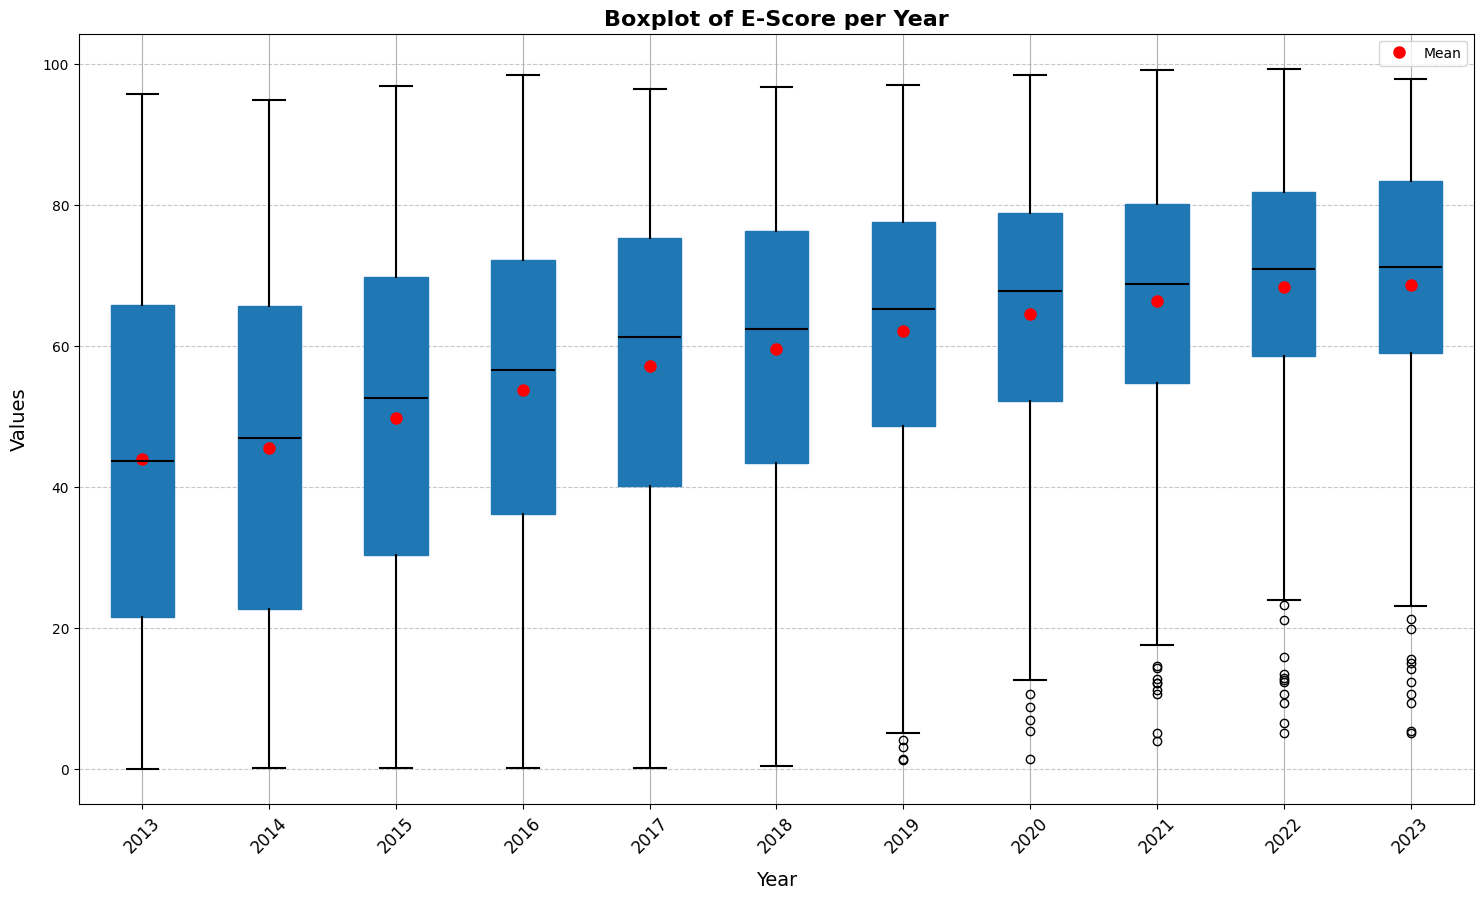

In [572]:
# Set figure size for better visibility
plt.figure(figsize=(18, 10))

# Create the boxplot (same as before, but improved)
boxplot = escore.boxplot(patch_artist=True)  # Allows us to modify box colors

# Customize box colors
for box in boxplot.artists:
    box.set_facecolor("lightblue")  # Light blue fill for better contrast
    box.set_edgecolor("black")  # Black border for clear visibility
    box.set_linewidth(1.5)  # Thicker border lines

# Customize whiskers, caps, and median
for line in boxplot.lines:
    line.set_color("black")  # Darker whiskers and caps
    line.set_linewidth(1.5)  # Thicker lines
    if "Median" in line.get_label():
        line.set_color("red")  # Highlight median
        line.set_linewidth(2)

# Calculate and add mean as red dots
for i, col in enumerate(escore.columns):
    mean_val = escore[col].mean()
    plt.plot(i + 1, mean_val, 'ro', markersize=8)  # 'ro' for red dot


# Customize labels and title
plt.xlabel("Year", fontsize=14, labelpad=10)
plt.ylabel("Values", fontsize=14, labelpad=10)
plt.title("Boxplot of E-Score per Year", fontsize=16, fontweight="bold")

# Improve x-axis readability
plt.xticks(rotation=45, fontsize=12)

# Add y-axis grid for clarity
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Customize x-axis labels
x_labels = [label.get_text()[:4] for label in plt.gca().get_xticklabels()]  # Extract year
plt.gca().set_xticklabels(x_labels)  # Set new labels

# Add a dummy plot for the legend
plt.plot([], [], 'ro', markersize=8, label='Mean')  # Create a dummy plot with a red dot

# Add the legend
plt.legend(loc='best')  # Place the legend in the best location


# Show the plot
plt.show()

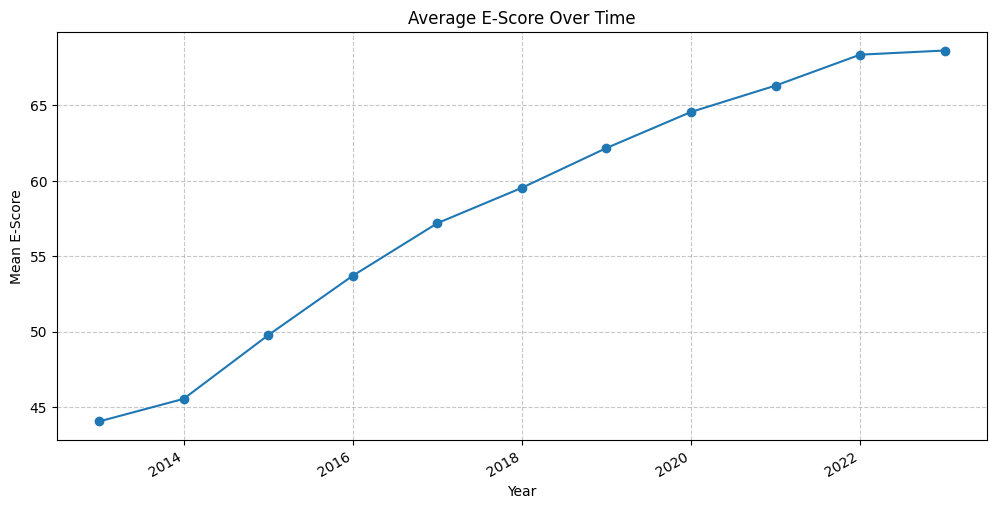

In [573]:
escore.mean().plot(kind='line', marker='o', figsize=(12,6), title="Average E-Score Over Time")
plt.xlabel("Year")
plt.ylabel("Mean E-Score")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

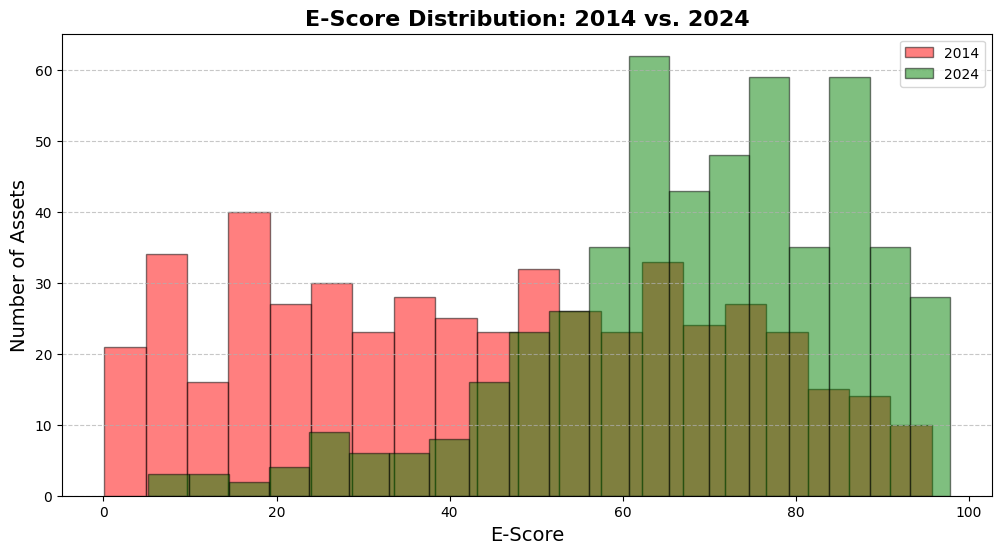

In [574]:
plt.figure(figsize=(12, 6))
plt.hist(escore.iloc[:, 0], bins=20, alpha=0.5, label="2014", color="red", edgecolor="black")
plt.hist(escore.iloc[:, -1], bins=20, alpha=0.5, label="2024", color="green", edgecolor="black")

plt.xlabel("E-Score", fontsize=14)
plt.ylabel("Number of Assets", fontsize=14)
plt.title("E-Score Distribution: 2014 vs. 2024", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

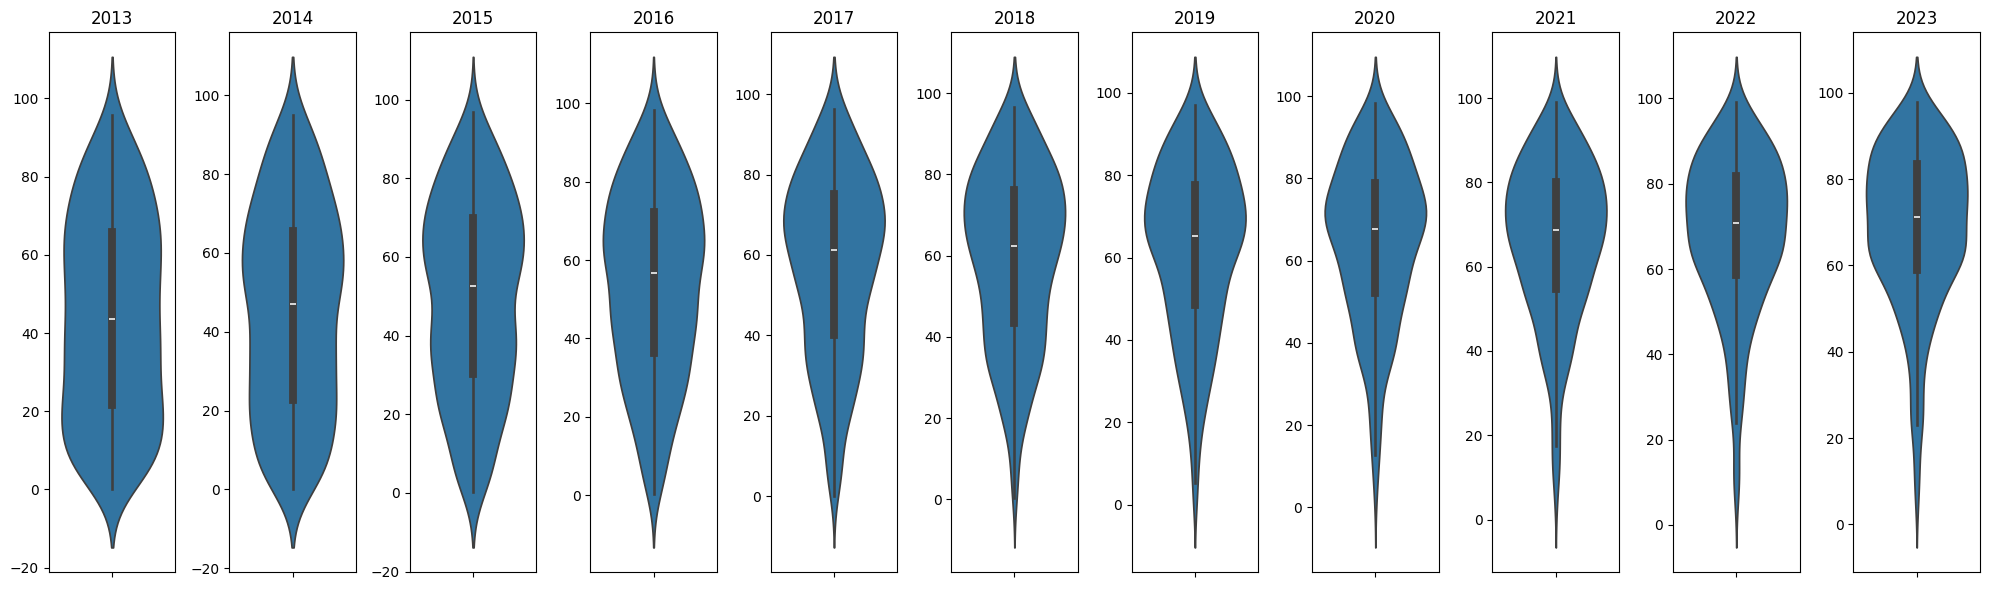

In [575]:
 # Create violin plots for each column
plt.figure(figsize=(20, 6))  # Adjust the figure size as needed
for i, column in enumerate(escore.columns):
    plt.subplot(1, len(escore.columns), i + 1)  # Create a subplot for each column
    sns.violinplot(y=escore[column])
    year = pd.to_datetime(column).year
    plt.ylabel("")
    plt.title(year)
    plt.tight_layout()  # Ensure subplots don't overlap

plt.show()
